---
# <div align="center"> MCF ITB </div>
## <div align="center"> Data Science Competition</div>
#### <div align="center"> Kelompok AFTers </div>
---

Anggota Kelompok:
1. Alvin Wijaya
2. Tokesi Lukynawa
3. Felicio Balamitta Putra

Import Basic Library & CSV

In [1]:
%pip install -q catboost pipeline shap


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Phase 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import shap
from scipy import stats
from scipy.stats import zscore
import ipywidgets as widgets
from IPython.display import display, clear_output

# Phase 2
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_validate, TimeSeriesSplit, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

# Phase 3
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.base import clone
import statsmodels.api as sm

# Evaluation Metrics
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error, mean_squared_error

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')
# df_klaim = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MCF_ITB_AFTers/Data_Klaim.csv", low_memory = False)
# df_polis = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MCF_ITB_AFTers/Data_Polis.csv", low_memory = False)

In [4]:
# VS Code Method:

df_klaim = pd.read_csv("Data_Klaim.csv", low_memory = False)
df_polis = pd.read_csv("Data_Polis.csv", low_memory = False)

## **A. Preprocessing & Eksplorasi Data Analysis**

### **A.1. Identifikasi data dengan faktor tidak lengkap dan outlier yang berpotensi mempengaruhi performa model**

        
Merge Kedua Dataset Polis dan Klaim berdasarkan Nomor Polis

In [5]:
df = df_klaim.merge(df_polis, on = "Nomor Polis", how = "left")

In [6]:
df.shape

(4627, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 non-null   o

In [8]:
df.head(5)

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore,M-001,F,19670220,20150109,JAKARTA
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia,M-002,M,19560925,20120619,YOGYAKARTA
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore,M-002,F,19591021,20150316,SURABAYA
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore,M-002,F,19591021,20150316,SURABAYA
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore,M-002,F,19680906,20140624,JAKARTA


In [9]:
num_cols = df.select_dtypes(exclude=['object', 'category']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

In [10]:
exclude_cols = ["Tanggal Lahir", "Tanggal Efektif Polis"]
nodate_columns = [col for col in num_cols if col not in exclude_cols]

df[nodate_columns].describe()

,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi
count,4.627000e+03,4.627000e+03
mean,5.502892e+07,5.994940e+07
std,1.319527e+08,1.597838e+08
min,0.000000e+00,0.000000e+00
25%,2.274009e+06,2.720210e+06
50%,1.446790e+07,1.587100e+07
75%,5.107209e+07,5.423067e+07
max,2.197500e+09,3.892810e+09


In [11]:
df.isnull().sum().sort_values(ascending=False)


Inpatient/Outpatient             37
Tanggal Pembayaran Klaim         37
Lokasi RS                         7
ICD Diagnosis                     6
ICD Description                   6
Claim ID                          0
Nominal Biaya RS Yang Terjadi     0
Tanggal Efektif Polis             0
Tanggal Lahir                     0
Gender                            0
Plan Code                         0
Tanggal Pasien Keluar RS          0
Nominal Klaim Yang Disetujui      0
Nomor Polis                       0
Tanggal Pasien Masuk RS           0
Status Klaim                      0
Reimburse/Cashless                0
Domisili                          0
dtype: int64

**Masalah:**
1. Melihat kolom tanggal, diperlukan adanya konversi informasi yang lebih bermakna. Apabila dibiarkan maka model dapat salah mencerna informasi dimana 20231231 & 20240101 diasumsikan sebagai 8870 hari, nyatanya hanya selisih 1 hari.

2. Distribusi Nilai Nominal Klaim Yang Disetujui & Biaya RS Yang Terjadi cenderung sangat right heavy tailed (*Positive Skew*) & tidak seimbang. Kolom data ini mendorong adanya aksi khusus yang harus dilakukan dan juga menggunakan model yang tahan terhadap distribusi yang heavy skewed.

3. Format kolom tidak konsisten: Tanggal Lahir dan Tanggal Efektif polis memiliki format int64 bukan object.

4. Adanya nilai Null pada ~37 baris kolom dapat menghilangkan banyak informasi penting seperti: Bagaimana jika ada klaim ratusan jutaan / miliaran namun ada Tanggal Pembayaran Klaim yang hilang? Tidak bisa langsung di drop. Akan ditangani lebih lanjut.

=================================================================================

**Penanganan:** (Akan dilakukan di -> **A.3 Normalisasi Data & Feature Engineering**)
1. Membuat kolom Usia Nasabah, Masa Bakti/Tenure Polis, Lama Perawatan saat Feature Engineering.
2. Prioritaskan model tree ensemble yang tangguh menghadapi distribusi miring. Asumsi sekarang: RFR, XGB, dan CatBoost adalah pilihan terbaik untuk model dengan output stabil.
3. Cast Type Format kolom tanggal tidak konsisten dengan pd.to_datetime dengan format yang konsisten.

In [12]:
cat_summary = pd.DataFrame({
    'n_unique': df[cat_cols].nunique(),
    'n_missing': df[cat_cols].isna().sum()
}).sort_values(['n_missing'], ascending=False)

cat_summary

,n_unique,n_missing
Inpatient/Outpatient,4,37
Tanggal Pembayaran Klaim,357,37
Lokasi RS,10,7
ICD Diagnosis,753,6
ICD Description,946,6
Claim ID,4627,0
Nomor Polis,1210,0
Reimburse/Cashless,2,0
Status Klaim,1,0
Tanggal Pasien Masuk RS,564,0


In [13]:
col_to_check = ["Inpatient/Outpatient", "Tanggal Pembayaran Klaim", "Lokasi RS", "ICD Diagnosis", "ICD Description"]
for col in col_to_check:
    display(df[col].value_counts(dropna=False).to_frame().T)

Inpatient/Outpatient,IP,OP,ODC,ODS,NaN
count,2258,1940,281,111,37


Tanggal Pembayaran Klaim,2024-04-16,2024-11-21,2024-06-20,2024-07-01,2024-05-20,2024-08-02,2025-06-05,2024-09-24,NaN,2024-05-13,...,2024-07-17,2024-01-30,2025-10-10,2024-10-22,2025-02-19,2024-01-17,2025-10-29,2025-10-28,2025-11-11,2025-05-15
count,55,48,47,43,41,40,40,39,37,37,...,1,1,1,1,1,1,1,1,1,1


Lokasi RS,Indonesia,Singapore,Malaysia,Overseas,NaN,Others,Taiwan,Hong Kong,Japan,Tiongkok,Australia
count,3102,1019,456,28,7,6,5,1,1,1,1


ICD Diagnosis,N18.0,C50,H26,K29.7,C34,I25.1,N18.5,N23,A09,C19,...,N99,C67.5,Q64.3,N83.2,R30.0,M81,D14.0,M84.4,K85,R56.0
count,290,254,215,139,129,86,81,78,75,69,...,1,1,1,1,1,1,1,1,1,1


ICD Description,MALIGNANT NEOPLASM OF BREAST,END-STAGE RENAL DISEASE,OTHER CATARACT,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,"CHRONIC KIDNEY DISEASE, STAGE 5",GASTRITIS,End-stage renal disease,UNSPECIFIED RENAL COLIC,MALIGNANT NEOPLASM OF RECTOSIGMOID JUNCTION,ABDOMINAL AND PELVIC PAIN,...,Other and unspecified ovarian cysts,Dysuria,OSTEOPOROSIS WITHOUT PATHOLOGICAL FRACTURE,"Middle ear, nasal cavity and accessory sinuses","Pathological fracture, not elsewhere classified",Acute Pancreatitis,Other specified diseases of liver,Other disease of Anus and Rectum (polyp,Other dorsalgia,"Malignant neoplasm of bronchus or lung, unspecified"
count,245,211,158,125,81,81,79,76,69,64,...,1,1,1,1,1,1,1,1,1,1


Numerical check

In [14]:
num_summary = pd.DataFrame({
    'n_unique': df[num_cols].nunique(),
    'n_missing': df[num_cols].isna().sum()
}).sort_values('n_unique', ascending=False)

num_summary

,n_unique,n_missing
Nominal Biaya RS Yang Terjadi,4194,0
Nominal Klaim Yang Disetujui,3995,0
Tanggal Lahir,1166,0
Tanggal Efektif Polis,677,0


In [15]:
df.duplicated().any()


np.False_

Tidak ada baris duplikat / missing value di kolom numerikal

### **A.2. Visualisasi hubungan antara faktor yang tersedia**

- dengan klaim asuransi kesehatan dengan baik menggunakan histogram, scatter plot, box plot ataupun heatmap.

**Check Bentuk Distribusi Data:**

- Skewness > 1: Miring Kanan
- Skewness ~ 0: Cukup Balanced
- Skewness < -1: Miring Kiri

In [16]:
# Cek skewness untuk Nominal Klaim

exclude = {"Tanggal Lahir", "Tanggal Efektif Polis", "Tanggal Pasien Keluar RS", "Tanggal Pasien Masuk RS"}
col_to_check2 = list(set(num_cols) - exclude)

for col in col_to_check2:
    print(f"{col}: {df[col].skew()}")

Nominal Biaya RS Yang Terjadi: 9.617148115674789
Nominal Klaim Yang Disetujui: 6.639577239535922


#### **A.2.1 Heatmap: Korelasi antar kolom numerik**

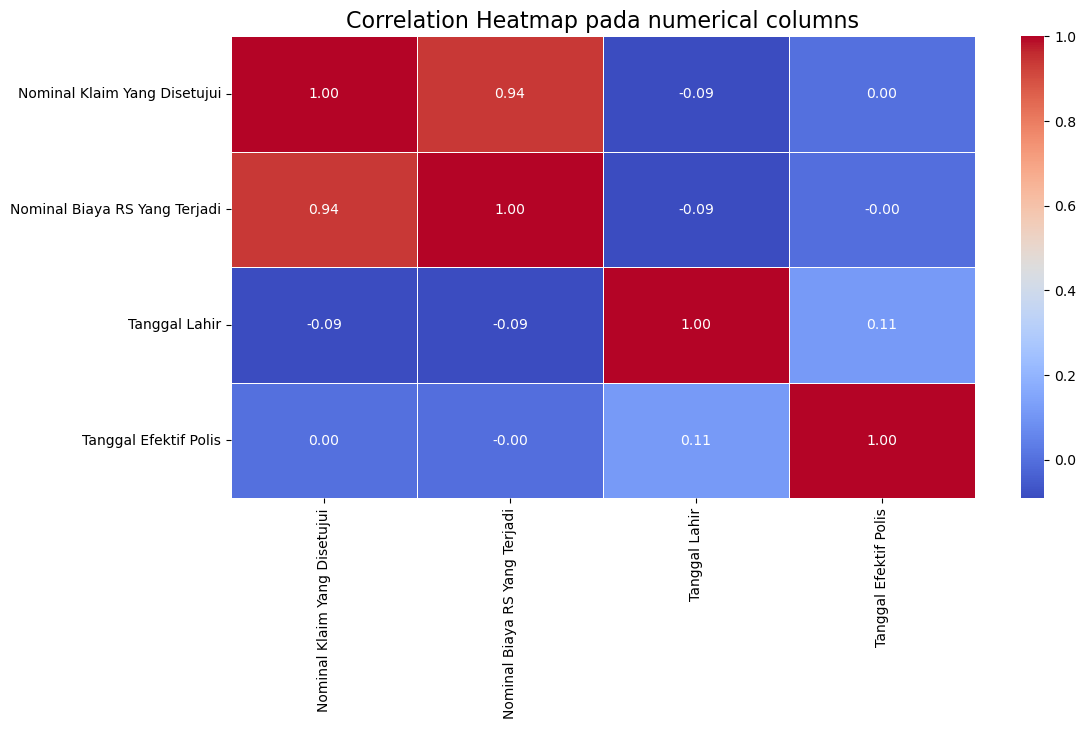

In [17]:
plt.figure(figsize=(12, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap pada numerical columns', fontsize=16)
plt.show()

In [18]:
num_cols

Index(['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi',
       'Tanggal Lahir', 'Tanggal Efektif Polis'],
      dtype='object')

#### **A.2.2 Violinplot: Distribusi Data Numerikal**

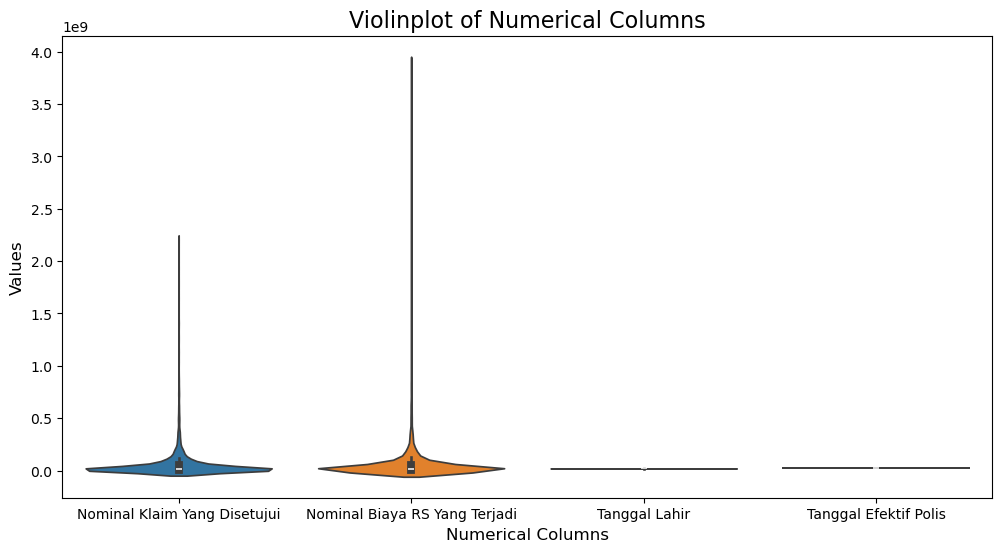

In [19]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[num_cols])
plt.title('Violinplot of Numerical Columns', fontsize=16)
plt.xlabel('Numerical Columns', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.show()

#### **A.2.3 Barplot: Besar rata-rata Biaya RS dengan Kondisi Diagnosis**

C:\Users\Alvin\AppData\Local\Temp\ipykernel_24524\1725542649.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10,


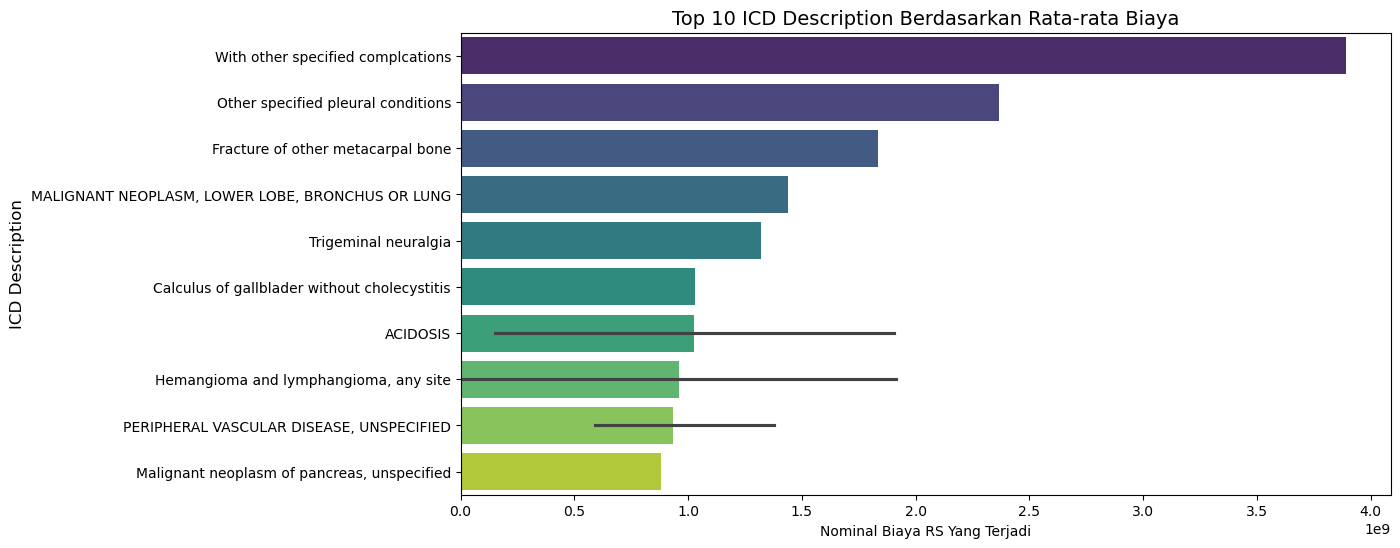

In [20]:
top_10_names = df.groupby('ICD Description')['Nominal Biaya RS Yang Terjadi'].mean().nlargest(10).index

df_top10 = df[df['ICD Description'].isin(top_10_names)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top10, 
            x='Nominal Biaya RS Yang Terjadi',
            y='ICD Description', 
            order=top_10_names, 
            palette='viridis')

plt.title('Top 10 ICD Description Berdasarkan Rata-rata Biaya', fontsize=14)
plt.ylabel('ICD Description', fontsize=12)
plt.show()

#### **A.2.4 Scatterplot & Histplot: Biaya RS & Klaim Disetujui per Jenis Layanan**

Text(0.5, 1.0, 'Distribusi Inpatient/Outpatient')

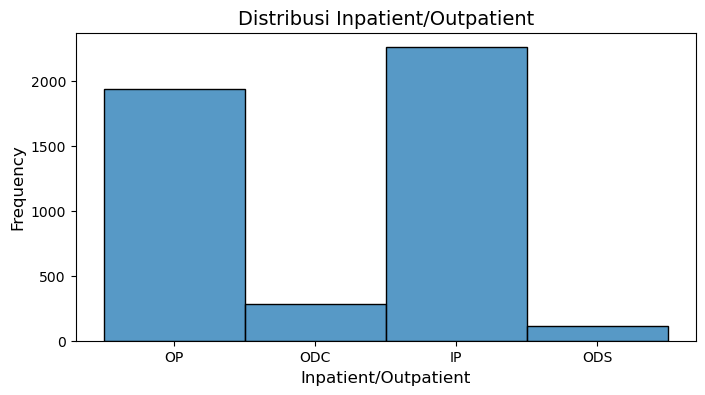

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Inpatient/Outpatient"])
plt.xlabel('Inpatient/Outpatient', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribusi Inpatient/Outpatient', fontsize=14)

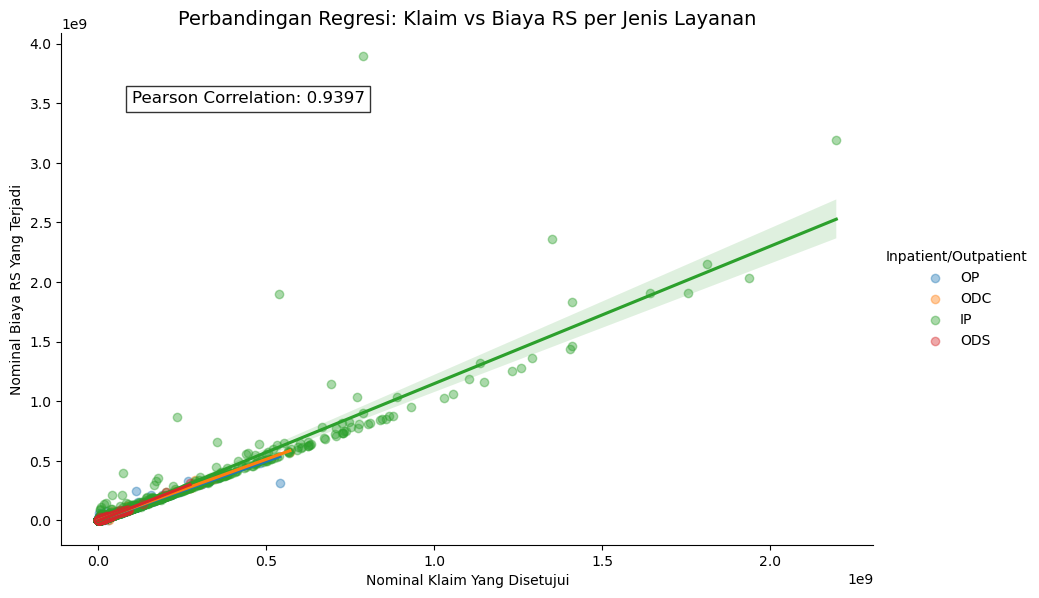

In [22]:
corr_value = df['Nominal Klaim Yang Disetujui'].corr(df['Nominal Biaya RS Yang Terjadi'])

sns.lmplot(data=df, 
           x='Nominal Klaim Yang Disetujui', 
           y='Nominal Biaya RS Yang Terjadi', 
           hue='Inpatient/Outpatient', # Membedakan warna berdasarkan IP/OP/dll
           height = 6, aspect=1.5,
           scatter_kws={'alpha':0.4})

plt.text(0.1e9, 3.5e9, f'Pearson Correlation: {corr_value:.4f}', 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
plt.title('Perbandingan Regresi: Klaim vs Biaya RS per Jenis Layanan', fontsize=14)
plt.xlabel('Nominal Klaim Yang Disetujui')
plt.ylabel('Nominal Biaya RS Yang Terjadi')
plt.show()

Berdasarkan grafik regresi, terdapat hubungan linear yang konsisten antara biaya RS dan klaim yang disetujui. Namun, ditemukan beberapa outliers signifikan di mana biaya RS melonjak hingga Rp4 Miliar namun klaim yang disetujui tetap di bawah Rp1 Miliar. Hal ini menunjukkan adanya mekanisme kendali biaya (cost containment) atau batasan plafon manfaat pada kasus-kasus kritis.

#### **A.2.5 Barplot + Boxplot: Top 10 Lokasi RS dengan Biaya Klaim Terbesar**

C:\Users\Alvin\AppData\Local\Temp\ipykernel_24524\2617879557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_loc.values, y=top_10_loc.index, palette='viridis')


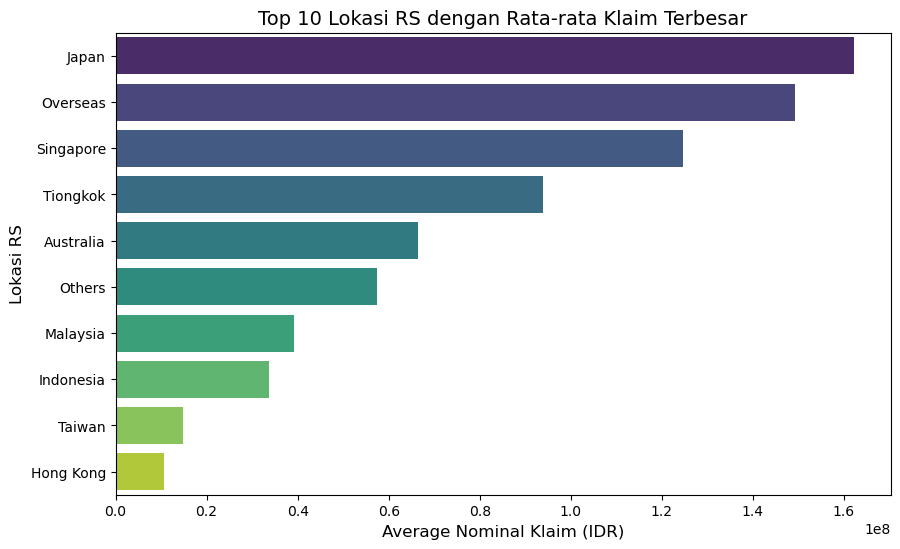

In [23]:
top_10_loc = df.groupby("Lokasi RS")["Nominal Klaim Yang Disetujui"].mean().nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_loc.values, y=top_10_loc.index, palette='viridis')
plt.xlabel('Average Nominal Klaim (IDR)', fontsize=12)
plt.ylabel('Lokasi RS', fontsize=12)
plt.title('Top 10 Lokasi RS dengan Rata-rata Klaim Terbesar', fontsize=14)
plt.show()

C:\Users\Alvin\AppData\Local\Temp\ipykernel_24524\2673129285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10_loc,


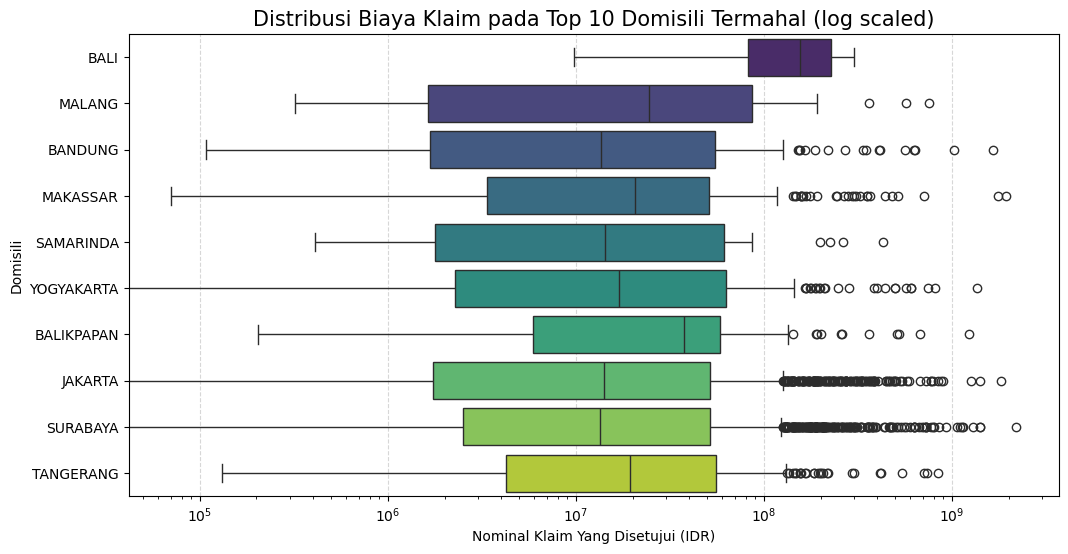

In [24]:
top_10_loc_names = df.groupby('Domisili')['Nominal Klaim Yang Disetujui']\
                     .mean().nlargest(10).index
df_top10_loc = df[df['Domisili'].isin(top_10_loc_names)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top10_loc, 
            x='Nominal Klaim Yang Disetujui', 
            y='Domisili', 
            order=top_10_loc_names, # Mengurutkan dari rata-rata tertinggi
            palette='viridis')

plt.title('Distribusi Biaya Klaim pada Top 10 Domisili Termahal (log scaled)', fontsize=15)
plt.xlabel('Nominal Klaim Yang Disetujui (IDR)')
plt.xscale('log')  # Menggunakan skala logaritmik untuk memperjelas distribusi
plt.ylabel('Domisili')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### **A.3. Normalisasi Data & Feature Engineering**

**[1]. Masalah**
1. Usia Nasabah -> Dihitung dari "Tanggal Pasien Masuk RS" - "Tanggal Lahir"

2. Tenure Polis_Hari -> "Tanggal Pasien Masuk RS" - "Tanggal Efektif Polis"

3. Lama Perawatan -> "Tanggal Pasien Keluar RS" - "Tanggal Pasien Masuk RS"

In [25]:
#Konversi Object Kolom Tanggal -> pd.to_datetime()
df['Tanggal Pasien Masuk RS'] = pd.to_datetime(df['Tanggal Pasien Masuk RS']) #Dengan pemisah
df['Tanggal Pasien Keluar RS'] = pd.to_datetime(df['Tanggal Pasien Keluar RS']) #Dengan pemisah
df['Tanggal Lahir'] = pd.to_datetime(df['Tanggal Lahir'].astype(str), format='%Y%m%d') #Tanpa pemisah
df['Tanggal Efektif Polis'] = pd.to_datetime(df['Tanggal Efektif Polis'].astype(str), format='%Y%m%d') #Tanpa pemisah

#Kolom Baru: Membuat kolom usia nasabah, Tenure Polis Hari, Lama Perawatan
df["Usia Saat Klaim"] = (df["Tanggal Pasien Masuk RS"] - df["Tanggal Lahir"]).dt.days // 365
df["Tenure Polis Hari"] = (df["Tanggal Pasien Masuk RS"] - df["Tanggal Efektif Polis"]).dt.days
df["Lama Perawatan"] = (df["Tanggal Pasien Keluar RS"] - df["Tanggal Pasien Masuk RS"]).dt.days


In [26]:
cols_to_fix = ["Inpatient/Outpatient", "Lokasi RS", "ICD Diagnosis", "ICD Description"]
for col in cols_to_fix:
    df[col] = df[col].fillna("UNKNOWN")

cat_cols = df.select_dtypes(include=['object', 'category']).columns #Perbarui cat_cols

In [27]:
cat_summary = pd.DataFrame({
    'n_unique': df[cat_cols].nunique(),
    'n_missing': df[cat_cols].isna().sum()
}).sort_values(['n_missing'], ascending=False)

cat_summary

,n_unique,n_missing
Tanggal Pembayaran Klaim,357,37
Claim ID,4627,0
Nomor Polis,1210,0
Reimburse/Cashless,2,0
Inpatient/Outpatient,5,0
ICD Diagnosis,754,0
ICD Description,947,0
Status Klaim,1,0
Lokasi RS,11,0
Plan Code,3,0


**Tanggal Pembayaran klaim** adalah kolom yang tidak diketahui jika kita sedang memprediksi kustomer di masa depan. Oleh karena itu kolom ini tidak seharusnya digunakan sebagai fitur karena bersifat data leakage.

**Solusi:** Menghapus Kolom "Tanggal Pembayaran Klaim"

In [28]:
display(df[["Lokasi RS"]].value_counts())

Lokasi RS
Indonesia    3102
Singapore    1019
Malaysia      456
Overseas       28
UNKNOWN         7
Others          6
Taiwan          5
Australia       1
Hong Kong       1
Japan           1
Tiongkok        1
Name: count, dtype: int64

In [29]:
display(df["Domisili"].value_counts())

Domisili
SURABAYA      1831
JAKARTA       1296
TANGERANG      306
PALEMBANG      233
YOGYAKARTA     224
MAKASSAR       203
BALIKPAPAN     182
BANDUNG        115
JEMBER          44
MANADO          34
MALANG          30
MEDAN           30
SEMARANG        24
SOLO            21
PALU            19
SAMARINDA       19
BLITAR          10
KUDUS            3
BALI             2
SORONG           1
Name: count, dtype: int64

**Feature Engineering Seasonality**

In [30]:
df["Bulan Masuk"] = df['Tanggal Pasien Masuk RS'].dt.month
df["Is Weekend"] = df["Tanggal Pasien Masuk RS"].dt.dayofweek // 5
df["Kuartal_Masuk"] = df["Tanggal Pasien Masuk RS"].dt.quarter

jabodetabek = ["JAKARTA", "BOGOR", "DEPOK", "TANGERANG", "BEKASI"]
df["Is Jabodetabek"] = df["Domisili"].str.upper().apply(lambda x:1 if x in jabodetabek else 0)

df['Usia_x_Inpatient'] = df['Usia Saat Klaim'] * (df['Inpatient/Outpatient'] == 'IP').astype(int)


#### **A.3.1 Membuat df_ts Time-Series-based aggregation sebagai rata-rata Severity, Frekuensi, Total Klaim per bulan**

In [31]:
def build_freq_dataset(df):

    df = df.sort_values("timestamp").copy()

    df["lag1"] = df["claim_frequency"].shift(1)
    df["lag2"] = df["claim_frequency"].shift(2)
    df["lag3"] = df["claim_frequency"].shift(3)

    df["month"] = df["timestamp"].dt.month

    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

    df["trend"] = np.arange(len(df))

    return df.dropna()

In [32]:
df['Tanggal Pembayaran Klaim'] = pd.to_datetime(df['Tanggal Pembayaran Klaim'])
df['month_year'] = df['Tanggal Pembayaran Klaim'].dt.to_period('M')

df_monthly = df.groupby('month_year').agg(
    claim_frequency=('Claim ID', 'count'),
    claim_severity=('Nominal Klaim Yang Disetujui', 'mean'),
    total_claim=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

df_monthly['timestamp'] = df_monthly['month_year'].dt.to_timestamp()

def create_ts_features(df):

    df = df.sort_values('timestamp')

    df['month_num'] = df['timestamp'].dt.month
    df['year_num'] = df['timestamp'].dt.year

    #Fitur lag -> Momentum bulan lalu, tiap quarter (3, 6, 12)
    for lag in [1,2,3]:
      df[f'lag_{lag}'] = df['claim_severity'].shift(lag)
      #kalau lag brarti ambil data doang
      #Rolling artinya ambil statistik data dari lag kyknya

    #Fitur trend
    df['time_index'] = range(len(df))
    df["trend"] = np.arange(len(df))

    # Fitur rolling -> Statistik trend, volatilitas, dan perubahan
    # df['rolling_mean_3'] = df['claim_severity'].shift(1).rolling(3).mean()
    # df['rolling_median_3'] = df['claim_severity'].shift(1).rolling(3).median()
    df['rolling_mean_2'] = df['claim_severity'].shift(1).rolling(2).mean()
    df['rolling_median_2'] = df['claim_severity'].shift(1).rolling(2).median()
    df['rolling_std_2'] = df['claim_severity'].shift(1).rolling(2).std()

    df['rolling_mean_3'] = df['claim_severity'].shift(1).rolling(3).mean()
    df['rolling_median_3'] = df['claim_severity'].shift(1).rolling(3).median()
    df['rolling_std_3'] = df['claim_severity'].shift(1).rolling(3).std()

    df['rolling_trend_2'] = (
        df['rolling_mean_2'] - df['rolling_mean_2'].shift(1)
    )

    #Momentum Ratio
    df['mom_1'] = df['lag_1'].pct_change()

    #Per 3 bulan
    df['sev_lag3'] = df['claim_severity'].shift(3)

    #Claim Frequency
    for lag in [1,2,3]:
      df[f'freq_lag{lag}'] = df['claim_frequency'].shift(lag)

    df['freq_roll3'] = df['claim_frequency'].shift(1).rolling(3).mean()

    #Seasonality Encoding, supaya december tidak terasa jauh dari januari
    df['month_sin'] = np.sin(2 * np.pi * df['month_num']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_num']/12)

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=['lag_3','freq_lag3'])
    return df

df_ts = create_ts_features(df_monthly)

In [33]:
display(df_ts.sort_values('timestamp')[['timestamp', 'claim_severity', 'claim_frequency', 'total_claim']].T)

,3,4,5,6,7,8,9,10,11,12,...,14,15,16,17,18,19,20,21,22,23
timestamp,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,2024-12-01 00:00:00,2025-01-01 00:00:00,...,2025-03-01 00:00:00,2025-04-01 00:00:00,2025-05-01 00:00:00,2025-06-01 00:00:00,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00
claim_severity,41996395.855249,47375404.46505,51028057.296516,56574297.032439,66525927.198491,59369998.6418,46041246.392355,47682075.053671,47793267.352441,57926711.532628,...,63850656.138718,40972518.551957,47900835.259801,79302254.462402,68469168.698787,63138610.64302,52846332.783959,84484525.581724,45210738.18,68300135.815
claim_frequency,221,233,221,205,285,250,242,365,295,293,...,234,184,201,204,272,245,197,58,3,2
total_claim,9281203484.01,11038469240.356627,11277200662.530001,11597730891.650013,18959889251.57,14842499660.450001,11141981626.950001,17403957394.59,14099013868.969999,16972526479.059999,...,14941053536.459999,7538943413.559999,9628067887.219999,16177659910.33,18623613886.07,15468959607.539999,10410727558.440001,4900102483.74,135632214.54,136600271.63


- Data di index 0, 1, 2 hilang akibat creation lag yang pada awal index akan bernilai NaN dan dipotong.

- Data dari 2025 bulan ke 10, 11, 12 akan dianggap incomplete akibat rendahnya daftar claim_frequency

**Solusi**: Potong 3 data terakhir

In [34]:
df_ts = df_ts.iloc[:-3]
display(df_ts.sort_values('timestamp')[['timestamp', 'claim_severity', 'claim_frequency', 'total_claim']])

,timestamp,claim_severity,claim_frequency,total_claim
3,2024-04-01,4.199640e+07,221,9.281203e+09
4,2024-05-01,4.737540e+07,233,1.103847e+10
5,2024-06-01,5.102806e+07,221,1.127720e+10
6,2024-07-01,5.657430e+07,205,1.159773e+10
7,2024-08-01,6.652593e+07,285,1.895989e+10
8,2024-09-01,5.937000e+07,250,1.484250e+10
9,2024-10-01,4.604125e+07,242,1.114198e+10
10,2024-11-01,4.768208e+07,365,1.740396e+10
11,2024-12-01,4.779327e+07,295,1.409901e+10
12,2025-01-01,5.792671e+07,293,1.697253e+10


In [35]:
print("Before feature engineering:", len(df_monthly))

df_temp = create_ts_features(df_monthly)

print("Setelah Feature Engineering df_ts:", len(df_temp))

df_temp = df_temp.iloc[2:]
df_temp = df_temp.iloc[:-2]

print("Setelah removal 2 bulan:", len(df_temp))



Before feature engineering: 24
Setelah Feature Engineering df_ts: 21
Setelah removal 2 bulan: 17


#### **A.3.2 Daftar Features**

['claim_frequency', 'month_num', 'year_num', 'lag_1', 'lag_2', 'lag_3', 'time_index', 'trend', 'rolling_mean_2', 'rolling_median_2', 'rolling_std_2', 'rolling_mean_3', 'rolling_median_3', 'rolling_std_3', 'rolling_trend_2', 'mom_1', 'sev_lag3', 'freq_lag1', 'freq_lag2', 'freq_lag3', 'freq_roll3', 'month_sin', 'month_cos']
---------------
Correlation:


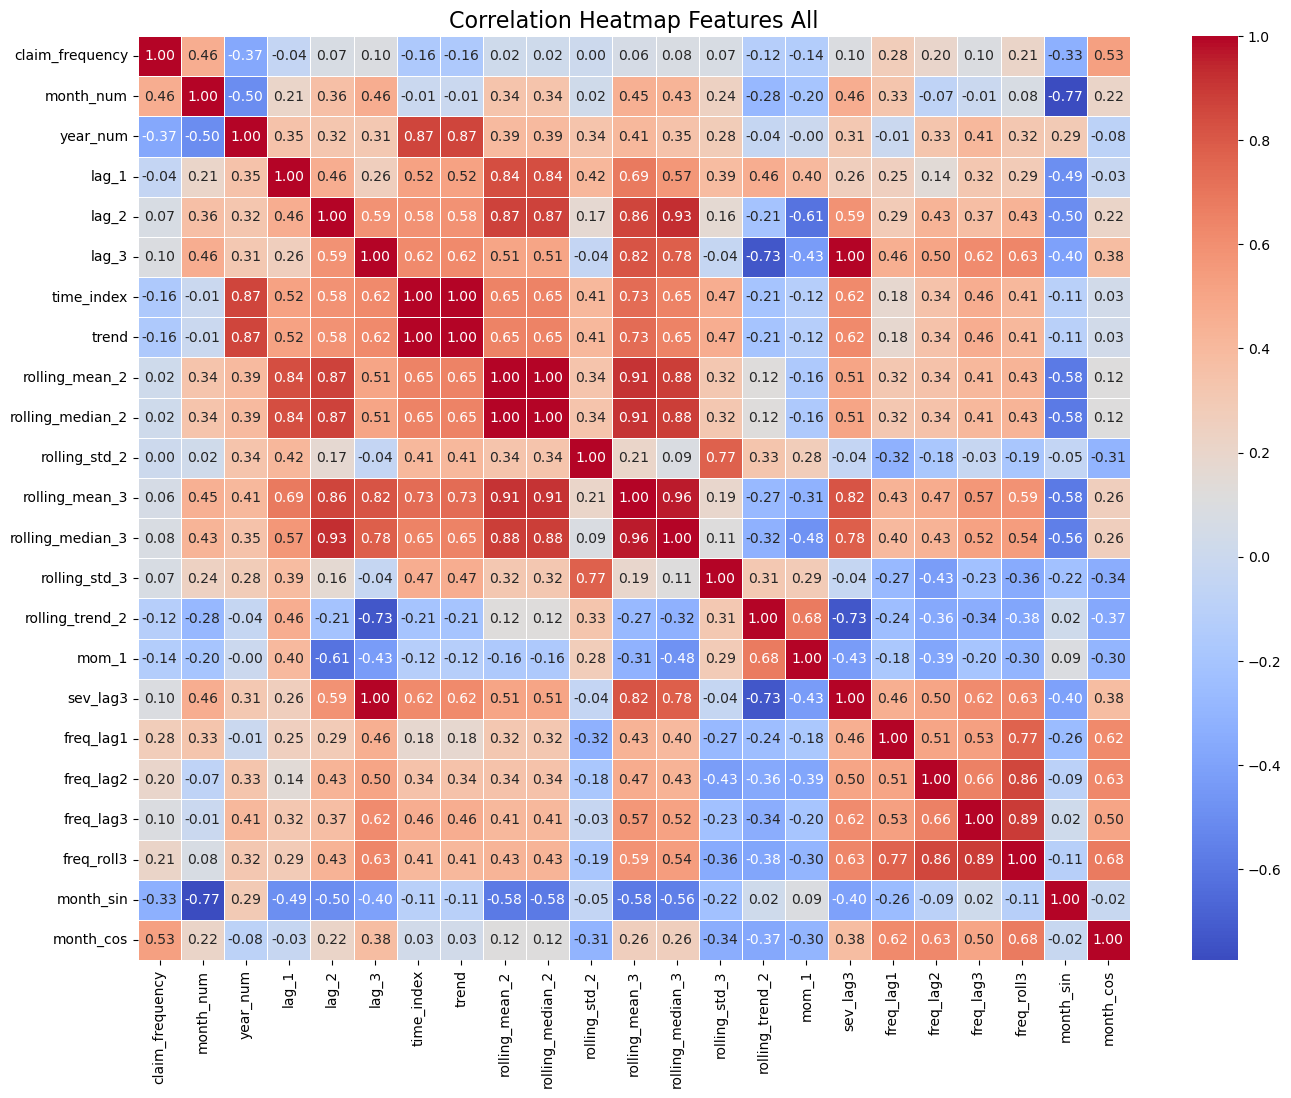

In [36]:
features_all = df_ts.columns.drop([ 'timestamp', 'month_year', 'claim_severity', 'total_claim' ]).tolist()
print(features_all)
features_sev = [
    'lag_1',        
    'lag_3',        
    'rolling_mean_2',
    'rolling_mean_3',
    'month_sin',
    'month_cos'
]

features_freq = [
    'freq_lag1',
    'freq_lag3',
    'month_num',
    'trend',
    'month_sin',
    'month_cos'
]

features_total = [
    'lag_1',        
    'freq_lag1',    
    'rolling_mean_2',
    'rolling_mean_3',
    'trend',
    'month_sin',
    'month_cos'
]

print("---------------\nCorrelation:")
plt.figure(figsize=(16, 12))
sns.heatmap(df_ts[features_all].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap Features All', fontsize=16)
plt.show()


In [37]:
print(df_ts[features_all].isna().sum())

claim_frequency     0
month_num           0
year_num            0
lag_1               0
lag_2               0
lag_3               0
time_index          0
trend               0
rolling_mean_2      0
rolling_median_2    0
rolling_std_2       0
rolling_mean_3      0
rolling_median_3    0
rolling_std_3       0
rolling_trend_2     0
mom_1               0
sev_lag3            0
freq_lag1           0
freq_lag2           0
freq_lag3           0
freq_roll3          0
month_sin           0
month_cos           0
dtype: int64


In [38]:
df_ts[features_all].describe()

,claim_frequency,month_num,year_num,lag_1,lag_2,lag_3,time_index,trend,rolling_mean_2,rolling_median_2,...,rolling_std_3,rolling_trend_2,mom_1,sev_lag3,freq_lag1,freq_lag2,freq_lag3,freq_roll3,month_sin,month_cos
count,18.000000,18.00000,18.000000,1.800000e+01,1.800000e+01,1.800000e+01,18.000000,18.000000,1.800000e+01,1.800000e+01,...,1.800000e+01,1.800000e+01,18.000000,1.800000e+01,18.000000,18.000000,18.000000,18.000000,1.800000e+01,18.000000
mean,240.555556,6.50000,2024.500000,5.430352e+07,5.241670e+07,4.950394e+07,11.500000,11.500000,5.336011e+07,5.336011e+07,...,8.215918e+06,2.399791e+06,0.066619,4.950394e+07,235.000000,226.500000,211.833333,224.444444,-5.555556e-02,-0.207336
std,47.100921,3.07265,0.514496,1.085081e+07,1.210456e+07,1.414993e+07,5.338539,5.338539,9.823989e+06,9.823989e+06,...,4.711759e+06,7.692052e+06,0.228628,1.414993e+07,57.327747,66.385018,82.860088,58.338767,7.253577e-01,0.695625
min,183.000000,1.00000,2024.000000,3.927778e+07,2.917577e+07,1.603952e+07,3.000000,3.000000,3.422677e+07,3.422677e+07,...,9.810080e+05,-1.024234e+07,-0.358307,1.603952e+07,97.000000,92.000000,8.000000,65.666667,-1.000000e+00,-1.000000
25%,204.250000,4.25000,2024.000000,4.745207e+07,4.637479e+07,4.300761e+07,7.250000,7.250000,4.708066e+07,4.708066e+07,...,5.092706e+06,-4.005616e+06,-0.093115,4.300761e+07,204.250000,201.750000,188.250000,201.833333,-7.745191e-01,-0.866025
50%,233.500000,6.50000,2024.500000,5.163311e+07,4.946445e+07,4.784705e+07,11.500000,11.500000,5.278281e+07,5.278281e+07,...,7.011755e+06,3.505393e+06,0.073158,4.784705e+07,233.500000,227.000000,221.000000,231.166667,-6.123234e-17,-0.500000
75%,266.500000,8.75000,2025.000000,6.219646e+07,5.900918e+07,5.758861e+07,15.750000,15.750000,6.067369e+07,6.067369e+07,...,1.117868e+07,6.088313e+06,0.174202,5.758861e+07,266.500000,266.500000,248.000000,254.416667,5.000000e-01,0.375000
max,365.000000,12.00000,2025.000000,7.930225e+07,7.930225e+07,7.930225e+07,20.000000,20.000000,7.388571e+07,7.388571e+07,...,2.042555e+07,1.916487e+07,0.655551,7.930225e+07,365.000000,365.000000,365.000000,317.666667,1.000000e+00,1.000000


--- Tren Severity Bulanan (Target Sebenarnya) ---


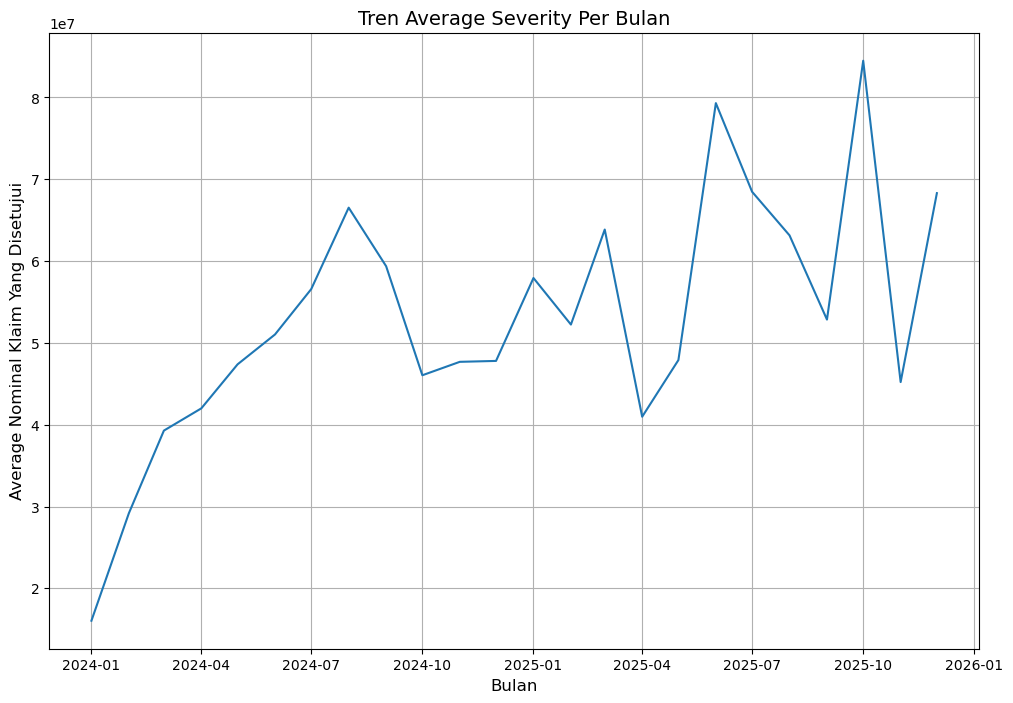

In [39]:
monthly_severity = df.groupby(df['Tanggal Pembayaran Klaim'].dt.to_period('M'))['Nominal Klaim Yang Disetujui'].mean()
print("--- Tren Severity Bulanan (Target Sebenarnya) ---")

plt.figure(figsize=(12, 8))
sns.lineplot(x=monthly_severity.index.to_timestamp(), y=monthly_severity.values)
plt.title('Tren Average Severity Per Bulan', fontsize=14)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Average Nominal Klaim Yang Disetujui', fontsize=12)
plt.grid()

In [40]:
num_cols = df.select_dtypes(exclude=['object', 'category']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

#Update df terakhir setelah feature engineering

In [41]:
col_to_drop = ["Claim ID", "Nomor Polis", "Tanggal Pasien Masuk RS", "Tanggal Pasien Keluar RS", "Tanggal Lahir", "Tanggal Efektif Polis", "ICD Description"]
col_target = ["Status Klaim", "Tanggal Pembayaran Klaim", "Nominal Biaya RS Yang Terjadi"]
final_col_to_drop = col_to_drop + col_target
df_final = df.drop(columns = final_col_to_drop, errors="ignore")

In [42]:
num_cols = df_final.select_dtypes(exclude=['object', 'category']).columns
cat_cols = df_final.select_dtypes(include=['object', 'category']).columns

#### **A.3.3 Splitting + Create Preprocessing Function Pipeline**

##### **A.3.3.1 change_target | Adaptive Splitting Function**

Memungkinkan splitting berulang dengan target atau feature berbeda.

In [43]:
def change_target(df, target, features):
    features = features.copy()

    if target in features:
      features.remove(target)

    df = df.sort_values("timestamp")

    X = df[features]
    y = df[target]

    split = int(len(X) * 0.8)

    X_train = X.iloc[:split]
    X_test  = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]

    return X_train, X_test, y_train, y_test

##### **A.3.3.2 update_preprocessor | Adaptive Preprocessor Function**
Memungkinkan langsung switch target model tanpa harus membuat seluruh Pipeline ulang saat fitting & predict

In [44]:
def update_preprocessor(features):
  preprocessor = ColumnTransformer(
      transformers=[
          ('num', RobustScaler(), features),
      ],
      remainder = 'drop'
  )

  return preprocessor

# feature_selector = SelectKBest(score_func=f_regression, k = 20)

## **B. Pembuatan Model Machine Learning**

Gunakan minimal 2 model berbeda untuk pemodelan machine learning.

#### **B.0 Basic Function**

##### **B.0.1 mape_score function**

In [45]:
def mape_score(y_true, y_pred):
    epsilon = 1e-8 #Safeguard, Supaya tidak terjadi pembagian dengan nol
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + epsilon))) * 100

##### **B.0.2 check_cross_val function**

In [46]:
def check_cross_val(model, X_train, X_test, y_train, y_test, y_pred):
  tscv = TimeSeriesSplit(n_splits=3) #Gunakan TimeSeriesSplit untuk data time series, supaya tidak terjadi data leakage
  scores = cross_val_score(
      model,
      X_train,
      y_train,
      cv=tscv,
      scoring='neg_mean_absolute_percentage_error',
      n_jobs=-1
  )

  mape_cv = -scores.mean() * 100
  print("--------------- SUMMARY ---------------")
  print("CV MAPE:", mape_cv)
  print(f"RMSE Severity: {mean_squared_error(y_test, y_pred):.4f}")
  print(f"MAE Severity : {mean_absolute_error(y_test, y_pred):.4f}")
  print(f"R2 Severity  : {r2_score(y_test, y_pred):.4f}")
  print("--------------- SUMMARY ---------------\nMAPE:")
  return np.float64(mape_cv)

##### **B.0.3 Draw Learning Curve & Variance**

In [47]:
import warnings
def draw_model_evaluation(model, X_train, y_train, X_test, y_test, y_pred):
    
    # Baris Kolom
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.set_style("whitegrid")

    #Learning Curve + No Warning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        tscv = TimeSeriesSplit(n_splits=3)
        train_sizes, train_scores, val_scores = learning_curve(
            model, X_train, y_train, cv=tscv, verbose = 0,
            scoring='neg_mean_absolute_percentage_error',
            n_jobs=1 
        )

    train_mean = -np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = -np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    axes[0].plot(train_sizes, train_mean, 'o-', label="Training Error", color="tab:blue")
    axes[0].plot(train_sizes, val_mean, 'o-', label="Validation Error", color="tab:orange")
    axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="tab:blue")
    axes[0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="tab:orange")
    
    axes[0].set_title("Model Learning Curve Analysis", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Training Set Size")
    axes[0].set_ylabel("MAPE (Error)")
    axes[0].legend(loc="best")

    # Variance Plot
    axes[1].plot(y_test.values, label="Actual Value", marker='o', markersize=5, linestyle='--', alpha=0.7, color='#2c3e50')
    axes[1].plot(y_pred, label="Predicted Value", marker='x', markersize=6, linestyle='-', linewidth=2, color='#e74c3c')

    # Format ribuan comma (1e+9 -> 100000000)
    axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

    #Mape Test Set legend
    mape_test = mean_absolute_percentage_error(y_test, y_pred)
    axes[1].text(0.05, 0.95, f'Test Set MAPE: {mape_test:.2%}', transform=axes[1].transAxes, 
                 fontsize=12, fontweight='bold', verticalalignment='top', 
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    axes[1].set_title("Actual vs Predicted Variance", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Test Timeline (Months)")
    axes[1].set_ylabel("Claim Severity (IDR)")
    axes[1].grid(axis='y', linestyle=':', alpha=0.7)
    axes[1].legend(loc="best")

    fig.suptitle(f"Model Evaluation: {type(model).__name__}", fontsize=16, fontweight='bold')
    fig.subplots_adjust(top=0.88)

    plt.tight_layout()
    # plt.show()

    return fig, axes



#### **B.1. Random Forest Regressor**

RandomForestRegressor dapat digunakan dataset asuransi untuk memprediksi klaim, baik dari segi frekuensi maupun severitas. 
Kelebihan RFR:
- Tahan terhadap overfitting
- Dapat menangani data dengan banyak fitur
- Memberikan informasi tentang pentingnya fitur dalam prediksi

Potensi Kelemahan:
- Dapat menjadi kurang interpretable dibandingkan model linier
- Memerlukan lebih banyak memori dan waktu komputasi
- Rentan terhadap noise dalam data pelatihan



##### B.1.1 Severity

In [48]:
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1)

features_sev = features_sev.copy()
target = "claim_severity"

X_sev_train, X_sev_test, y_sev_train, y_sev_test = change_target(df_ts, target, features_sev) #Assign splitting
ts_preprocessor = update_preprocessor(features_sev) #Assign preprocessor berdasarkan fitur yang dipilih

In [49]:
model_trend_sev_rfr = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', TransformedTargetRegressor(
      regressor=rf_model,
      func=np.log1p,
      inverse_func=np.expm1)
    )
]) #Masukan ke pipeline, dengan regressor yang sudah dibungkus TransformedTargetRegressor untuk menangani skewness pada target

model_trend_sev_rfr.fit(X_sev_train, y_sev_train)

y_sev_pred_rfr = model_trend_sev_rfr.predict(X_sev_test)
untuned_sev_score_rfr = check_cross_val(model_trend_sev_rfr, X_sev_train, X_sev_test, y_sev_train, y_sev_test, y_sev_pred_rfr)
print(untuned_sev_score_rfr)


--------------- SUMMARY ---------------
CV MAPE: 12.954308056543612
RMSE Severity: 272391561301036.1875
MAE Severity : 12993700.5412
R2 Severity  : -1.9914
--------------- SUMMARY ---------------
MAPE:
12.954308056543612


In [50]:
tscv = TimeSeriesSplit(n_splits=3) #Time Series Split di 3 fold bukan 5, supaya cukup data untuk dipelajari per model

param_grid_sev_rfr = {
    'regressor__regressor__criterion': ['squared_error', 'absolute_error'],
    'regressor__regressor__n_estimators': [100, 200],
    'regressor__regressor__max_depth': [None, 10, 15],
    'regressor__regressor__min_samples_leaf': [1, 2, 4]
}

grid_search_sev_rfr = GridSearchCV( #Gunakan seluruh kombinasi matematis, tidak ada faktor "hoki" seperti randomized search
    estimator=model_trend_sev_rfr,
    param_grid=param_grid_sev_rfr,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    verbose=3,
    n_jobs=-1
)

grid_search_sev_rfr.fit(X_sev_train, y_sev_train)

tuned_model_sev_rfr = grid_search_sev_rfr.best_estimator_
print(f"Best Parameters: {grid_search_sev_rfr.best_params_}")

tuned_sev_score_rfr = -grid_search_sev_rfr.best_score_ * 100
print(f"Best CV Score (MAPE): {tuned_sev_score_rfr:.4f}%")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'regressor__regressor__criterion': 'squared_error', 'regressor__regressor__max_depth': 15, 'regressor__regressor__min_samples_leaf': 2, 'regressor__regressor__n_estimators': 100}
Best CV Score (MAPE): 11.3035%


##### B.1.2 Frekuensi

In [51]:
rf_model = RandomForestRegressor(random_state = 42, n_jobs = -1)

features_freq = features_freq.copy()
target = "claim_frequency"

X_freq_train, X_freq_test, y_freq_train, y_freq_test = change_target(df_ts, target, features_freq)
ts_preprocessor = update_preprocessor(features_freq)

In [52]:
model_trend_freq_rfr = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', rf_model)
])

model_trend_freq_rfr.fit(X_freq_train, y_freq_train)

y_freq_pred_rfr = model_trend_freq_rfr.predict(X_freq_test)

untuned_freq_score_rfr = check_cross_val(model_trend_freq_rfr, X_freq_train, X_freq_test, y_freq_train, y_freq_test, y_freq_pred_rfr)
print(untuned_freq_score_rfr)

--------------- SUMMARY ---------------
CV MAPE: 17.53929027791983
RMSE Severity: 1395.7834
MAE Severity : 29.3675
R2 Severity  : -0.4876
--------------- SUMMARY ---------------
MAPE:
17.53929027791983


In [53]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_freq_rfr = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_leaf': [2, 4, 6]
}

grid_search_freq_rfr = GridSearchCV(
    estimator=model_trend_freq_rfr,
    param_grid=param_grid_freq_rfr,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 1
)

grid_search_freq_rfr.fit(X_freq_train, y_freq_train)

tuned_model_freq_rfr = grid_search_freq_rfr.best_estimator_
print(f"Best Parameters: {grid_search_freq_rfr.best_params_}")

tuned_freq_score_rfr = -grid_search_freq_rfr.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_freq_rfr.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'regressor__max_depth': 5, 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 200}
Best CV Score (MAPE): 15.5760%


##### B.1.3 Total Aktual

In [54]:
###### B.1.3 Total Aktual
rf_model = RandomForestRegressor(random_state = 42, n_jobs = -1)

features_total = features_all.copy()
target = "total_claim"

X_total_train, X_total_test, y_total_train, y_total_test = change_target(df_ts, target, features_total)
ts_preprocessor = update_preprocessor(features_total)
model_trend_total_rfr = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', rf_model)
])

model_trend_total_rfr.fit(X_total_train, y_total_train)

y_total_pred_rfr = model_trend_total_rfr.predict(X_total_test)

untuned_total_score_rfr = check_cross_val(model_trend_total_rfr, X_total_train, X_total_test, y_total_train, y_total_test, y_total_pred_rfr)
print(untuned_total_score_rfr)

--------------- SUMMARY ---------------
CV MAPE: 22.523312055121703
RMSE Severity: 13062254704257548288.0000
MAE Severity : 3199744682.4164
R2 Severity  : -0.4643
--------------- SUMMARY ---------------
MAPE:
22.523312055121703


In [55]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_total_rfr = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_leaf': [2, 4, 6]
}

grid_search_total_rfr = GridSearchCV(
    estimator=model_trend_total_rfr,
    param_grid=param_grid_total_rfr,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 1
)

grid_search_total_rfr.fit(X_total_train, y_total_train)

tuned_model_total_rfr = grid_search_total_rfr.best_estimator_
print(f"Best Parameters: {grid_search_total_rfr.best_params_}")

tuned_total_score_rfr = -grid_search_total_rfr.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_total_rfr.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'regressor__max_depth': 5, 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 200}
Best CV Score (MAPE): 22.8006%


##### B.1.4 Seleksi Model Terbaik

In [56]:
#Severity
if untuned_sev_score_rfr < tuned_sev_score_rfr:
    best_model_sev_rfr = model_trend_sev_rfr
    y_sev_pred_rfr = model_trend_sev_rfr.predict(X_sev_test)
    best_mape_sev_rfr = untuned_sev_score_rfr
    print(f"Seleksi Model Severity: Menggunakan model Untuned, MAPE: {untuned_sev_score_rfr}")
else:
    best_model_sev_rfr = tuned_model_sev_rfr
    y_sev_pred_rfr = tuned_model_sev_rfr.predict(X_sev_test)
    best_mape_sev_rfr = tuned_sev_score_rfr
    print(f"Seleksi Model Severity: Menggunakan model Tuned, MAPE: {-grid_search_sev_rfr.best_score_ * 100:.4f}")
    
#Frekuensi
if untuned_freq_score_rfr < tuned_freq_score_rfr:
    best_model_freq_rfr = model_trend_freq_rfr
    y_freq_pred_rfr = model_trend_freq_rfr.predict(X_freq_test)
    best_mape_freq_rfr = untuned_freq_score_rfr
    print(f"Seleksi Model Frekuensi: Menggunakan model Untuned, MAPE: {untuned_freq_score_rfr:.4f}")
else:
    best_model_freq_rfr = model_trend_freq_rfr
    y_freq_pred_rfr = tuned_model_freq_rfr.predict(X_freq_test)
    best_mape_freq_rfr = tuned_freq_score_rfr
    print(f"Seleksi Model Frekuensi: Menggunakan model Tuned, MAPE: {-grid_search_freq_rfr.best_score_ * 100:.4f}")

#Total
if untuned_total_score_rfr < tuned_total_score_rfr:
    best_model_total_rfr = model_trend_total_rfr
    y_total_pred_rfr = model_trend_total_rfr.predict(X_total_test)
    best_mape_total_rfr = untuned_total_score_rfr
    print(f"Seleksi Model Total: Menggunakan model Untuned, MAPE: {untuned_total_score_rfr:.4f}")
else:
    best_model_total_rfr = tuned_model_total_rfr
    y_total_pred_rfr = tuned_model_total_rfr.predict(X_total_test)
    best_mape_total_rfr = tuned_total_score_rfr
    print(f"Seleksi Model Total: Menggunakan model Tuned, MAPE: {-grid_search_total_rfr.best_score_ * 100:.4f}")

Seleksi Model Severity: Menggunakan model Tuned, MAPE: 11.3035
Seleksi Model Frekuensi: Menggunakan model Tuned, MAPE: 15.5760
Seleksi Model Total: Menggunakan model Untuned, MAPE: 22.5233


In [57]:
total_claim_pred_best = y_sev_pred_rfr * y_freq_pred_rfr
total_claim_actual = y_sev_test * y_freq_test

mape_total_best_rfr = mape_score(total_claim_actual, total_claim_pred_best)
print(f"MAPE Total Klaim: {mape_total_best_rfr:.4f}")

MAPE Total Klaim: 23.8408


In [58]:
plt.ioff()
draw_model_sev_rfr, ax = draw_model_evaluation(model_trend_sev_rfr, X_sev_train, y_sev_train, X_sev_test, y_sev_test, y_sev_pred_rfr)
draw_best_sev_rfr, ax = draw_model_evaluation(best_model_sev_rfr, X_sev_train, y_sev_train, X_sev_test, y_sev_test, y_sev_pred_rfr)
draw_model_freq_rfr, ax = draw_model_evaluation(model_trend_freq_rfr, X_freq_train, y_freq_train, X_freq_test, y_freq_test, y_freq_pred_rfr)
draw_best_freq_rfr, ax = draw_model_evaluation(best_model_freq_rfr, X_freq_train, y_freq_train, X_freq_test, y_freq_test, y_freq_pred_rfr)
draw_model_total_rfr, ax = draw_model_evaluation(model_trend_total_rfr, X_total_train, y_total_train, X_total_test, y_total_test, y_total_pred_rfr)
draw_best_total_rfr, ax = draw_model_evaluation(best_model_total_rfr, X_total_train, y_total_train, X_total_test, y_total_test, y_total_pred_rfr)
plt.ion()

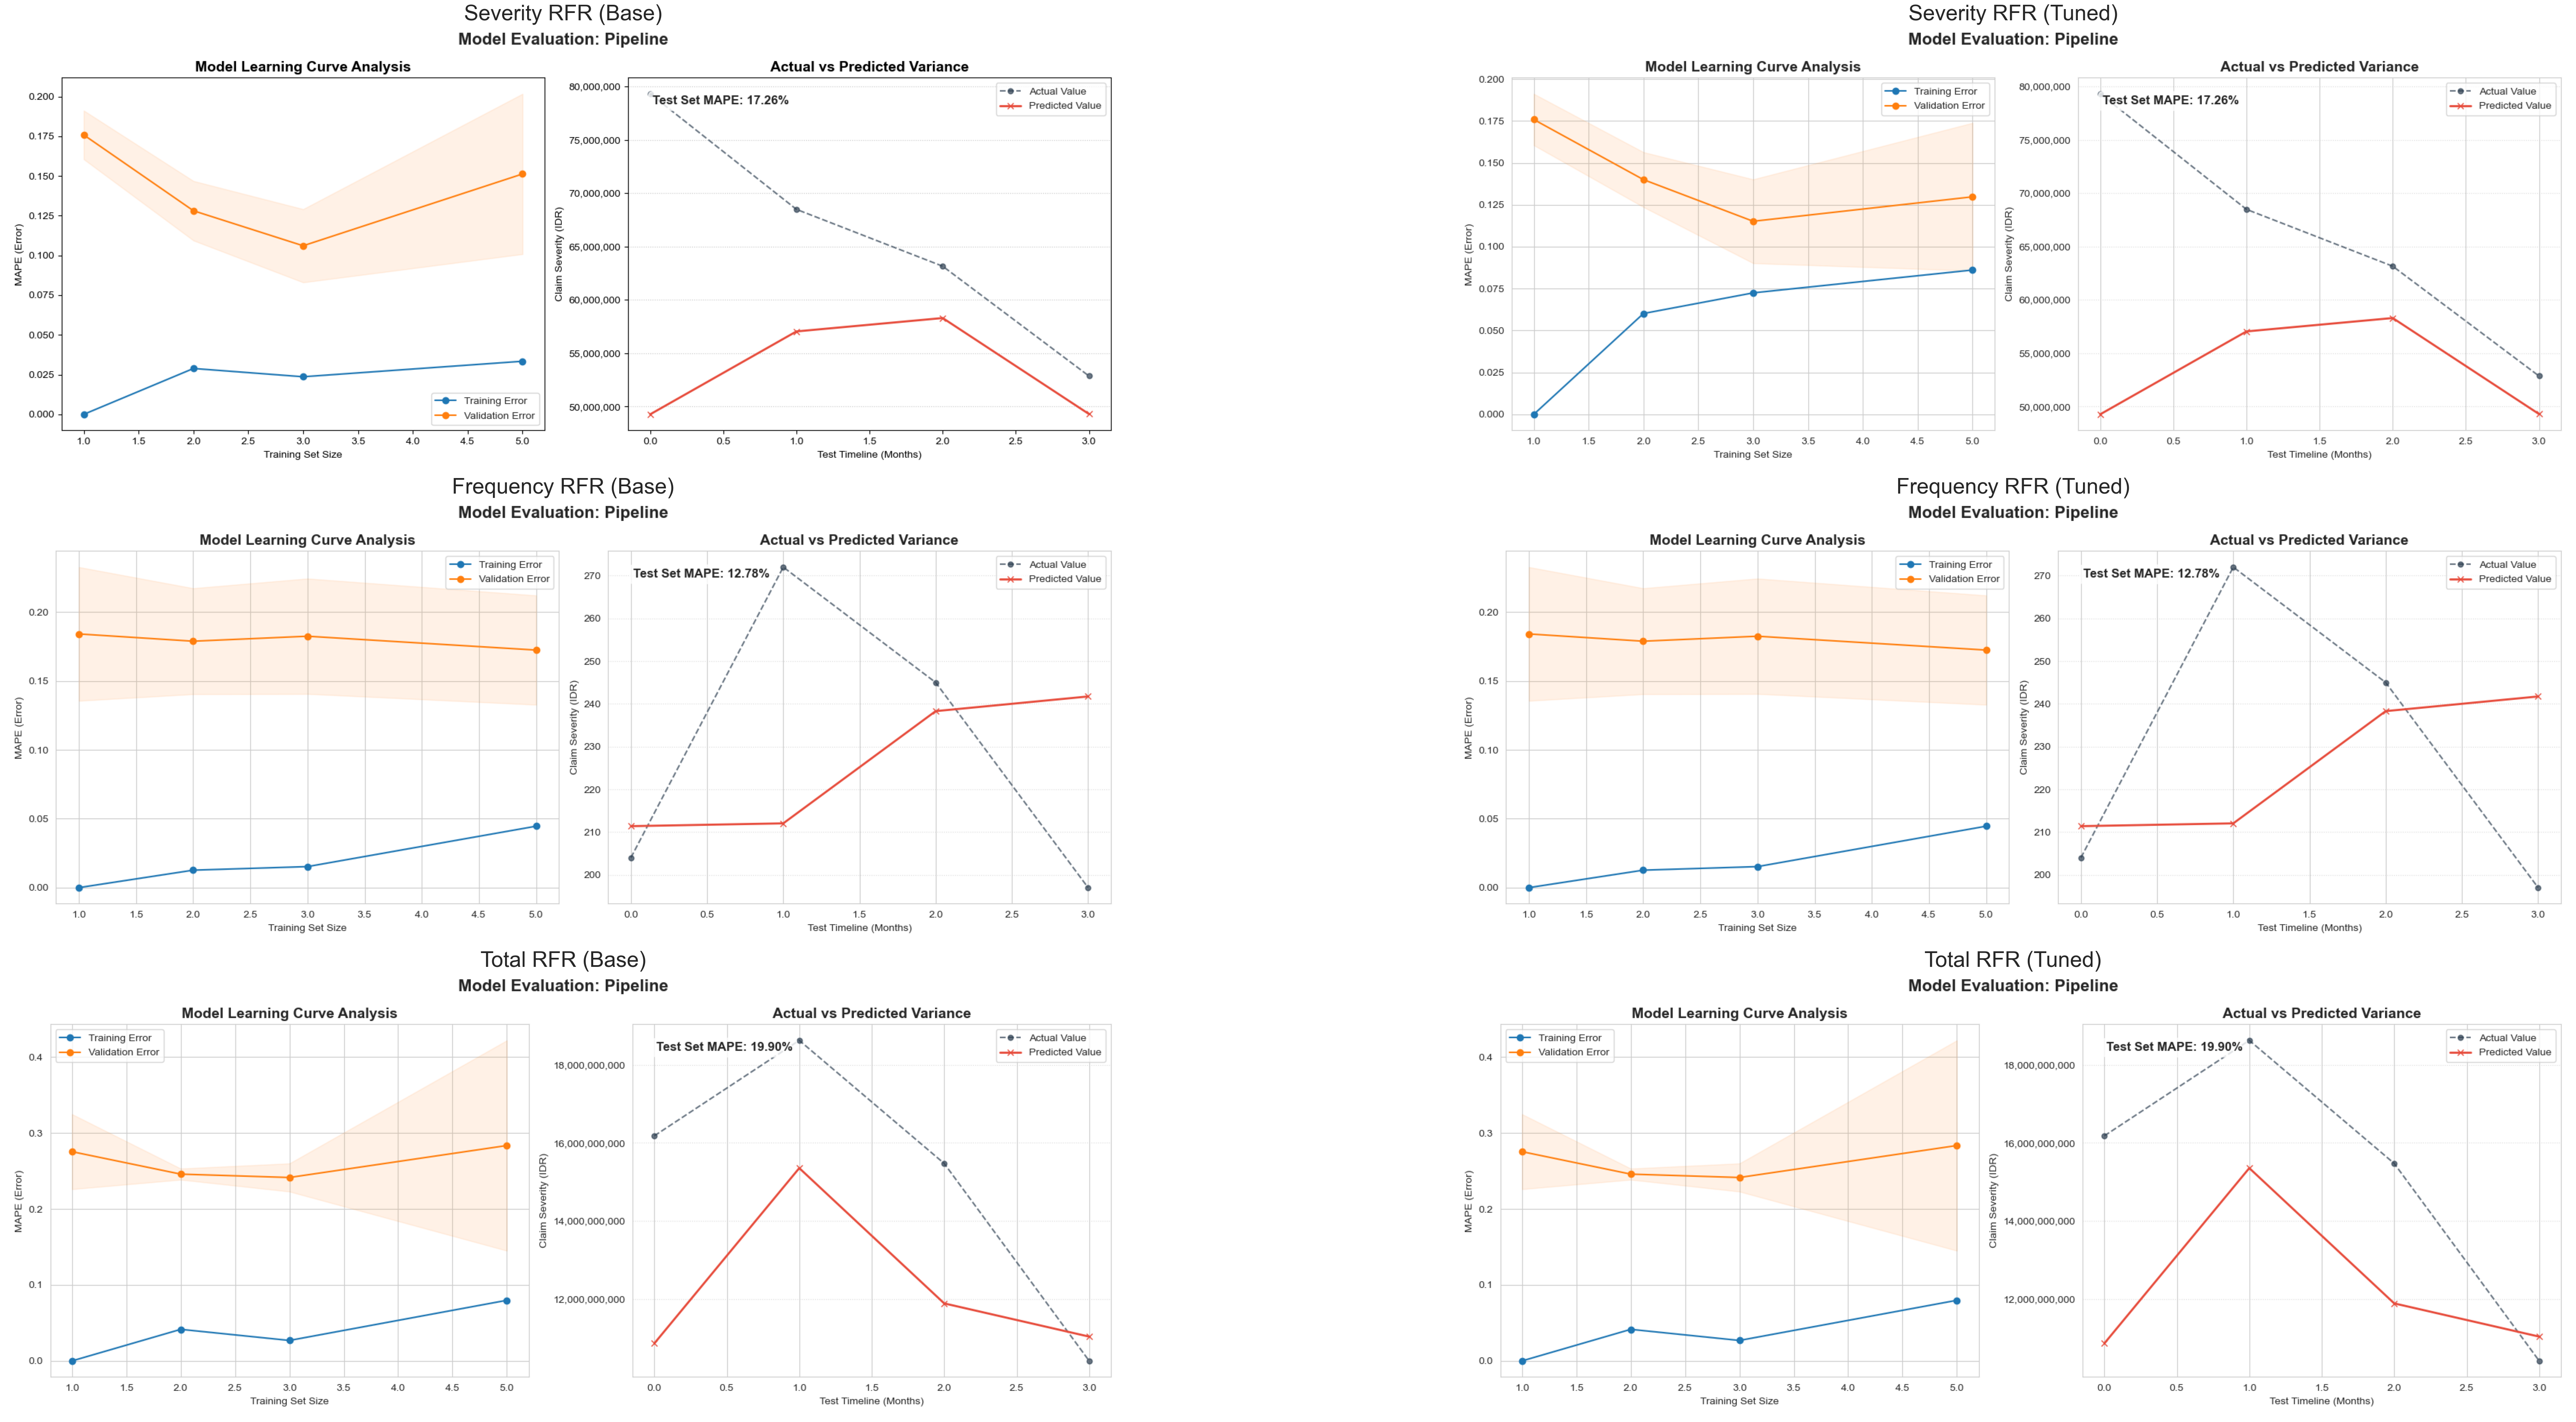

In [59]:
figures = [
    draw_model_sev_rfr, draw_best_sev_rfr,
    draw_model_freq_rfr, draw_best_freq_rfr,
    draw_model_total_rfr, draw_best_total_rfr
]

titles = [
    "Severity RFR (Base)",
    "Severity RFR (Tuned)",
    "Frequency RFR (Base)",
    "Frequency RFR (Tuned)",
    "Total RFR (Base)",
    "Total RFR (Tuned)"
]

fig, axes = plt.subplots(3, 2, figsize=(75,33))
axes = axes.flatten()

for ax, f, title in zip(axes, figures, titles):
    plt.ioff()
    f.canvas.draw()
    img = np.asarray(f.canvas.buffer_rgba())
    ax.imshow(img)
    ax.set_title(title, fontsize=36)
    ax.axis('off')

    plt.close(f)

plt.ion()
plt.tight_layout()
plt.show()

#Hover ke gambar plot lalu tekan Download Image untuk inspect detailnya

##### B.1.5 Summary

In [60]:
summary_rfr = pd.DataFrame({
    "RFR_MAPE_Severity_%": [best_mape_sev_rfr],
    "RFR_MAPE_Frekuensi_%": [best_mape_freq_rfr],
    "RFR_MAPE_Total_Manual_%": [mape_total_best_rfr],
    "RFR_MAPE_Total_Model_%": [best_mape_total_rfr],
    "RFR_SKOR_AKHIR_%": [(best_mape_sev_rfr + best_mape_freq_rfr + mape_total_best_rfr) / 3] 
    #Memakai manual total karena lebih mencerminkan performa gabungan model
    #Summary lainnya menggunakan **model total** karena lebih baik daripada **manual total**
})

display(summary_rfr)

,RFR_MAPE_Severity_%,RFR_MAPE_Frekuensi_%,RFR_MAPE_Total_Manual_%,RFR_MAPE_Total_Model_%,RFR_SKOR_AKHIR_%
0,11.303492,15.575977,23.840813,22.523312,16.906761


#### **B.2. XGB Regressor**

Kita tidak akan menggunakan PCA sebagai feature selector karena dapat mempersulit intepretasi dan rekomendasi bisnis konkret.

XGBRegressor pada dataset asuransi klaim kesehatan dengan data time series memiliki beberapa keunggulan dibandingkan dengan Random Forest Regressor, terutama dalam hal performa dan kemampuan menangani kompleksitas data. 

Kelebihan XGBRegressor
1. **Gradient Boosting**: memungkinkan XGBRegressor untuk menangkap pola yang lebih kompleks dalam data dibandingkan dengan Random Forest, yang membangun banyak pohon secara independen.
2. **Regularisasi**: XGBRegressor memiliki mekanisme regularisasi yang kuat (L1 dan L2) yang membantu mencegah overfitting, terutama pada dataset dengan banyak fitur atau data yang bising. 
3. **Feature Importance** yang lebih deskriptif dan interpretable
4. **Custom Loss Functions**: XGBRegressor memungkinkan penggunaan fungsi loss kustom, yang dapat disesuaikan dengan kebutuhan spesifik dari masalah yang dihadapi, seperti MAPE atau MAE. Random Forest tidak memiliki kemampuan ini, sehingga mungkin tidak sefleksibel dalam mengoptimalkan metrik tertentu.

Potensi Kelemahan XGBRegressor:
1. **Overfitting**: Model yang terlalu kompleks tidak mencerminkan hasil prediksi di dunia nyata.
2. **Sensitivitas terhadap Hyperparameter**: XGBRegressor memiliki banyak hyperparameter yang perlu diatur dengan benar untuk mencapai performa optimal.


##### B.2.1 Severity

In [61]:
xgb_model = XGBRegressor(random_state = 42, n_jobs = -1)

features_sev = features_sev.copy()
target = "claim_severity"
X_sev_train, X_sev_test, y_sev_train, y_sev_test = change_target(df_ts, target, features_sev)
ts_preprocessor = update_preprocessor(features_sev)

In [62]:
model_trend_sev_xgb = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', TransformedTargetRegressor(
      regressor=xgb_model,
      func=np.log1p,
      inverse_func=np.expm1)
    )
])

model_trend_sev_xgb.fit(X_sev_train, y_sev_train)

y_sev_pred_xgb = model_trend_sev_xgb.predict(X_sev_test)
untuned_sev_score_xgb = check_cross_val(model_trend_sev_xgb, X_sev_train, X_sev_test, y_sev_train, y_sev_test, y_sev_pred_xgb)
print(untuned_sev_score_xgb)

--------------- SUMMARY ---------------
CV MAPE: 14.525772210503455
RMSE Severity: 309829316315411.1875
MAE Severity : 13413302.6470
R2 Severity  : -2.4025
--------------- SUMMARY ---------------
MAPE:
14.525772210503455


In [63]:
tscv = TimeSeriesSplit(n_splits=3)
param_grid_sev_xgb = [
    {
        'regressor__regressor__objective': ['reg:absoluteerror'],
        'regressor__regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__regressor__max_depth': [3, 5],
        'regressor__regressor__n_estimators': [100, 200]
    },
    {
        'regressor__regressor__objective': ['reg:tweedie'],
        'regressor__regressor__tweedie_variance_power': [1.3],
        'regressor__regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__regressor__max_depth': [3, 5],
        'regressor__regressor__n_estimators': [100, 200]
    }
]

grid_search_sev_xgb = GridSearchCV(
    estimator=model_trend_sev_xgb,
    param_grid=param_grid_sev_xgb,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=3
)

grid_search_sev_xgb.fit(X_sev_train, y_sev_train)
tuned_model_sev_xgb = grid_search_sev_xgb.best_estimator_

print(f"Best Parameters: {grid_search_sev_xgb.best_params_}")
tuned_sev_score_xgb = -grid_search_sev_xgb.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_sev_xgb.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'regressor__regressor__learning_rate': 0.01, 'regressor__regressor__max_depth': 3, 'regressor__regressor__n_estimators': 200, 'regressor__regressor__objective': 'reg:absoluteerror'}
Best CV Score (MAPE): 8.7072%


##### B.2.2 Frekuensi

In [64]:
xgb_model = XGBRegressor(random_state = 42, n_jobs = -1, objective="reg:absoluteerror")

features_freq = features_freq.copy()
# features_freq.remove('claim_frequency')

target = 'claim_frequency'
X_freq_train, X_freq_test, y_freq_train, y_freq_test = change_target(df_ts, target, features_freq)
ts_preprocessor = update_preprocessor(features_freq)

In [65]:
model_trend_freq_xgb = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', TransformedTargetRegressor(
      regressor=xgb_model,
      func=np.log1p,
      inverse_func=np.expm1)
    )
])

model_trend_freq_xgb.fit(X_freq_train, y_freq_train)

y_freq_pred_xgb = model_trend_freq_xgb.predict(X_freq_test)
untuned_freq_score_xgb = check_cross_val(model_trend_freq_xgb, X_freq_train, X_freq_test, y_freq_train, y_freq_test, y_freq_pred_xgb)
print(untuned_freq_score_xgb)

--------------- SUMMARY ---------------
CV MAPE: 19.71160819133123
RMSE Severity: 1572.7124
MAE Severity : 31.4103
R2 Severity  : -0.6762
--------------- SUMMARY ---------------
MAPE:
19.71160819133123


In [66]:
tscv = TimeSeriesSplit(n_splits=3)
param_grid_freq_xgb = [
    {
        'regressor__regressor__objective': ['reg:absoluteerror'],
        'regressor__regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__regressor__max_depth': [None, 3, 5],
        'regressor__regressor__n_estimators': [100, 200]
    },
    {
        'regressor__regressor__objective': ['reg:tweedie'],
        'regressor__regressor__tweedie_variance_power': [1.3],
        'regressor__regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__regressor__max_depth': [3, 5],
        'regressor__regressor__n_estimators': [100, 200]
    }
]
    
grid_search_freq_xgb = GridSearchCV(
    estimator=model_trend_freq_xgb,
    param_grid=param_grid_freq_xgb,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=3
)

grid_search_freq_xgb.fit(X_freq_train, y_freq_train)

tuned_model_freq_xgb = grid_search_freq_xgb.best_estimator_
print(f"Best Parameters: {grid_search_freq_xgb.best_params_}")

tuned_freq_score_xgb = -grid_search_freq_xgb.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_freq_xgb.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'regressor__regressor__learning_rate': 0.01, 'regressor__regressor__max_depth': 3, 'regressor__regressor__n_estimators': 200, 'regressor__regressor__objective': 'reg:absoluteerror'}
Best CV Score (MAPE): 16.4649%


**Pemilihan Model XGB Severity & Frekuensi:**

Severity:
- Baseline (Default): 13.2114%
- HyperParameter Tuning: 11.8008% -> Gunakan ini

Frequency:
- Baseline (Default): 30.1184%
- HyperParameter Tuning: 20.8883% -> Gunakan ini

##### B.2.3 Total Aktual

In [67]:
xgb_model = XGBRegressor(random_state = 42, n_jobs = -1, objective="reg:absoluteerror")

features_total = features_all.copy()
target = "total_claim"

X_total_train, X_total_test, y_total_train, y_total_test = change_target(df_ts, target, features_total)
ts_preprocessor = update_preprocessor(features_total)

In [68]:
model_trend_total_xgb = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', xgb_model)
])

model_trend_total_xgb.fit(X_total_train, y_total_train)

y_total_pred_xgb = model_trend_total_xgb.predict(X_total_test)

untuned_total_score_xgb = check_cross_val(model_trend_total_xgb, X_total_train, X_total_test, y_total_train, y_total_test, y_total_pred_xgb)
print(untuned_total_score_xgb)

--------------- SUMMARY ---------------
CV MAPE: 15.567154081597726
RMSE Severity: 20221327432114950144.0000
MAE Severity : 3981125104.5950
R2 Severity  : -1.2668
--------------- SUMMARY ---------------
MAPE:
15.567154081597726


In [69]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_total_xgb = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7], # Untuk data sedikit, depth 10-15 biasanya terlalu berisiko (overfit)
    'regressor__min_child_weight': [1, 2, 5], 
    'regressor__learning_rate': [0.01, 0.05, 0.1] 
}

grid_search_total_xgb = GridSearchCV(
    estimator=model_trend_total_xgb,
    param_grid=param_grid_total_xgb,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 1
)

grid_search_total_xgb.fit(X_total_train, y_total_train)

tuned_model_total_xgb = grid_search_total_xgb.best_estimator_
print(f"Best Parameters: {grid_search_total_xgb.best_params_}")

tuned_total_score_xgb = -grid_search_total_xgb.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_total_xgb.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__min_child_weight': 1, 'regressor__n_estimators': 200}
Best CV Score (MAPE): 13.6315%


##### B.2.4 Seleksi Model Terbaik

In [70]:
#Severity
if untuned_sev_score_xgb < tuned_sev_score_xgb:
    best_model_sev_xgb = model_trend_sev_xgb
    y_sev_pred_xgb = model_trend_sev_xgb.predict(X_sev_test)
    best_mape_sev_xgb = untuned_sev_score_xgb
    print(f"Seleksi Model Severity: Menggunakan model Untuned, MAPE: {untuned_sev_score_xgb}")
else:
    best_model_sev_xgb = tuned_model_sev_xgb
    y_sev_pred_xgb = tuned_model_sev_xgb.predict(X_sev_test)
    best_mape_sev_xgb = tuned_sev_score_xgb
    print(f"Seleksi Model Severity: Menggunakan model Tuned, MAPE: {-grid_search_sev_xgb.best_score_ * 100:.4f}")
    
#Frekuensi
if untuned_freq_score_xgb < tuned_freq_score_xgb:
    best_model_freq_xgb = model_trend_freq_xgb
    y_freq_pred_xgb = model_trend_freq_xgb.predict(X_freq_test)
    best_mape_freq_xgb = untuned_freq_score_xgb
    print(f"Seleksi Model Frekuensi: Menggunakan model Untuned, MAPE: {untuned_freq_score_xgb:.4f}")
else:
    best_model_freq_xgb = model_trend_freq_xgb
    y_freq_pred_xgb = tuned_model_freq_xgb.predict(X_freq_test)
    best_mape_freq_xgb = tuned_freq_score_xgb
    print(f"Seleksi Model Frekuensi: Menggunakan model Tuned, MAPE: {-grid_search_freq_xgb.best_score_ * 100:.4f}")

if untuned_total_score_xgb < tuned_total_score_xgb:
    best_model_total_xgb = model_trend_total_xgb
    y_total_pred_xgb = model_trend_total_xgb.predict(X_total_test)
    best_mape_total_xgb = untuned_total_score_xgb
    print(f"Seleksi Model Total: Menggunakan model Untuned, MAPE: {untuned_total_score_xgb:.4f}")
else:
    best_model_total_xgb = tuned_model_total_xgb
    y_total_pred_xgb = tuned_model_total_xgb.predict(X_total_test)
    best_mape_total_xgb = tuned_total_score_xgb
    print(f"Seleksi Model Total: Menggunakan model Tuned, MAPE: {-grid_search_total_xgb.best_score_ * 100:.4f}")

Seleksi Model Severity: Menggunakan model Tuned, MAPE: 8.7072
Seleksi Model Frekuensi: Menggunakan model Tuned, MAPE: 16.4649
Seleksi Model Total: Menggunakan model Tuned, MAPE: 13.6315


In [71]:
y_sev_pred_xgb = best_model_sev_xgb.predict(X_sev_test)
y_freq_pred_xgb = y_freq_pred_xgb

total_claim_pred_best = y_sev_pred_xgb * y_freq_pred_xgb
total_claim_actual = y_sev_test * y_freq_test

mape_total_best_xgb = mape_score(total_claim_actual, total_claim_pred_best)
mape_total_best_xgb

np.float64(23.29130054814555)

In [72]:
plt.ioff()
draw_model_sev_xgb, ax = draw_model_evaluation(model_trend_sev_xgb, X_sev_train, y_sev_train, X_sev_test, y_sev_test, y_sev_pred_xgb)
draw_best_sev_xgb, ax = draw_model_evaluation(best_model_sev_xgb, X_sev_train, y_sev_train, X_sev_test, y_sev_test, y_sev_pred_xgb)
draw_model_freq_xgb, ax = draw_model_evaluation(model_trend_freq_xgb, X_freq_train, y_freq_train, X_freq_test, y_freq_test, y_freq_pred_xgb)
draw_best_freq_xgb, ax = draw_model_evaluation(best_model_freq_xgb, X_freq_train, y_freq_train, X_freq_test, y_freq_test, y_freq_pred_xgb)
draw_model_total_xgb, ax = draw_model_evaluation(model_trend_total_xgb, X_total_train, y_total_train, X_total_test, y_total_test, y_total_pred_xgb)
draw_best_total_xgb, ax = draw_model_evaluation(best_model_total_xgb, X_total_train, y_total_train, X_total_test, y_total_test, y_total_pred_xgb)
plt.ion()

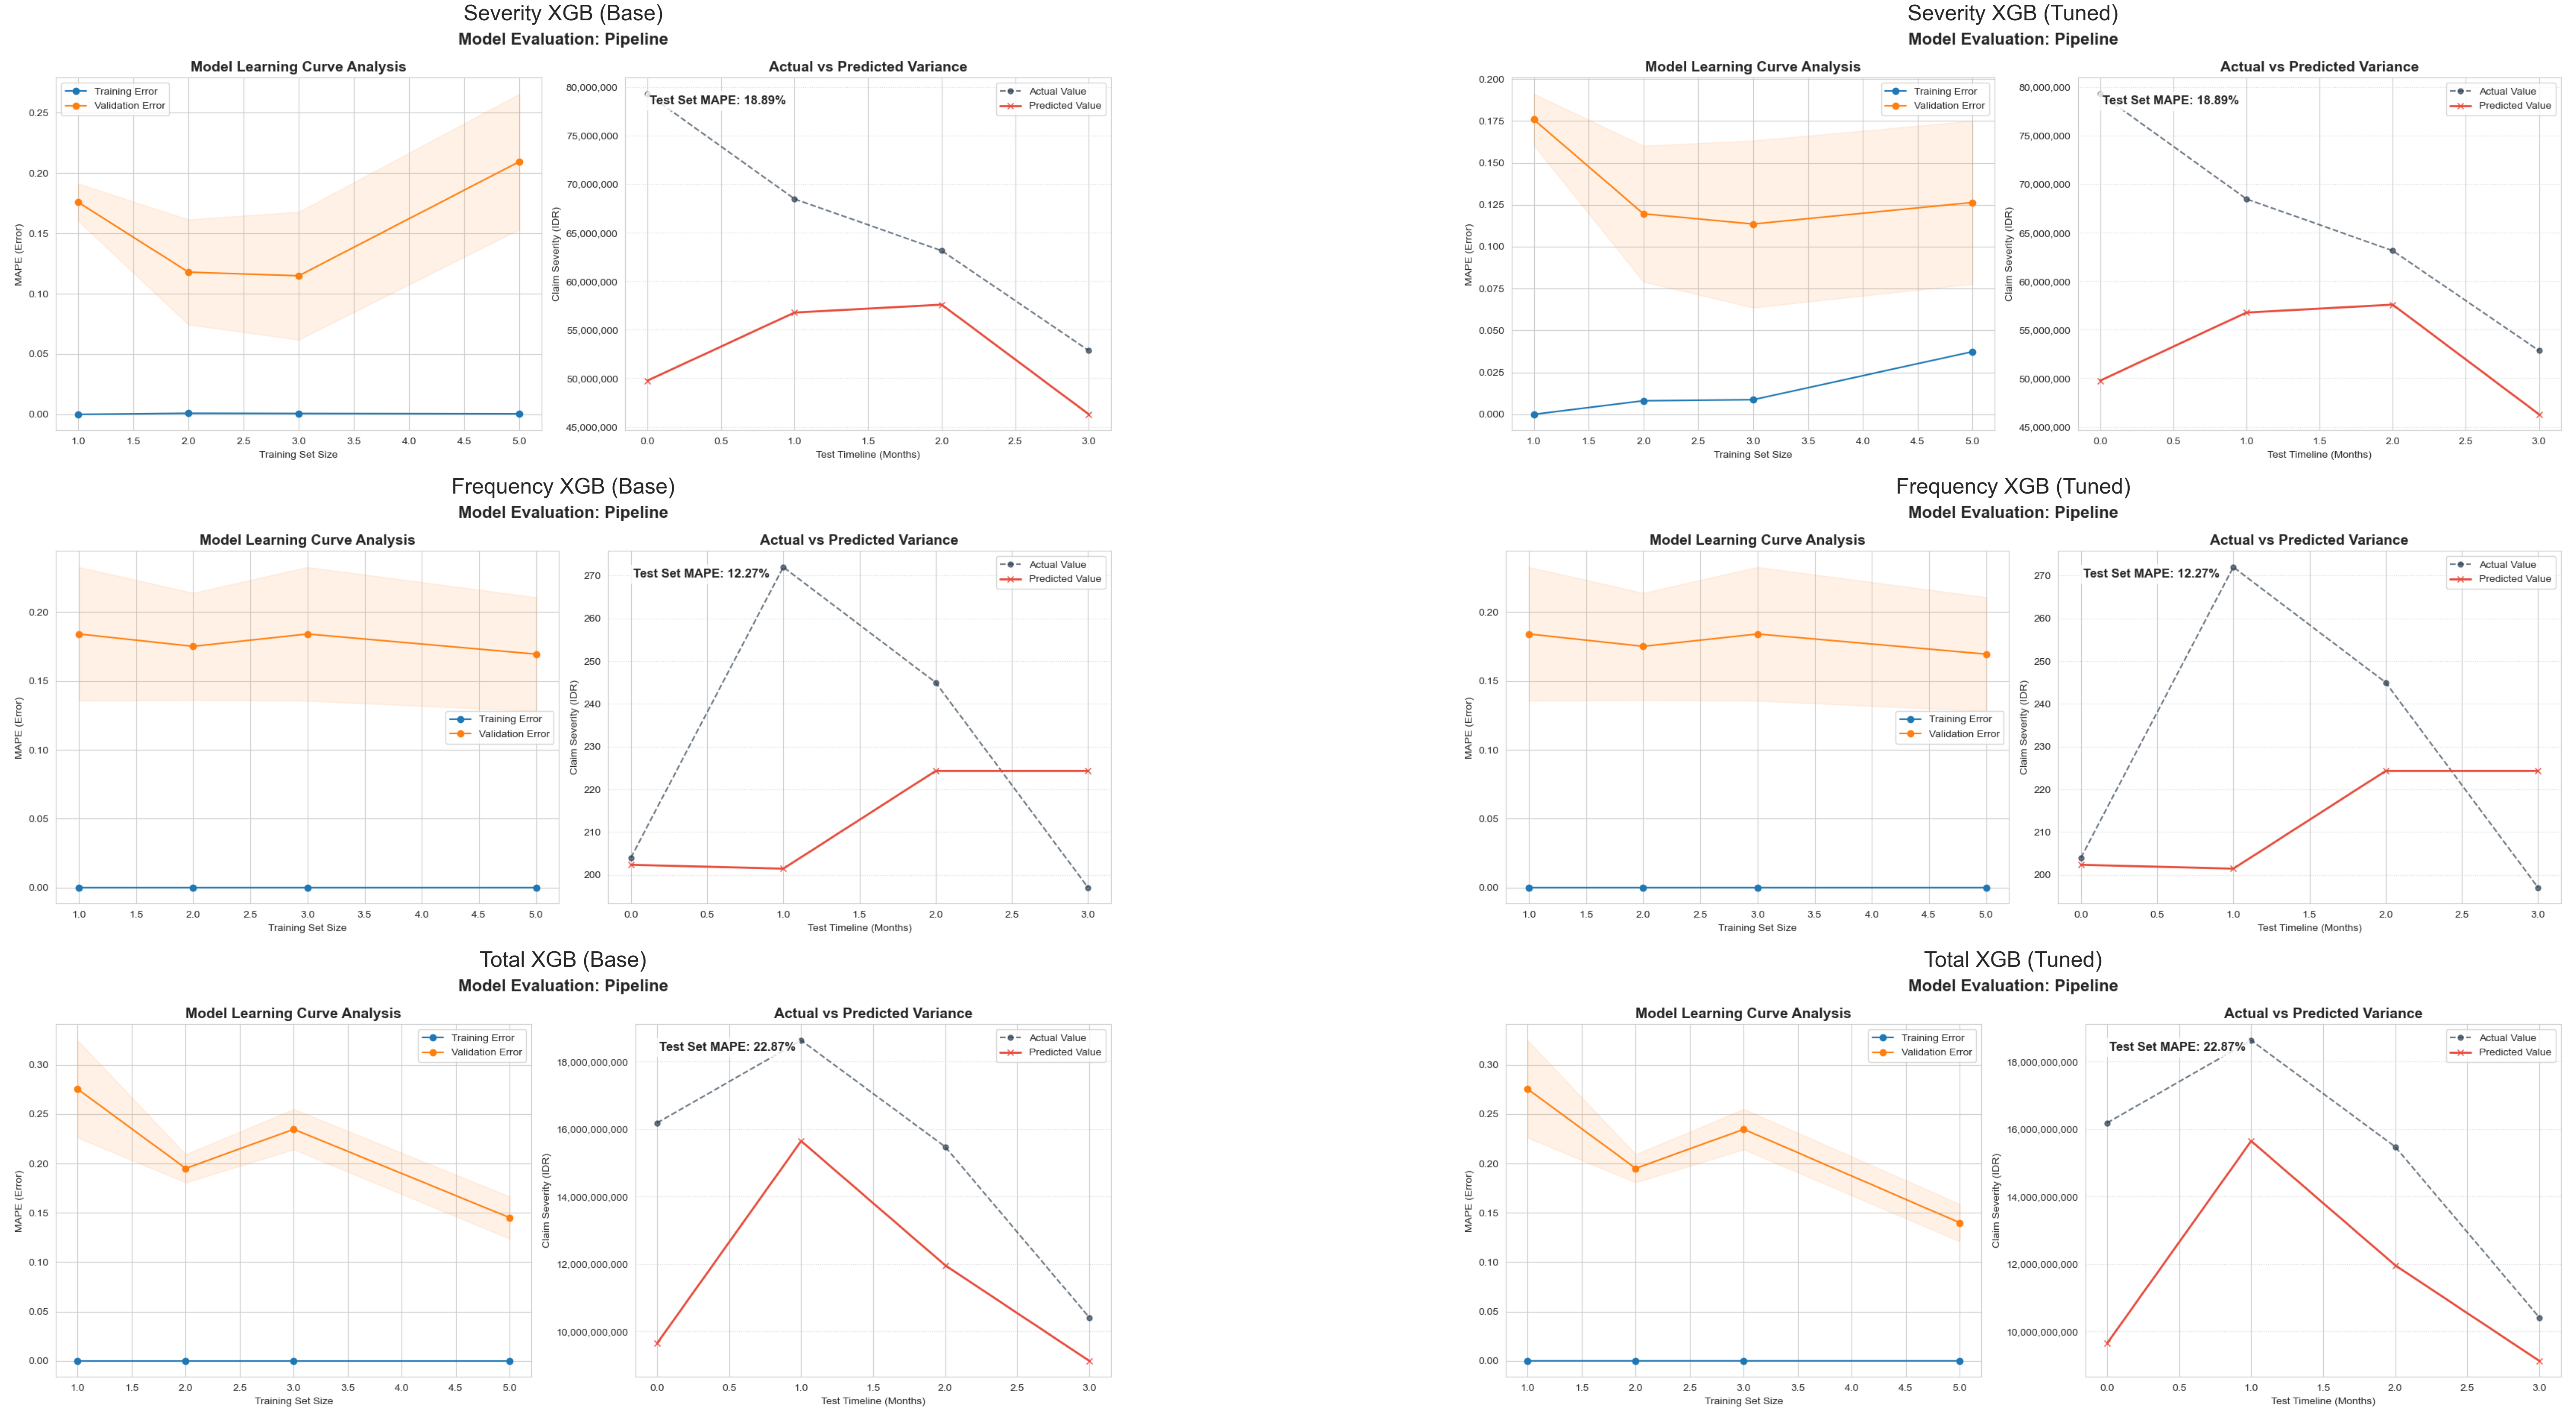

In [73]:
figures = [
    draw_model_sev_xgb, draw_best_sev_xgb,
    draw_model_freq_xgb, draw_best_freq_xgb,
    draw_model_total_xgb, draw_best_total_xgb
]

titles = [
    "Severity XGB (Base)",
    "Severity XGB (Tuned)",
    "Frequency XGB (Base)",
    "Frequency XGB (Tuned)",
    "Total XGB (Base)",
    "Total XGB (Tuned)"
]

fig, axes = plt.subplots(3, 2, figsize=(75,33))
axes = axes.flatten()

for ax, f, title in zip(axes, figures, titles):
    plt.ioff()
    f.canvas.draw()
    img = np.asarray(f.canvas.buffer_rgba())
    ax.imshow(img)
    ax.set_title(title, fontsize=36)
    ax.axis('off')

    plt.close(f)

plt.ion()
plt.tight_layout()
plt.show()

#Hover ke gambar plot lalu tekan Download Image untuk inspect detailnya

##### B.2.5 Summary

In [74]:
summary_xgb = pd.DataFrame({
    "XGB_MAPE_Severity_%": [best_mape_sev_xgb],
    "XGB_MAPE_Frekuensi_%": [best_mape_freq_xgb],
    "XGB_MAPE_Total_Manual_%": [mape_total_best_xgb],
    "XGB_MAPE_Total_Model_%": [tuned_total_score_xgb],
    "XGB_SKOR_AKHIR_%": [(best_mape_sev_xgb + best_mape_freq_xgb + tuned_total_score_xgb) / 3]
})

display(summary_xgb)

,XGB_MAPE_Severity_%,XGB_MAPE_Frekuensi_%,XGB_MAPE_Total_Manual_%,XGB_MAPE_Total_Model_%,XGB_SKOR_AKHIR_%
0,8.707242,16.46492,23.291301,13.631472,12.934545


#### **B.3. GLM - Generalized Linear Model**

GLM pada dataset asuransi sering digunakan untuk memodelkan klaim karena dapat menangani distribusi target yang tidak normal, seperti klaim yang seringkali memiliki banyak nilai nol (tidak ada klaim) dan beberapa nilai yang sangat tinggi (klaim besar). 

Kelebihan menggunakan GLM meliputi:
1. **Fleksibilitas Distribusi**: GLM memungkinkan kita untuk memilih distribusi yang sesuai dengan karakteristik data, seperti Poisson untuk frekuensi klaim atau Gamma untuk severity klaim, sehingga model dapat lebih akurat.
2. **Fungsi Link**: GLM menggunakan fungsi link untuk menghubungkan variabel independen dengan variabel dependen, memungkinkan kita untuk menangani hubungan non-linear antara fitur dan target.
3. **Interpretabilitas**: Koefisien dalam GLM dapat diinterpretasikan secara langsung, memberikan wawasan tentang bagaimana setiap fitur mempengaruhi klaim, yang sangat penting dalam industri asuransi untuk pengambilan keputusan.

Kekurangan menggunakan GLM meliputi:
1. **Asumsi Distribusi**: GLM mengasumsikan bahwa data mengikuti distribusi tertentu, dan jika asumsi ini tidak terpenuhi, model dapat memberikan hasil yang kurang akurat.
2. **Sensitivitas terhadap Outlier**: GLM dapat sangat dipengaruhi oleh outlier, terutama dalam kasus klaim besar, yang dapat mendistorsi model dan menghasilkan prediksi yang tidak realistis.
3. **Prediction Explosion**: GLM, terutama dengan distribusi seperti Poisson atau Gamma, dapat menghasilkan prediksi yang sangat tinggi jika ada kombinasi fitur yang tidak biasa atau outlier, yang dikenal sebagai "prediction explosion". Hal ini dapat menyebabkan model memberikan prediksi klaim yang tidak realistis dan sulit untuk diinterpretasikan.
4. **Rentan Error pada log transform dan link function exponent**, interpretasi menjadi lebih sulit karena hubungan antara fitur dan target tidak lagi linear saat diprediksi menggunakan forecast.

In [75]:
def change_target_GLM(df, target, log_features, no_log_features):

    scaler = RobustScaler()

    log_features = log_features.copy()
    no_log_features = no_log_features.copy()

    if target in log_features:
        log_features.remove(target)

    if target in no_log_features:
        no_log_features.remove(target)

    X_log = np.log(df[log_features] + 1)
    X_no_log = df[no_log_features]

    X = pd.concat([X_log, X_no_log], axis=1)
    y = np.log(df[target] / 1_000_000 + 1)

    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

    X_scaled = sm.add_constant(X_scaled)

    split = int(len(X_scaled) * 0.8)

    X_train = X_scaled.iloc[:split]
    X_test  = X_scaled.iloc[split:]

    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]

    return X_train, X_test, y_train, y_test

##### B.3.1. Severity

In [76]:
print(features_sev)

log_features = ['lag_1', 'lag_3', 'rolling_mean_2']
no_log_features = ['month_sin', 'month_cos']

target = "claim_severity"

X_sev_train, X_sev_test, y_sev_train, y_sev_test = change_target_GLM(df_ts, target, log_features, no_log_features)

['lag_1', 'lag_3', 'rolling_mean_2', 'rolling_mean_3', 'month_sin', 'month_cos']


In [77]:
tscv = TimeSeriesSplit(n_splits=5)
sev_mape_scores = []
models_sev_GLM = []
y_pred_sev_GLM = []

for train_index, val_index in tscv.split(X_sev_train):

    X_train_cv = X_sev_train.iloc[train_index]
    X_val_cv = X_sev_train.iloc[val_index]

    y_train_cv = y_sev_train.iloc[train_index]
    y_val_cv = y_sev_train.iloc[val_index]

    model_sev_GLM = sm.GLM(
        y_train_cv,
        X_train_cv,
        family=sm.families.Poisson(sm.families.links.log())
    )

    result = model_sev_GLM.fit_regularized(
      alpha=0.01,
      maxiter=500
    )

    y_pred_sev_GLM = result.predict(X_val_cv)

    mape = np.mean(np.abs((y_val_cv - y_pred_sev_GLM) / (y_val_cv + 1))) * 100

    sev_mape_scores.append(mape)
    models_sev_GLM.append(result)   # simpan model fold

print("MAPE per fold:", sev_mape_scores)
print("Mean CV MAPE:", np.mean(sev_mape_scores))
print("Std CV MAPE:", np.std(sev_mape_scores))

c:\Users\Alvin\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


MAPE per fold: [np.float64(2.509285848007079), np.float64(4.574705942633566), np.float64(4.408356187619861), np.float64(2.2226899649218557), np.float64(3.8365684509225457)]
Mean CV MAPE: 3.5103212788209817
Std CV MAPE: 0.9701427690359262


In [78]:
sev_best_index = np.argmin(sev_mape_scores)
best_model_sev_GLM = models_sev_GLM[sev_best_index] #simpan model terbaik


print("Best Fold Index:", sev_best_index)
print("Best MAPE:", sev_mape_scores[sev_best_index])

Best Fold Index: 3
Best MAPE: 2.2226899649218557


##### B.3.2 Frekuensi

In [79]:
def change_target_GLM_freq(df, target, features):

    features = features.copy()
    if target in features:
        features.remove(target)

    X = df[features]
    y = df[target]

    split = int(len(X) * 0.8)

    X_train = X.iloc[:split].copy()
    X_test  = X.iloc[split:].copy()

    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]

    # scaling
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # kembali ke dataframe
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled  = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

    # add intercept
    X_train_scaled = sm.add_constant(X_train_scaled)
    X_test_scaled  = sm.add_constant(X_test_scaled)

    return X_train_scaled, X_test_scaled, y_train, y_test

In [80]:
target = "claim_frequency"
X_freq_train, X_freq_test, y_freq_train, y_freq_test = change_target_GLM_freq(df_ts, target, features_freq)

tscv = TimeSeriesSplit(n_splits=5)

freq_mape_scores = []
models_freq_GLM = []
for train_index, val_index in tscv.split(X_freq_train):

  X_train_cv = X_freq_train.iloc[train_index]
  X_val_cv = X_freq_train.iloc[val_index]

  y_train_cv = y_freq_train.iloc[train_index]
  y_val_cv = y_freq_train.iloc[val_index]

  model_freq_GLM = sm.GLM(
      y_train_cv,
      X_train_cv,
      family=sm.families.Gamma(sm.families.links.log())
  )

  result = model_freq_GLM.fit_regularized(alpha=0.01, maxiter=500)

  y_pred = result.predict(X_val_cv)

  mape = np.mean(np.abs((y_val_cv - y_pred) / (y_val_cv + 1))) * 100
  freq_mape_scores.append(mape)
  models_freq_GLM.append(result)   # simpan model fold

print("MAPE per fold:", freq_mape_scores)
print("Mean CV MAPE:", np.mean(freq_mape_scores))
print("Std CV MAPE:", np.std(freq_mape_scores))

c:\Users\Alvin\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Alvin\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\Alvin\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")
c:\Users\Alvin\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Alvin\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by 

MAPE per fold: [np.float64(21.998167863248238), np.float64(17.694508396497866), np.float64(14.966280254717162), np.float64(40.075114956100876), np.float64(12.323687682532153)]
Mean CV MAPE: 21.41155183061926
Std CV MAPE: 9.865291878712336


In [81]:
freq_best_index = np.argmin(freq_mape_scores)
best_model_freq_GLM = models_freq_GLM[freq_best_index]

print("Best fold:", freq_best_index)
print("Best MAPE:", freq_mape_scores[freq_best_index])

Best fold: 4
Best MAPE: 12.323687682532153


##### B.3.3 Total Aktual

In [82]:
print(features_all)

['claim_frequency', 'month_num', 'year_num', 'lag_1', 'lag_2', 'lag_3', 'time_index', 'trend', 'rolling_mean_2', 'rolling_median_2', 'rolling_std_2', 'rolling_mean_3', 'rolling_median_3', 'rolling_std_3', 'rolling_trend_2', 'mom_1', 'sev_lag3', 'freq_lag1', 'freq_lag2', 'freq_lag3', 'freq_roll3', 'month_sin', 'month_cos']


In [83]:
target = "total_claim"
log_features = ['lag_1', 'lag_3', 'rolling_mean_2', 'rolling_median_2', "trend",'rolling_std_2', 'rolling_mean_3', 'rolling_median_3', 'rolling_std_3', 'mom_1', 'sev_lag3', 'freq_lag1', 'freq_lag2', 'freq_lag3','freq_roll3' ]
no_log_features = ['month_sin', 'month_cos', 'month_num', 'year_num', 'rolling_trend_2']
X_total_train, X_total_test, y_total_train, y_total_test = change_target_GLM(df_ts, target, log_features, no_log_features)

tscv = TimeSeriesSplit(n_splits=5)

total_mape_scores = []
models_total_GLM = []
for train_index, val_index in tscv.split(X_total_train):

  X_train_cv = X_total_train.iloc[train_index]
  X_val_cv = X_total_train.iloc[val_index]

  y_train_cv = y_total_train.iloc[train_index]
  y_val_cv = y_total_train.iloc[val_index]

  model_total_GLM = sm.GLM(
      y_train_cv,
      X_train_cv,
      family=sm.families.Gamma(sm.families.links.log())
  )

  result = model_total_GLM.fit_regularized(alpha=0.01, maxiter=500)

  y_pred = result.predict(X_val_cv)

  mape = np.mean(np.abs((y_val_cv - y_pred) / (y_val_cv + 1))) * 100
  total_mape_scores.append(mape)
  models_total_GLM.append(result)   # simpan model fold

print("MAPE per fold:", total_mape_scores)
print("Mean CV MAPE:", np.mean(total_mape_scores))
print("Std CV MAPE:", np.std(total_mape_scores))

c:\Users\Alvin\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Alvin\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\Alvin\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


MAPE per fold: [np.float64(9.073155747932752), np.float64(2.202061591024544), np.float64(2.690351047089765), np.float64(2.179098452911808), np.float64(3.575532132903969)]
Mean CV MAPE: 3.944039794372568
Std CV MAPE: 2.613995785628856


In [84]:
total_best_index = np.argmin(total_mape_scores)
best_model_total_GLM = models_sev_GLM[total_best_index] #simpan model terbaik

print("Best Fold Index:", total_best_index)
print("Best MAPE:", total_mape_scores[total_best_index])

Best Fold Index: 3
Best MAPE: 2.179098452911808


In [85]:
y_sev_pred_log = best_model_sev_GLM.predict(X_sev_test)
y_freq_pred_raw = best_model_freq_GLM.predict(X_freq_test)

y_sev_pred_real = (np.exp(y_sev_pred_log) - 1)
y_sev_test_real = (np.exp(y_sev_test) - 1)

total_claim_pred_best = y_sev_pred_real * y_freq_pred_raw
total_claim_actual = y_sev_test_real * y_freq_test

mape_total_best_glm = mape_score(total_claim_actual, total_claim_pred_best)

print(f"MAPE Total Claim: {mape_total_best_glm:.4f}%")

MAPE Total Claim: 28.0237%


Mengapa hasil prediksi total claim sangat tinggi meski frekuensi dan severitas MAPE rendah?

Compounding Error + Error Galat yang bertumpukkan, menghasilkan error yang signifikan dibanding GLM Severitas dan Frekuensi

Mengapa Tidak Severity -> Gamma, Frekuensi -> Poisson?

Gamma seringkali memberikan error variance yang lebih besar, meski MAPE terlihat lebih bagus. Masalah ini diamplifikasi oleh dataset setelah agregasi yang masih cukup dikit. Hasil prediksi total_klaim dapat membengkak signifikan, sehingga kita gunakan poisson yang lebih stabil untuk kasus umum.

##### B.3.4 Summary

In [86]:
summary_glm = pd.DataFrame({
    "GLM_MAPE_Severity_%": [sev_mape_scores[sev_best_index]],
    "GLM_MAPE_Frekuensi_%": [freq_mape_scores[freq_best_index]],
    "GLM_MAPE_Total_Manual_%": [mape_total_best_glm],
    "GLM_MAPE_Total_Model_%": [total_mape_scores[total_best_index]],
    "GLM_SKOR_AKHIR_%": [(sev_mape_scores[sev_best_index] + freq_mape_scores[freq_best_index] + mape_total_best_glm) / 3]
})

display(summary_glm)

,GLM_MAPE_Severity_%,GLM_MAPE_Frekuensi_%,GLM_MAPE_Total_Manual_%,GLM_MAPE_Total_Model_%,GLM_SKOR_AKHIR_%
0,2.22269,12.323688,28.023709,2.179098,14.190029


In [87]:
print(f"Jumlah baris X_freq_test: {len(X_freq_test)}")
print(f"Jumlah baris y_freq_pred: {len(y_freq_pred_raw)}")

print(f"Jumlah baris X_sev_test : {len(X_sev_test)}")
print(f"Jumlah baris y_sev_pred : {len(y_sev_pred_real)}")

Jumlah baris X_freq_test: 4
Jumlah baris y_freq_pred: 4
Jumlah baris X_sev_test : 4
Jumlah baris y_sev_pred : 4


In [88]:
# Cek apakah indeks antara Frekuensi dan Severity sama persis
is_synced = X_freq_test.index.equals(X_sev_test.index)
print(f"Apakah indeks data Frekuensi dan Severity sinkron? {is_synced}")

if not is_synced:
    # Cari tahu indeks mana yang hilang
    missing_indices = X_freq_test.index.difference(X_sev_test.index)
    print(f"Indeks yang hilang di Severity: {missing_indices}")

Apakah indeks data Frekuensi dan Severity sinkron? True


In [89]:
print(f"NaN di Prediksi Frekuensi: {np.isnan(y_freq_pred_raw).sum()}")
print(f"NaN di Prediksi Severity : {np.isnan(y_sev_pred_real).sum()}")

NaN di Prediksi Frekuensi: 0
NaN di Prediksi Severity : 0


#### **B.4 LightGBM**

LightGBM pada dataset asuransi dapat menyediakan performa yang baik, namun rentan terhadap overfitting, terutama
dengan data time series kecil (<1000 baris) bisa jadi kurang optimal.

Kelebihan LGBM:
- Kecepatan tinggi dalam pelatihan dan prediksi.
- Kemampuan menangani fitur kategorikal secara efisien.
- Fitur regularisasi yang membantu mengurangi overfitting.
- Sangat baik untuk dataset besar dengan banyak fitur.
- Memberikan skor akurasi dan MAPE yang kompetitif pada banyak kasus.

Kekurangan LGBM:
- Rentan terhadap overfitting, terutama pada dataset kecil atau dengan noise tinggi.
- Memerlukan tuning hyperparameter yang cermat untuk performa optimal.
- Kurang transparan dibandingkan model linear, sehingga interpretasi bisa lebih sulit.
- Pada dataset asuransi yang seringkali memiliki pola musiman dan tren, LGBM mungkin tidak menangkap dinamika temporal dengan baik tanpa fitur rekayasa yang tepat.

##### B.4.1 Severity

In [90]:
lgbm_sev_model = LGBMRegressor(random_state = 42,
                           n_jobs = -1,
                           verbosity = -1, #uncomment ini jika ingin suppress warning dari LightGBM
                           min_data_in_leaf = 1,
                           min_child_samples=1,
                           learning_rate=0.01,
                           n_estimators=200,)

features_sev = features_sev.copy()
target = "claim_severity"
X_sev_train, X_sev_test, y_sev_train, y_sev_test = change_target(df_ts, target, features_sev)
ts_preprocessor = update_preprocessor(features_sev)

In [91]:
model_trend_sev_lgbm = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', TransformedTargetRegressor(
      regressor=lgbm_sev_model,
      func=np.log1p,
      inverse_func=np.expm1)
    )
])

model_trend_sev_lgbm.fit(X_sev_train, y_sev_train)

y_sev_pred_lgbm = model_trend_sev_lgbm.predict(X_sev_test)
untuned_sev_score_lgbm = check_cross_val(model_trend_sev_lgbm, X_sev_train, X_sev_test, y_sev_train, y_sev_test, y_sev_pred_lgbm)
print(untuned_sev_score_lgbm)

c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


--------------- SUMMARY ---------------
CV MAPE: 20.63598805190695
RMSE Severity: 369626805881513.0000
MAE Severity : 14369746.2861
R2 Severity  : -3.0592
--------------- SUMMARY ---------------
MAPE:
20.63598805190695


In [92]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_sev_lgbm = {
    'regressor__regressor__n_estimators': [50, 100, 200],
    'regressor__regressor__max_depth': [3, 5, -1],
    'regressor__regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__regressor__min_child_samples': [1, 2, 3],
    'regressor__regressor__colsample_bytree': [0.8, 1.0]
}

grid_search_sev_lgbm = GridSearchCV(
    estimator=model_trend_sev_lgbm,
    param_grid=param_grid_sev_lgbm,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 1
)

grid_search_sev_lgbm.fit(X_sev_train, y_sev_train)

tuned_model_sev_lgbm = grid_search_sev_lgbm.best_estimator_
print(f"Best Parameters: {grid_search_sev_lgbm.best_params_}")

tuned_sev_score_lgbm = -grid_search_sev_lgbm.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_sev_lgbm.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters: {'regressor__regressor__colsample_bytree': 1.0, 'regressor__regressor__learning_rate': 0.01, 'regressor__regressor__max_depth': 3, 'regressor__regressor__min_child_samples': 1, 'regressor__regressor__n_estimators': 50}
Best CV Score (MAPE): 12.4109%


##### B.4.2 Frekuensi

In [93]:
lgbm_freq_model = LGBMRegressor(random_state = 42,
                           n_jobs = -1,
                           verbosity = -1, #uncomment ini jika ingin suppress warning dari LightGBM
                           min_data_in_leaf = 1,
                           min_child_samples=1,
                           learning_rate=0.01,
                           n_estimators=200,)

features_freq = features_freq.copy()
target = "claim_frequency"
X_freq_train, X_freq_test, y_freq_train, y_freq_test = change_target(df_ts, target, features_freq)
ts_preprocessor = update_preprocessor(features_freq)

In [94]:
model_trend_freq_lgbm = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', TransformedTargetRegressor(
      regressor=lgbm_freq_model,
      func=np.log1p,
      inverse_func=np.expm1)
    )
])

model_trend_freq_lgbm.fit(X_freq_train, y_freq_train)

y_freq_pred_lgbm = model_trend_freq_lgbm.predict(X_freq_test)
untuned_freq_score_lgbm = check_cross_val(model_trend_freq_lgbm, X_freq_train, X_freq_test, y_freq_train, y_freq_test, y_freq_pred_lgbm)
print(untuned_freq_score_lgbm)

c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


--------------- SUMMARY ---------------
CV MAPE: 24.62009288462678
RMSE Severity: 1599.1702
MAE Severity : 29.0396
R2 Severity  : -0.7044
--------------- SUMMARY ---------------
MAPE:
24.62009288462678


In [95]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_freq_lgbm = {
    'regressor__regressor__n_estimators': [50, 100, 200],
    'regressor__regressor__max_depth': [3, 5, -1],
    'regressor__regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__regressor__min_child_samples': [1, 2, 3],
    'regressor__regressor__colsample_bytree': [0.8, 1.0]
}

grid_search_freq_lgbm = GridSearchCV(
    estimator=model_trend_freq_lgbm,
    param_grid=param_grid_freq_lgbm,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 1
)

grid_search_freq_lgbm.fit(X_freq_train, y_freq_train)

tuned_model_freq_lgbm = grid_search_freq_lgbm.best_estimator_
print(f"Best Parameters: {grid_search_freq_lgbm.best_params_}")

tuned_freq_score_lgbm = -grid_search_freq_lgbm.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_freq_lgbm.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters: {'regressor__regressor__colsample_bytree': 0.8, 'regressor__regressor__learning_rate': 0.01, 'regressor__regressor__max_depth': 3, 'regressor__regressor__min_child_samples': 1, 'regressor__regressor__n_estimators': 50}
Best CV Score (MAPE): 18.3781%


##### B.4.3 Total Klaim

In [96]:
lgbm_total_model = LGBMRegressor(random_state = 42,
                           n_jobs = -1,
                           verbosity = -1, #uncomment ini jika ingin suppress warning dari LightGBM
                           min_data_in_leaf = 1,
                           min_child_samples=1,
                           learning_rate=0.01,
                           n_estimators=200,)

features_total = features_all.copy()
target = "total_claim"
X_total_train, X_total_test, y_total_train, y_total_test = change_target(df_ts, target, features_total)
ts_preprocessor = update_preprocessor(features_total)

In [97]:
model_trend_total_lgbm = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', TransformedTargetRegressor(
      regressor=lgbm_total_model,
      func=np.log1p,
      inverse_func=np.expm1)
    )
])

model_trend_total_lgbm.fit(X_total_train, y_total_train)

y_total_pred_lgbm = model_trend_total_lgbm.predict(X_total_test)
untuned_total_score_lgbm = check_cross_val(model_trend_total_lgbm, X_total_train, X_total_test, y_total_train, y_total_test, y_total_pred_lgbm)
print(untuned_total_score_lgbm)

c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


--------------- SUMMARY ---------------
CV MAPE: 22.125608153162936
RMSE Severity: 16845748076401526784.0000
MAE Severity : 3360526195.2880
R2 Severity  : -0.8884
--------------- SUMMARY ---------------
MAPE:
22.125608153162936


In [98]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_total_lgbm = {
    'regressor__regressor__n_estimators': [50, 100, 200],
    'regressor__regressor__max_depth': [3, 5, -1],
    'regressor__regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__regressor__min_child_samples': [1, 2, 3],
    'regressor__regressor__colsample_bytree': [0.8, 1.0]
}

grid_search_total_lgbm = GridSearchCV(
    estimator=model_trend_total_lgbm,
    param_grid=param_grid_total_lgbm,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 1
)

grid_search_total_lgbm.fit(X_total_train, y_total_train)

tuned_model_total_lgbm = grid_search_total_lgbm.best_estimator_
print(f"Best Parameters: {grid_search_total_lgbm.best_params_}")

tuned_total_score_lgbm = -grid_search_total_lgbm.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_total_lgbm.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters: {'regressor__regressor__colsample_bytree': 0.8, 'regressor__regressor__learning_rate': 0.01, 'regressor__regressor__max_depth': 3, 'regressor__regressor__min_child_samples': 1, 'regressor__regressor__n_estimators': 100}
Best CV Score (MAPE): 20.4002%


##### B.4.4 Seleksi Model Terbaik

In [99]:
#Severity
if untuned_sev_score_lgbm < tuned_sev_score_lgbm:
    best_model_sev_lgbm = model_trend_sev_lgbm
    y_sev_pred_lgbm = model_trend_sev_lgbm.predict(X_sev_test)
    best_mape_sev_lgbm = untuned_sev_score_lgbm
    print(f"Seleksi Model Severity: Menggunakan model Untuned, MAPE: {untuned_sev_score_lgbm}")
else:
    best_model_sev_lgbm = tuned_model_sev_lgbm
    y_sev_pred_lgbm = tuned_model_sev_lgbm.predict(X_sev_test)
    best_mape_sev_lgbm = tuned_sev_score_lgbm
    print(f"Seleksi Model Severity: Menggunakan model Tuned, MAPE: {-grid_search_sev_lgbm.best_score_ * 100:.4f}")

#Frekuensi
if untuned_freq_score_lgbm < tuned_freq_score_lgbm:
    best_model_freq_lgbm = model_trend_freq_lgbm
    y_freq_pred_lgbm = model_trend_freq_lgbm.predict(X_freq_test)
    best_mape_freq_lgbm = untuned_freq_score_lgbm
    print(f"Seleksi Model Frekuensi: Menggunakan model Untuned, MAPE: {untuned_freq_score_lgbm:.4f}")
else:
    best_model_freq_lgbm = tuned_model_freq_lgbm
    y_freq_pred_lgbm = tuned_model_freq_lgbm.predict(X_freq_test)
    best_mape_freq_lgbm = tuned_freq_score_lgbm
    print(f"Seleksi Model Frekuensi: Menggunakan model Tuned, MAPE: {-grid_search_freq_lgbm.best_score_ * 100:.4f}")

if untuned_total_score_lgbm < tuned_total_score_lgbm:
    best_model_total_lgbm = model_trend_total_lgbm
    y_total_pred_lgbm = model_trend_total_lgbm.predict(X_total_test)
    best_mape_total_lgbm = untuned_total_score_lgbm
    print(f"Seleksi Model Total: Menggunakan model Untuned, MAPE: {untuned_total_score_lgbm:.4f}")
else:
    best_model_total_lgbm = tuned_model_total_lgbm
    y_total_pred_lgbm = tuned_model_total_lgbm.predict(X_total_test)
    best_mape_total_lgbm = tuned_total_score_lgbm
    print(f"Seleksi Model Total: Menggunakan model Tuned, MAPE: {-grid_search_total_lgbm.best_score_ * 100:.4f}")

Seleksi Model Severity: Menggunakan model Tuned, MAPE: 12.4109
Seleksi Model Frekuensi: Menggunakan model Tuned, MAPE: 18.3781
Seleksi Model Total: Menggunakan model Tuned, MAPE: 20.4002


c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [100]:
y_sev_pred_lgbm = best_model_sev_lgbm.predict(X_sev_test)
y_freq_pred_lgbm = best_model_freq_lgbm.predict(X_freq_test)

total_claim_pred_best = y_sev_pred_lgbm * y_freq_pred_lgbm
total_claim_actual = y_sev_test * y_freq_test

mape_total_best_lgbm = mape_score(total_claim_actual, total_claim_pred_best)
mape_total_best_lgbm

c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


np.float64(23.011905461684425)

In [101]:
plt.ioff()
draw_model_sev_lgbm, ax = draw_model_evaluation(model_trend_sev_lgbm, X_sev_train, y_sev_train, X_sev_test, y_sev_test, y_sev_pred_lgbm)
draw_best_sev_lgbm, ax = draw_model_evaluation(best_model_sev_lgbm, X_sev_train, y_sev_train, X_sev_test, y_sev_test, y_sev_pred_lgbm)
draw_model_freq_lgbm, ax = draw_model_evaluation(model_trend_freq_lgbm, X_freq_train, y_freq_train, X_freq_test, y_freq_test, y_freq_pred_lgbm)
draw_best_freq_lgbm, ax = draw_model_evaluation(best_model_freq_lgbm, X_freq_train, y_freq_train, X_freq_test, y_freq_test, y_freq_pred_lgbm)
draw_model_total_lgbm, ax = draw_model_evaluation(model_trend_total_lgbm, X_total_train, y_total_train, X_total_test, y_total_test, y_total_pred_lgbm)
draw_best_total_lgbm, ax = draw_model_evaluation(best_model_total_lgbm, X_total_train, y_total_train, X_total_test, y_total_test, y_total_pred_lgbm)
plt.ion()

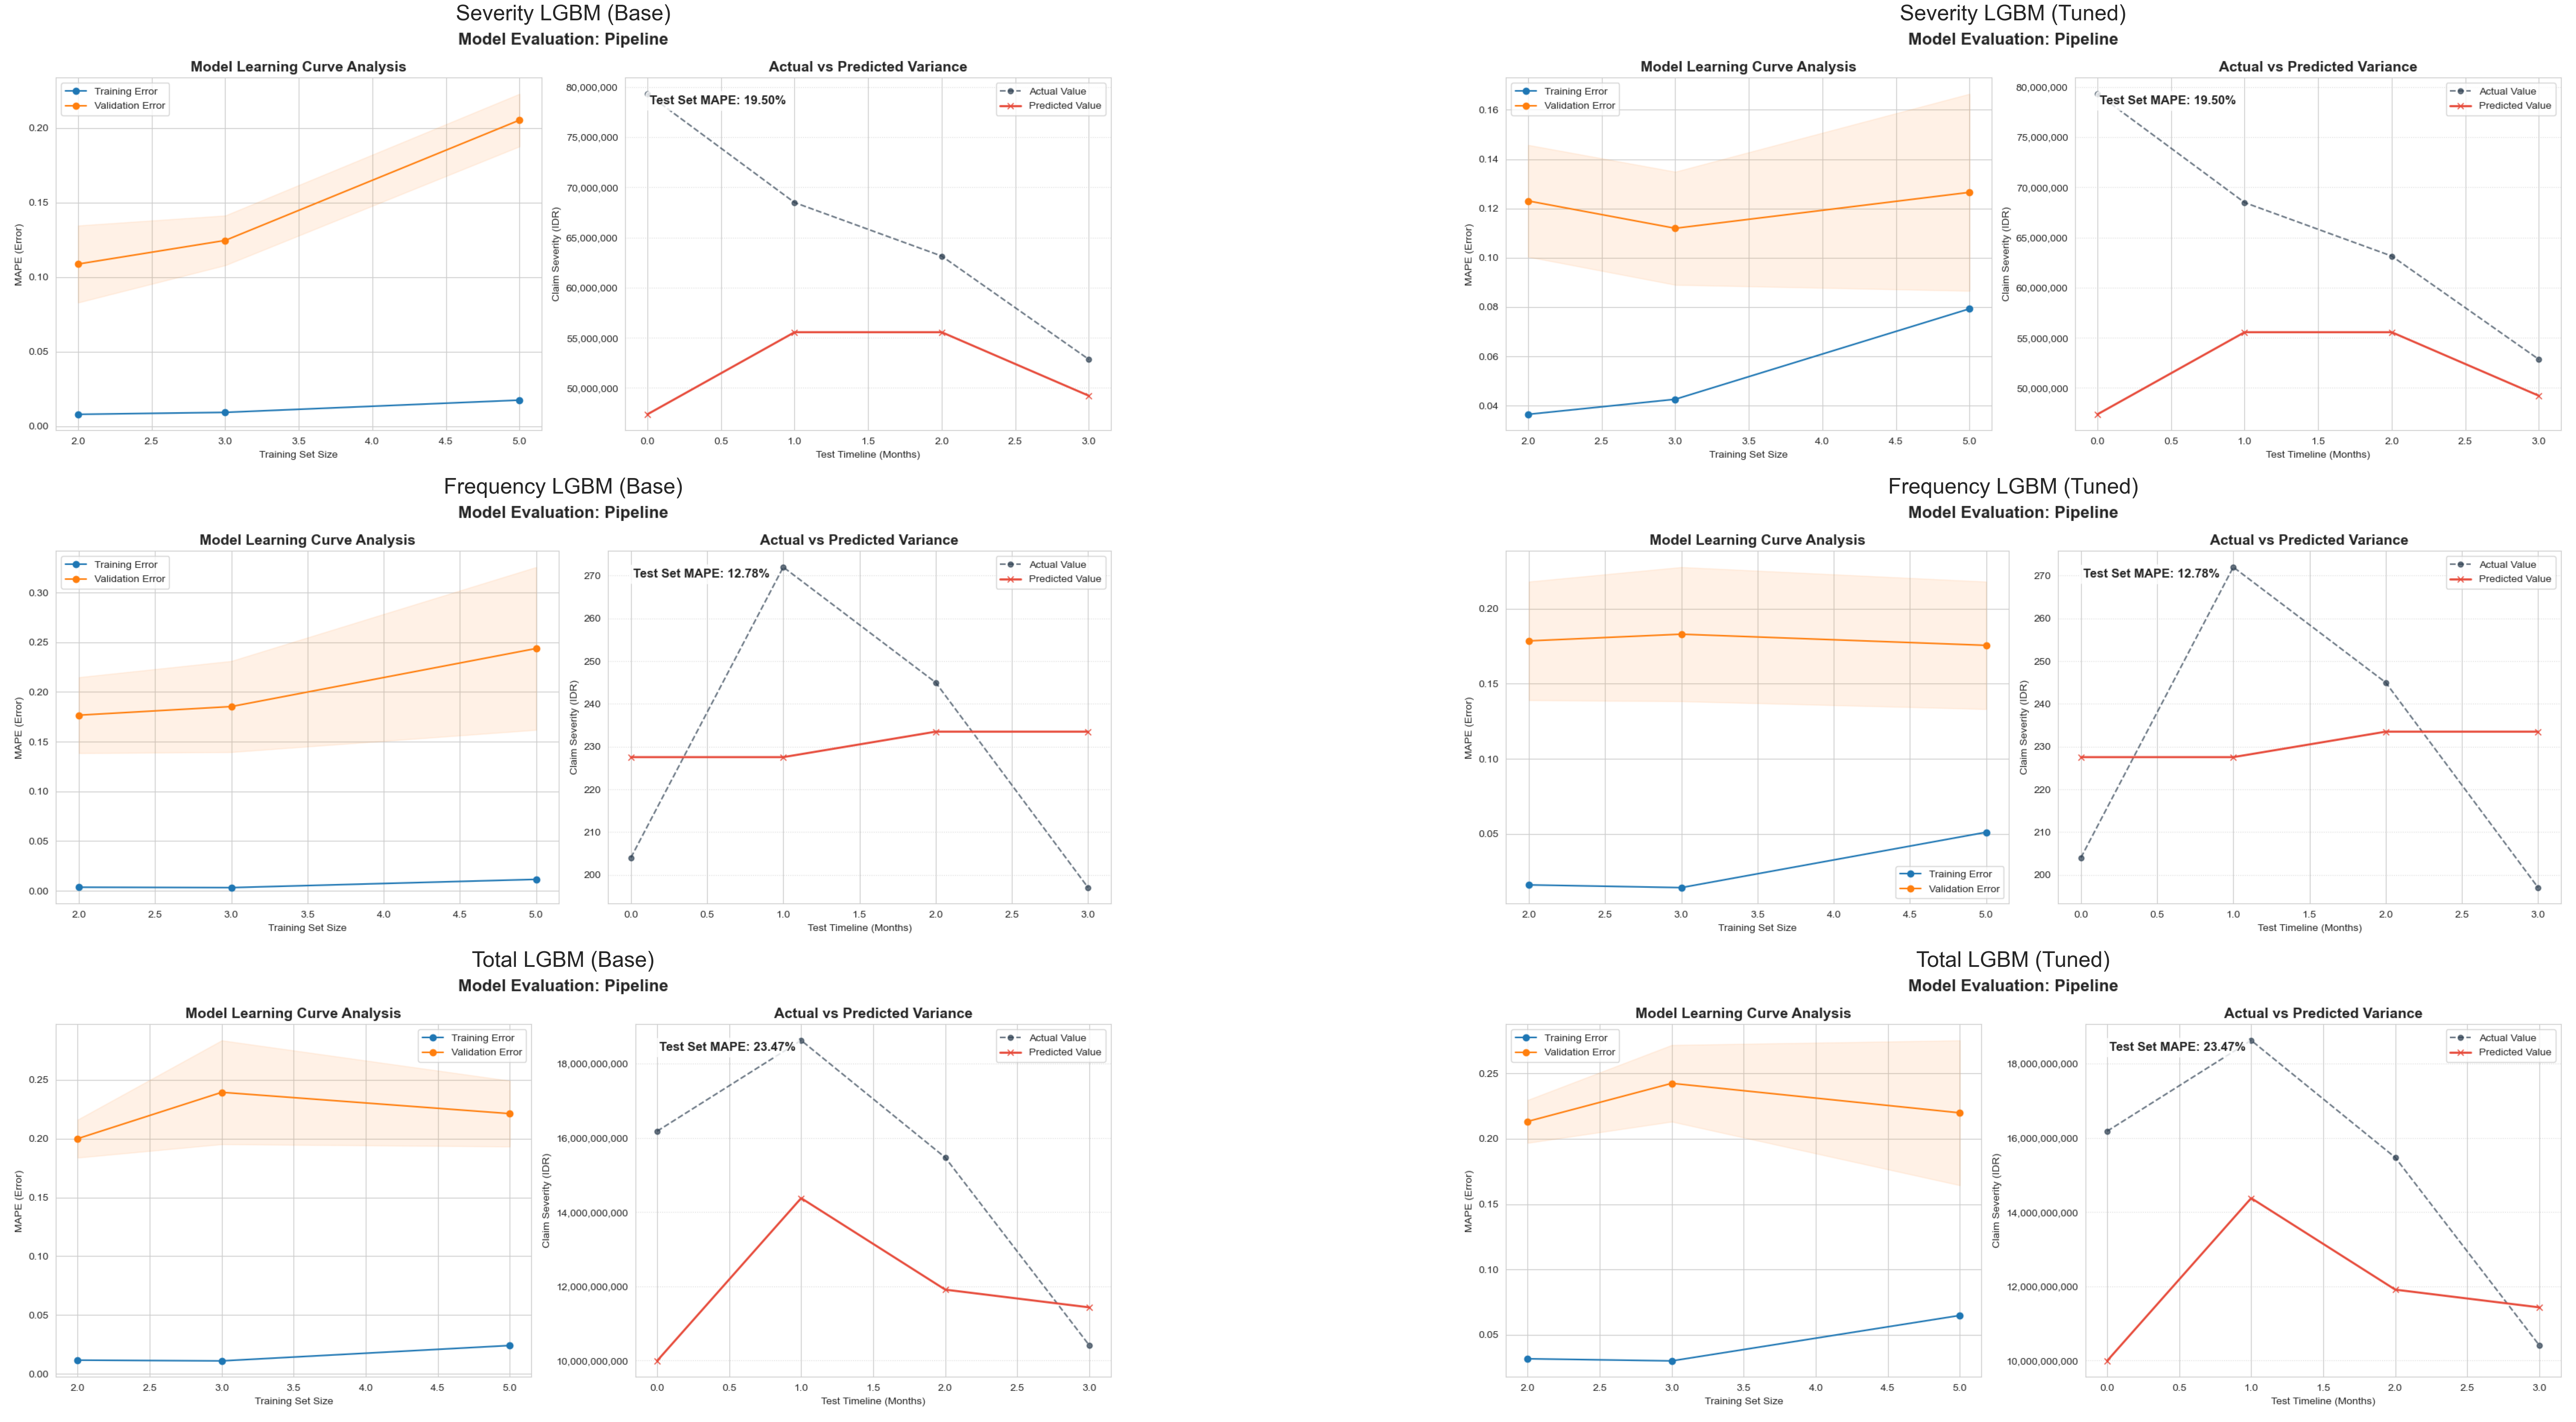

In [102]:
figures = [
    draw_model_sev_lgbm, draw_best_sev_lgbm,
    draw_model_freq_lgbm, draw_best_freq_lgbm,
    draw_model_total_lgbm, draw_best_total_lgbm
]

titles = [
    "Severity LGBM (Base)",
    "Severity LGBM (Tuned)",
    "Frequency LGBM (Base)",
    "Frequency LGBM (Tuned)",
    "Total LGBM (Base)",
    "Total LGBM (Tuned)"
]

fig, axes = plt.subplots(3, 2, figsize=(75,33))
axes = axes.flatten()

for ax, f, title in zip(axes, figures, titles):
    plt.ioff()
    f.canvas.draw()
    img = np.asarray(f.canvas.buffer_rgba())
    ax.imshow(img)
    ax.set_title(title, fontsize=36)
    ax.axis('off')

    plt.close(f)

plt.ion()
plt.tight_layout()
plt.show()

#Hover ke gambar plot lalu tekan Download Image untuk inspect detailnya

##### B.4.5 Summary

In [103]:
summary_lgbm = pd.DataFrame({
    "LGBM_MAPE_Severity_%": [best_mape_sev_lgbm],
    "LGBM_MAPE_Frekuensi_%": [best_mape_freq_lgbm],
    "LGBM_MAPE_Total_Manual_%": [mape_total_best_lgbm],
    "LGBM_MAPE_Total_Model_%": [tuned_total_score_lgbm],
    "LGBM_SKOR_AKHIR_%": [(best_mape_sev_lgbm + best_mape_freq_lgbm + tuned_total_score_lgbm) / 3]
})

display(summary_lgbm)

,LGBM_MAPE_Severity_%,LGBM_MAPE_Frekuensi_%,LGBM_MAPE_Total_Manual_%,LGBM_MAPE_Total_Model_%,LGBM_SKOR_AKHIR_%
0,12.410856,18.378147,23.011905,20.400235,17.063079


#### **B.5 CatBoost**

catboost pada dataset asuransi bekerja dengan baik akibat metode handling missing value yang efektif, kemampuan menangani fitur kategorikal tanpa perlu encoding manual, serta regularisasi yang membantu mencegah overfitting pada data yang kompleks.

Kelebihan CatBoost:
- Handling Missing Value: CatBoost secara otomatis menangani nilai yang hilang, sehingga tidak perlu melakukan imputasi manual.
- Fitur Kategorikal: CatBoost dapat langsung menangani fitur kategorikal tanpa perlu encoding
- Regularisasi: CatBoost memiliki mekanisme regularisasi yang membantu mencegah overfitting, terutama pada dataset yang kompleks.
- Kecepatan: CatBoost dirancang untuk efisiensi, sehingga dapat melatih model dengan cepat bahkan pada dataset besar.
- Akurasi: CatBoost sering kali memberikan hasil yang sangat baik pada berbagai jenis data, termasuk data asuransi yang memiliki banyak fitur dan interaksi kompleks.

Kekurangan CatBoost:
- Kurva Pembelajaran: CatBoost memiliki banyak hyperparameter yang dapat mempengaruhi kinerja model, sehingga memerlukan pemahaman yang baik untuk tuning yang efektif.
- Sumber Daya: Meskipun efisien, CatBoost masih dapat memerlukan sumber daya komputasi yang signifikan, terutama pada dataset yang sangat besar atau dengan banyak fitur.


##### B.5.1 Severity

In [104]:
cat_sev_model = CatBoostRegressor(random_state = 42,
                                  iterations = 500,
                                  learning_rate = 0.05,
                                  verbose = 0,
                                  allow_writing_files = False)

features_sev = features_sev.copy()
target = "claim_severity"
X_sev_train, X_sev_test, y_sev_train, y_sev_test = change_target(df_ts, target, features_sev)
ts_preprocessor = update_preprocessor(features_sev)

In [105]:
model_trend_sev_cat = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', TransformedTargetRegressor(
      regressor=cat_sev_model,
      func=np.log1p,
      inverse_func=np.expm1)
    )
])

model_trend_sev_cat.fit(X_sev_train, y_sev_train)

y_sev_pred_cat = model_trend_sev_cat.predict(X_sev_test)
untuned_sev_score_cat = check_cross_val(model_trend_sev_cat, X_sev_train, X_sev_test, y_sev_train, y_sev_test, y_sev_pred_cat)
print(untuned_sev_score_cat)

--------------- SUMMARY ---------------
CV MAPE: 17.780600895269906
RMSE Severity: 242499836917945.7188
MAE Severity : 11471677.2215
R2 Severity  : -1.6631
--------------- SUMMARY ---------------
MAPE:
17.780600895269906


In [106]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_sev_cat = {
    'regressor__regressor__iterations': [100, 300, 500],
    'regressor__regressor__depth': [3, 4, 6],
    'regressor__regressor__learning_rate': [0.01, 0.03, 0.05],
    'regressor__regressor__l2_leaf_reg': [1, 3, 5, 7],
    'regressor__regressor__random_strength': [1, 2]
}

grid_search_sev_cat = GridSearchCV(
    estimator=model_trend_sev_cat,
    param_grid=param_grid_sev_cat,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 1
)

grid_search_sev_cat.fit(X_sev_train, y_sev_train)

tuned_model_sev_cat = grid_search_sev_cat.best_estimator_
print(f"Best Parameters: {grid_search_sev_cat.best_params_}")

tuned_sev_score_cat = -grid_search_sev_cat.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_sev_cat.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'regressor__regressor__depth': 3, 'regressor__regressor__iterations': 100, 'regressor__regressor__l2_leaf_reg': 7, 'regressor__regressor__learning_rate': 0.01, 'regressor__regressor__random_strength': 1}
Best CV Score (MAPE): 12.2179%


##### B.5.2 Frequency

In [107]:
cat_freq_model = CatBoostRegressor(random_state = 42,
                                  iterations = 500,
                                  learning_rate = 0.05,
                                  verbose = 0,
                                  allow_writing_files = False)

features_freq = features_freq.copy()
target = "claim_frequency"
X_freq_train, X_freq_test, y_freq_train, y_freq_test = change_target(df_ts, target, features_freq)
ts_preprocessor = update_preprocessor(features_freq)

In [108]:
model_trend_freq_cat = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', TransformedTargetRegressor(
      regressor=cat_freq_model,
      func=np.log1p,
      inverse_func=np.expm1)
    )
])

model_trend_freq_cat.fit(X_freq_train, y_freq_train)

y_freq_pred_cat = model_trend_freq_cat.predict(X_freq_test)
untuned_freq_score_cat = check_cross_val(model_trend_freq_cat, X_freq_train, X_freq_test, y_freq_train, y_freq_test, y_freq_pred_cat)
print(untuned_freq_score_cat)

--------------- SUMMARY ---------------
CV MAPE: 16.683601057505058
RMSE Severity: 1328.0286
MAE Severity : 30.6173
R2 Severity  : -0.4154
--------------- SUMMARY ---------------
MAPE:
16.683601057505058


In [109]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_freq_cat = {
    'regressor__regressor__iterations': [100, 300, 500],
    'regressor__regressor__depth': [3, 4, 6],
    'regressor__regressor__learning_rate': [0.01, 0.03, 0.05],
    'regressor__regressor__l2_leaf_reg': [1, 3, 5, 7],
    'regressor__regressor__random_strength': [1, 2]
}

grid_search_freq_cat = GridSearchCV(
    estimator=model_trend_freq_cat,
    param_grid=param_grid_freq_cat,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 1
)

grid_search_freq_cat.fit(X_freq_train, y_freq_train)

tuned_model_freq_cat = grid_search_freq_cat.best_estimator_
print(f"Best Parameters: {grid_search_freq_cat.best_params_}")

tuned_freq_score_cat = -grid_search_freq_cat.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_freq_cat.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'regressor__regressor__depth': 3, 'regressor__regressor__iterations': 300, 'regressor__regressor__l2_leaf_reg': 7, 'regressor__regressor__learning_rate': 0.03, 'regressor__regressor__random_strength': 2}
Best CV Score (MAPE): 14.1458%


##### B.5.3 Total Klaim

In [110]:
cat_total_model = CatBoostRegressor(random_state = 42,
                                  iterations = 500,
                                  learning_rate = 0.05,
                                  verbose = 0,
                                  allow_writing_files = False)

features_total = features_all.copy()
target = "total_claim"
X_total_train, X_total_test, y_total_train, y_total_test = change_target(df_ts, target, features_total)
ts_preprocessor = update_preprocessor(features_total)

In [111]:
model_trend_total_cat = Pipeline(steps=[
    ('preprocessor', ts_preprocessor),
    ('regressor', TransformedTargetRegressor(
      regressor=cat_total_model,
      func=np.log1p,
      inverse_func=np.expm1)
    )
])

model_trend_total_cat.fit(X_total_train, y_total_train)

y_total_pred_cat = model_trend_total_cat.predict(X_total_test)
untuned_total_score_cat = check_cross_val(model_trend_total_cat, X_total_train, X_total_test, y_total_train, y_total_test, y_total_pred_cat)
print(untuned_total_score_cat)

--------------- SUMMARY ---------------
CV MAPE: 23.254119640498537
RMSE Severity: 20253941825537335296.0000
MAE Severity : 4062473609.8369
R2 Severity  : -1.2704
--------------- SUMMARY ---------------
MAPE:
23.254119640498537


In [112]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_total_cat = {
    'regressor__regressor__iterations': [100, 300, 500],
    'regressor__regressor__depth': [3, 4, 6],
    'regressor__regressor__learning_rate': [0.01, 0.03, 0.05],
    'regressor__regressor__l2_leaf_reg': [1, 3, 5, 7],
    'regressor__regressor__random_strength': [1, 2]
}

grid_search_total_cat = GridSearchCV(
    estimator=model_trend_total_cat,
    param_grid=param_grid_total_cat,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 1
)

grid_search_total_cat.fit(X_total_train, y_total_train)

tuned_model_total_cat = grid_search_total_cat.best_estimator_
print(f"Best Parameters: {grid_search_total_cat.best_params_}")

tuned_total_score_cat = -grid_search_total_cat.best_score_ * 100
print(f"Best CV Score (MAPE): {-grid_search_total_cat.best_score_ * 100:.4f}%")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'regressor__regressor__depth': 3, 'regressor__regressor__iterations': 300, 'regressor__regressor__l2_leaf_reg': 7, 'regressor__regressor__learning_rate': 0.05, 'regressor__regressor__random_strength': 1}
Best CV Score (MAPE): 20.2370%


##### B.5.4 Seleksi Model Terbaik

In [113]:
#Severity
if untuned_sev_score_cat < tuned_sev_score_cat:
    best_model_sev_cat = model_trend_sev_cat
    y_sev_pred_cat = model_trend_sev_cat.predict(X_sev_test)
    best_mape_sev_cat = untuned_sev_score_cat
    print(f"Seleksi Model Severity: Menggunakan model Untuned, MAPE: {untuned_sev_score_cat}")
else:
    best_model_sev_cat = tuned_model_sev_cat
    y_sev_pred_cat = tuned_model_sev_cat.predict(X_sev_test)
    best_mape_sev_cat = tuned_sev_score_cat
    print(f"Seleksi Model Severity: Menggunakan model Tuned, MAPE: {-grid_search_sev_cat.best_score_ * 100:.4f}")

#Frekuensi
if untuned_freq_score_cat < tuned_freq_score_cat:
    best_model_freq_cat = model_trend_freq_cat
    y_freq_pred_cat = model_trend_freq_cat.predict(X_freq_test)
    best_mape_freq_cat = untuned_freq_score_cat
    print(f"Seleksi Model Frekuensi: Menggunakan model Untuned, MAPE: {untuned_freq_score_cat:.4f}")
else:
    best_model_freq_cat = tuned_model_freq_cat
    y_freq_pred_cat = tuned_model_freq_cat.predict(X_freq_test)
    best_mape_freq_cat = tuned_freq_score_cat
    print(f"Seleksi Model Frekuensi: Menggunakan model Tuned, MAPE: {-grid_search_freq_cat.best_score_ * 100:.4f}")

#Total
if untuned_total_score_cat < tuned_total_score_cat:
    best_model_total_cat = model_trend_total_cat
    y_total_pred_cat = model_trend_total_cat.predict(X_total_test)
    best_mape_total_cat = untuned_total_score_cat
    print(f"Seleksi Model Total: Menggunakan model Untuned, MAPE: {untuned_total_score_cat:.4f}")
else:
    best_model_total_cat = tuned_model_total_cat
    y_total_pred_cat = tuned_model_total_cat.predict(X_total_test)
    best_mape_total_cat = tuned_total_score_cat
    print(f"Seleksi Model Total: Menggunakan model Tuned, MAPE: {-grid_search_total_cat.best_score_ * 100:.4f}")

Seleksi Model Severity: Menggunakan model Tuned, MAPE: 12.2179
Seleksi Model Frekuensi: Menggunakan model Tuned, MAPE: 14.1458
Seleksi Model Total: Menggunakan model Tuned, MAPE: 20.2370


In [114]:
total_claim_pred_best = y_sev_pred_cat * y_freq_pred_cat
total_claim_actual = y_sev_test * y_freq_test

mape_total_best_cat = mape_score(total_claim_actual, total_claim_pred_best)
print(f"MAPE Total Klaim: {mape_total_best_cat:.4f}")

MAPE Total Klaim: 26.8680


In [115]:
plt.ioff()
draw_model_sev_cat, ax = draw_model_evaluation(model_trend_sev_cat, X_sev_train, y_sev_train, X_sev_test, y_sev_test, y_sev_pred_cat)
draw_best_sev_cat, ax = draw_model_evaluation(best_model_sev_cat, X_sev_train, y_sev_train, X_sev_test, y_sev_test, y_sev_pred_cat)
draw_model_freq_cat, ax = draw_model_evaluation(model_trend_freq_cat, X_freq_train, y_freq_train, X_freq_test, y_freq_test, y_freq_pred_cat)
draw_best_freq_cat, ax = draw_model_evaluation(best_model_freq_cat, X_freq_train, y_freq_train, X_freq_test, y_freq_test, y_freq_pred_cat)
draw_model_total_cat, ax = draw_model_evaluation(model_trend_total_cat, X_total_train, y_total_train, X_total_test, y_total_test, y_total_pred_cat)
draw_best_total_cat, ax = draw_model_evaluation(best_model_total_cat, X_total_train, y_total_train, X_total_test, y_total_test, y_total_pred_cat)
plt.ion()

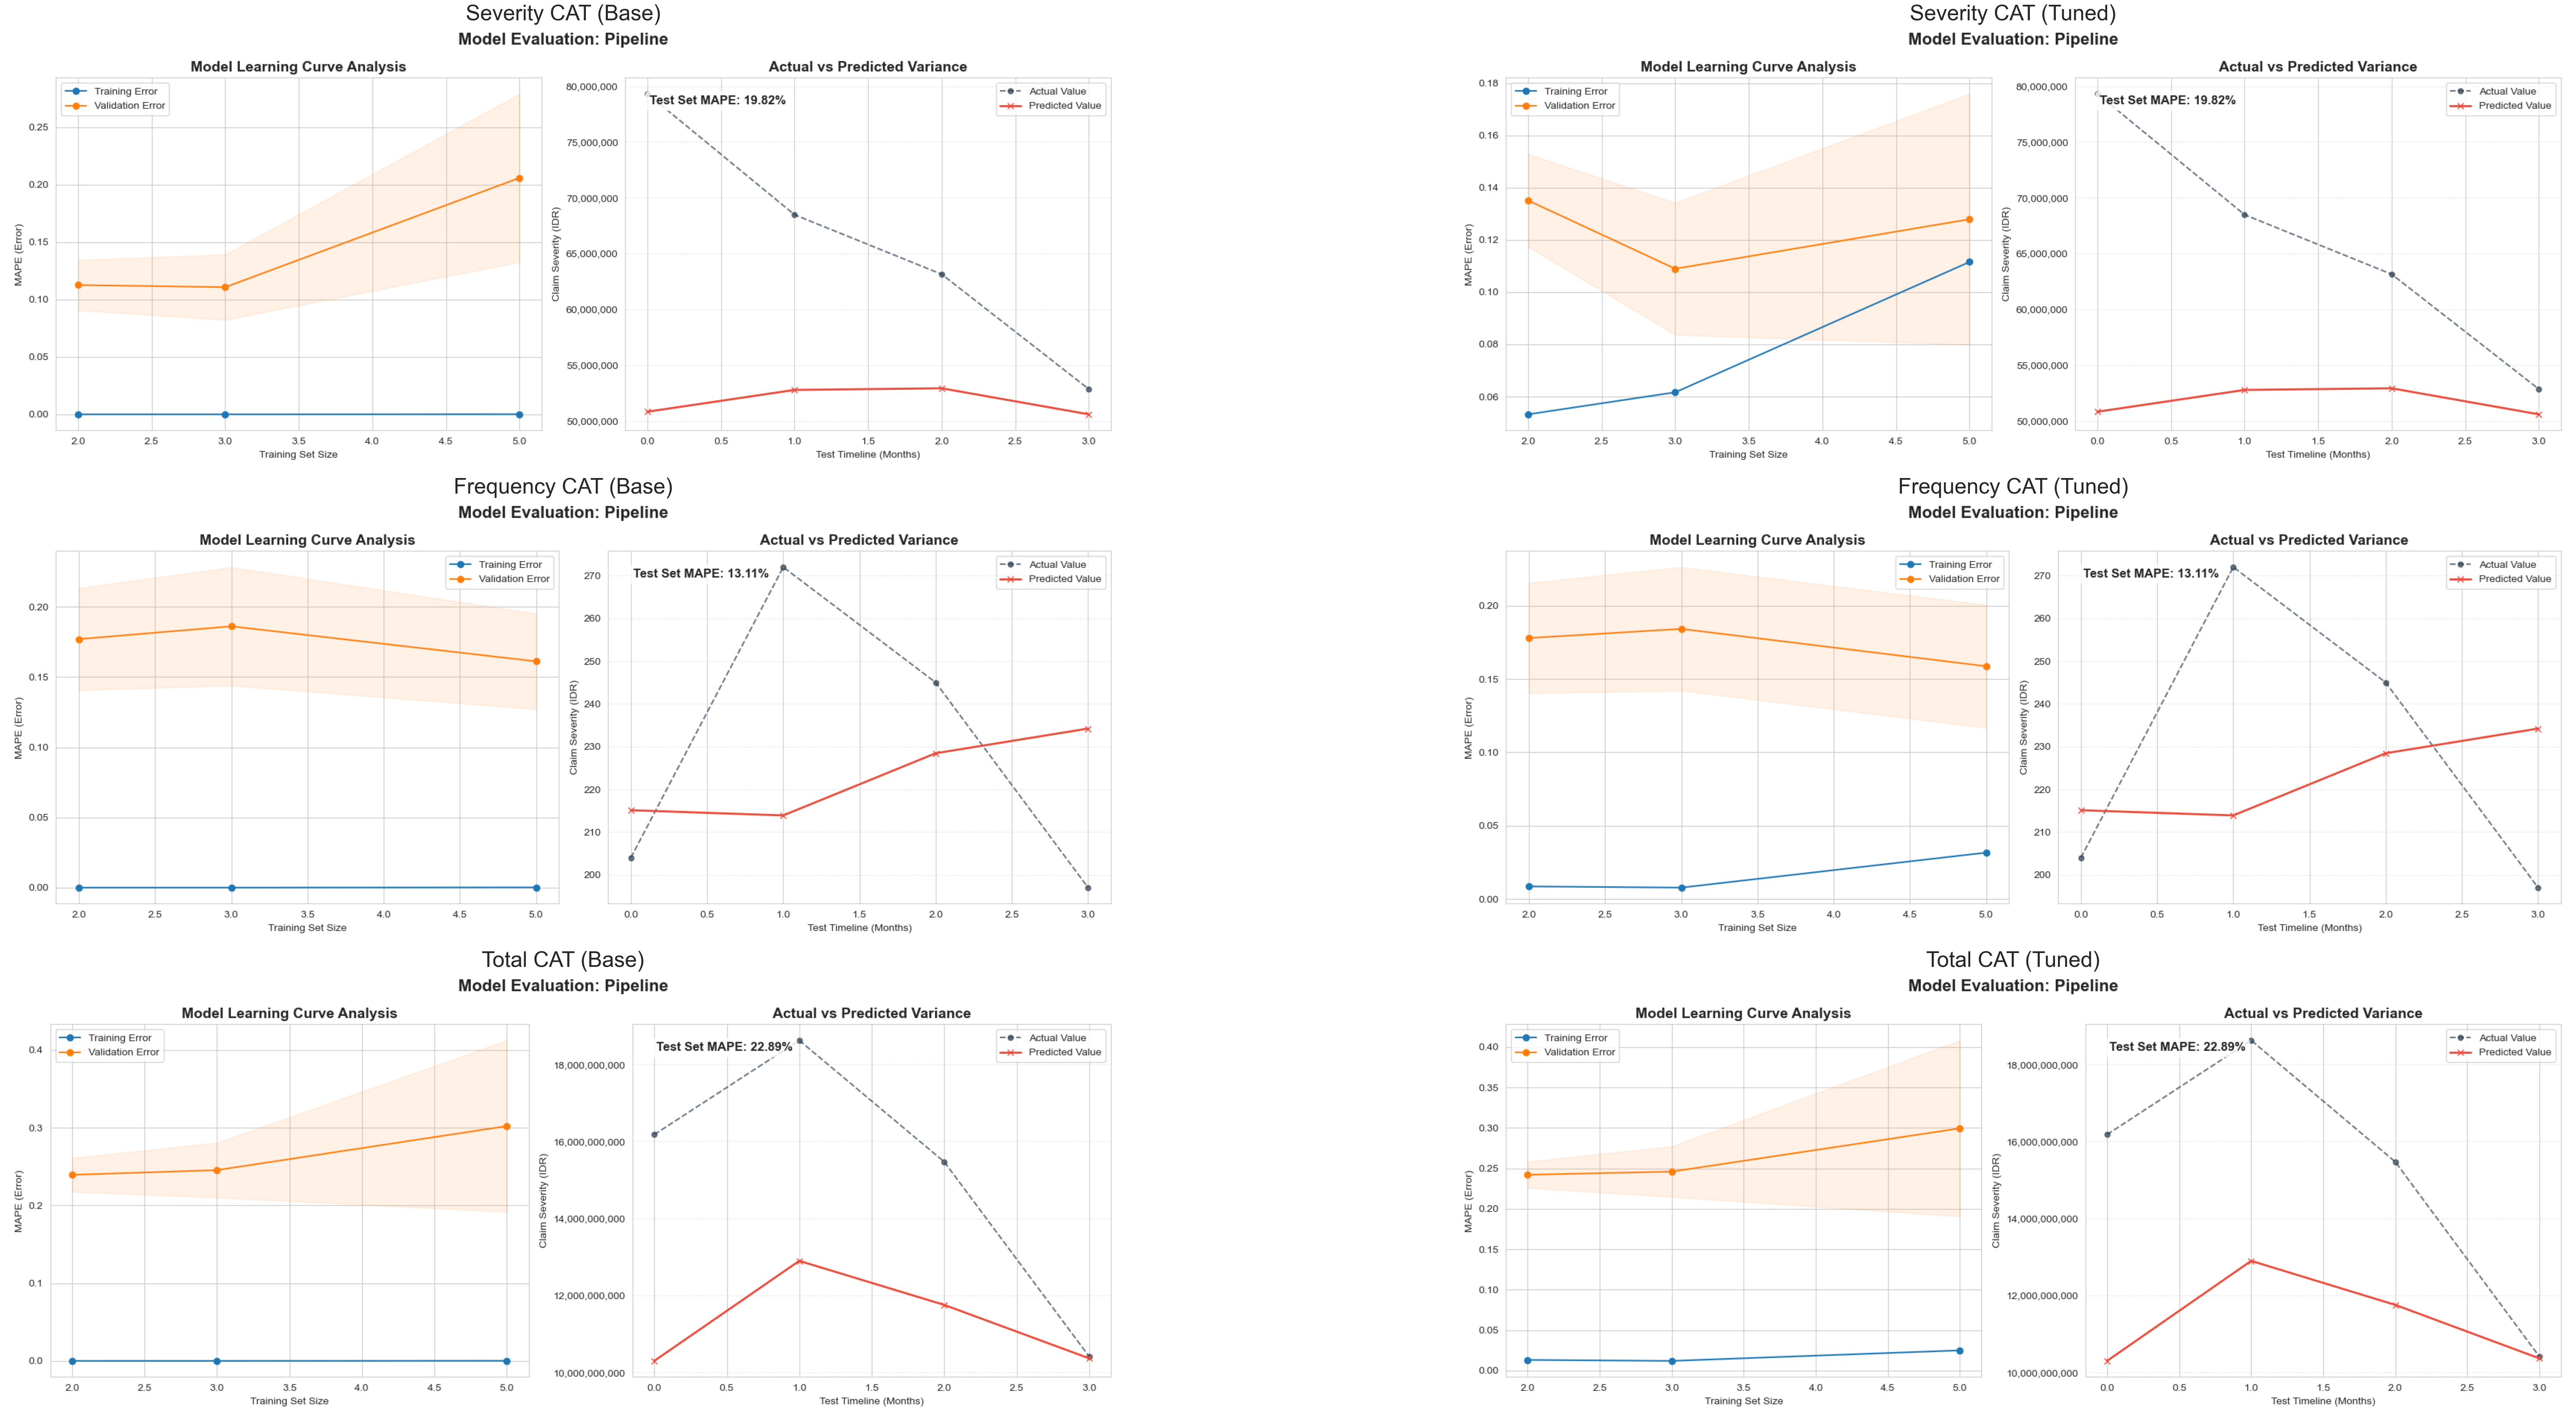

In [116]:
figures = [
    draw_model_sev_cat, draw_best_sev_cat,
    draw_model_freq_cat, draw_best_freq_cat,
    draw_model_total_cat, draw_best_total_cat
]

titles = [
    "Severity CAT (Base)",
    "Severity CAT (Tuned)",
    "Frequency CAT (Base)",
    "Frequency CAT (Tuned)",
    "Total CAT (Base)",
    "Total CAT (Tuned)"
]

fig, axes = plt.subplots(3, 2, figsize=(75,33))
axes = axes.flatten()

for ax, f, title in zip(axes, figures, titles):
    plt.ioff()
    f.canvas.draw()
    img = np.asarray(f.canvas.buffer_rgba())
    ax.imshow(img)
    ax.set_title(title, fontsize=36)
    ax.axis('off')

    plt.close(f)

plt.ion()
plt.tight_layout()
plt.show()

#Hover ke gambar plot lalu tekan Download Image untuk inspect detailnya

##### B.5.5 Summary

In [117]:
summary_cat = pd.DataFrame({
    "CAT_MAPE_Severity_%": [best_mape_sev_cat],
    "CAT_MAPE_Frekuensi_%": [best_mape_freq_cat],
    "CAT_MAPE_Total_Manual_%": [mape_total_best_cat],
    "CAT_MAPE_Total_Model_%": [best_mape_total_cat],
    "CAT_SKOR_AKHIR_%": [(best_mape_sev_cat + best_mape_freq_cat + best_mape_total_cat) / 3] 
})

display(summary_cat)

,CAT_MAPE_Severity_%,CAT_MAPE_Frekuensi_%,CAT_MAPE_Total_Manual_%,CAT_MAPE_Total_Model_%,CAT_SKOR_AKHIR_%
0,12.217877,14.145801,26.867987,20.236966,15.533548


#### **B.6 Summary Seluruh Model**

In [118]:
display(summary_rfr, summary_xgb, summary_glm, summary_lgbm, summary_cat)

,RFR_MAPE_Severity_%,RFR_MAPE_Frekuensi_%,RFR_MAPE_Total_Manual_%,RFR_MAPE_Total_Model_%,RFR_SKOR_AKHIR_%
0,11.303492,15.575977,23.840813,22.523312,16.906761


,XGB_MAPE_Severity_%,XGB_MAPE_Frekuensi_%,XGB_MAPE_Total_Manual_%,XGB_MAPE_Total_Model_%,XGB_SKOR_AKHIR_%
0,8.707242,16.46492,23.291301,13.631472,12.934545


,GLM_MAPE_Severity_%,GLM_MAPE_Frekuensi_%,GLM_MAPE_Total_Manual_%,GLM_MAPE_Total_Model_%,GLM_SKOR_AKHIR_%
0,2.22269,12.323688,28.023709,2.179098,14.190029


,LGBM_MAPE_Severity_%,LGBM_MAPE_Frekuensi_%,LGBM_MAPE_Total_Manual_%,LGBM_MAPE_Total_Model_%,LGBM_SKOR_AKHIR_%
0,12.410856,18.378147,23.011905,20.400235,17.063079


,CAT_MAPE_Severity_%,CAT_MAPE_Frekuensi_%,CAT_MAPE_Total_Manual_%,CAT_MAPE_Total_Model_%,CAT_SKOR_AKHIR_%
0,12.217877,14.145801,26.867987,20.236966,15.533548


#### **B.7 Kaggle Submission**

##### **B.7.1 Setup**

In [119]:
months = ["2025-08", "2025-09", "2025-10", "2025-11", "2025-12"]
display(df_ts[["claim_frequency", "claim_severity", "total_claim"]].describe())

,claim_frequency,claim_severity,total_claim
count,18.000000,1.800000e+01,1.800000e+01
mean,240.555556,5.505733e+07,1.327573e+10
std,47.100921,1.019719e+07,3.525652e+09
min,183.000000,4.097252e+07,7.538943e+09
25%,204.250000,4.770987e+07,1.056766e+10
50%,233.500000,5.254225e+07,1.284837e+10
75%,266.500000,6.219646e+07,1.600048e+10
max,365.000000,7.930225e+07,1.895989e+10


##### **B.7.2 Forecast Recursive**

In [120]:
# Forecast Recursive 
freq_min = max(0, df_ts["claim_frequency"].min() * 0.8)
# freq_min = 0 #debug sifat alami model frekuensi yang terlalu konservatif
freq_max = df_ts["claim_frequency"].max() * 1.2

sev_min = max(0, df_ts["claim_severity"].min() * 0.8)
# sev_min = 0 #debug sifat alami model severity yang terlalu konservatif
sev_max = df_ts["claim_severity"].max() * 1.2

print("[📄]Batas Toleransi Prediksi Frekuensi: ", freq_min, "sampai", freq_max)
print("[📄]Batas Toleransi Prediksi Keparahan: ", sev_min, "sampai", sev_max, "\n")

start_date = df_ts["month_year"].max() #Conversion ke timestamp jika masih Period
if isinstance(start_date, pd.Period):
    start_date = start_date.to_timestamp()

freq_preds = []
sev_preds = []
total_preds = []

df_kaggle = df_ts.copy()
warning_explode_count = 0
warning_TooConservative_count = 0

for m in months:

    m = pd.to_datetime(m)
    month_num = m.month
    last_row = df_kaggle.iloc[-1]

   #Fitur untuk model frekuensi
    freq_row = {
        "freq_lag1": np.clip(last_row["claim_frequency"], freq_min, freq_max),
        "freq_lag3": np.clip(df_kaggle["claim_frequency"].iloc[-3], freq_min, freq_max),
        "month_num": month_num,
        "trend": last_row["trend"] + 1,
        "month_sin": np.sin(2*np.pi*month_num/12),
        "month_cos": np.cos(2*np.pi*month_num/12)
    }
    X_freq = pd.DataFrame([freq_row])
    X_freq = X_freq[features_freq]

    #Frekuensi model selection    
    raw_freq = best_model_freq_rfr.predict(X_freq)[0] #Non-GLM

    # smoothing + safety guard
    freq_pred = 0.6 * raw_freq + 0.4 * last_row["claim_frequency"]
    if not np.isfinite(freq_pred):
        freq_pred = last_row["claim_frequency"]

    freq_pred = np.clip(freq_pred, freq_min, freq_max )

    #Fitur untuk model severity
    sev_row = {
        "lag_1": np.clip(last_row["claim_severity"], sev_min, sev_max),
        "lag_3": np.clip(df_kaggle["claim_severity"].iloc[-3], sev_min, sev_max),
        "rolling_mean_2": df_kaggle["claim_severity"].tail(2).mean(),
        "rolling_mean_3": df_kaggle["claim_severity"].tail(3).mean(),
        "month_sin": np.sin(2*np.pi*month_num/12),
        "month_cos": np.cos(2*np.pi*month_num/12)
    }
    X_sev = pd.DataFrame([sev_row])
    X_sev = X_sev[features_sev] 

    #Severity Model Selection
    raw_sev = best_model_sev_xgb.predict(X_sev)[0]

    # Smoothing + Safety Guard
    sev_pred = 0.6 * raw_sev + 0.4 * last_row["claim_severity"]
    if not np.isfinite(sev_pred):
        sev_pred = last_row["claim_severity"]

    sev_pred = np.clip(sev_pred, sev_min, sev_max)

    #Total Klaim Prediksi
    total_claim_preds = sev_pred * freq_pred

    total_pred = 0.6 * raw_sev + 0.4 * last_row["total_claim"]
    if not np.isfinite(total_pred):
        total_pred = last_row["total_claim"]


    #Save Predictions & Update Dataframe
    freq_preds.append(freq_pred)
    sev_preds.append(sev_pred)
    total_preds.append(total_claim_preds)

    new_row = {
        "month_year": m,
        "claim_frequency": freq_pred,
        "claim_severity": sev_pred,
        "total_claim": total_claim_preds,
        "trend": last_row["trend"] + 1
    }

    df_kaggle = pd.concat([df_kaggle, pd.DataFrame([new_row])], ignore_index=True) #Update dataframe dengan prediksi baru
    
    warning_msg = ""
    if freq_pred >= freq_max or sev_pred >= sev_max:
        warning_msg = " | [‼️] POTENSI EXPLODE"
        warning_explode_count += 1
    if freq_pred <= freq_min or sev_pred <= sev_min:
        warning_msg = " | [‼️] POTENSI TERLALU KONSERVATIF"
        warning_TooConservative_count += 1
    else:
        warning_msg = " | [✅]Stabil"
    # debug
    print(f"Month: {m.strftime('%Y-%m')} | Freq: {freq_pred:.2f} | Sev: {sev_pred:.2f} | Total: {total_claim_preds:.2f} -> {warning_msg}")

print(f"\nTotal bulan dengan potensi explode\t\t: {warning_explode_count} dari {len(months)} bulan.")
print(f"Total bulan dengan potensi terlalu konservatif\t: {warning_TooConservative_count} dari {len(months)} bulan.")

[📄]Batas Toleransi Prediksi Frekuensi:  146.4 sampai 438.0
[📄]Batas Toleransi Prediksi Keparahan:  32778014.841565218 sampai 95162705.35488234 

Month: 2025-08 | Freq: 226.07 | Sev: 50989381.11 | Total: 11527169388.35 ->  | [✅]Stabil
Month: 2025-09 | Freq: 232.72 | Sev: 50246600.45 | Total: 11693288362.46 ->  | [✅]Stabil
Month: 2025-10 | Freq: 231.68 | Sev: 49949488.18 | Total: 11572057663.58 ->  | [✅]Stabil
Month: 2025-11 | Freq: 266.73 | Sev: 54410663.27 | Total: 14512960567.20 ->  | [✅]Stabil
Month: 2025-12 | Freq: 280.10 | Sev: 56679021.31 | Total: 15875682324.20 ->  | [✅]Stabil

Total bulan dengan potensi explode		: 0 dari 5 bulan.
Total bulan dengan potensi terlalu konservatif	: 0 dari 5 bulan.


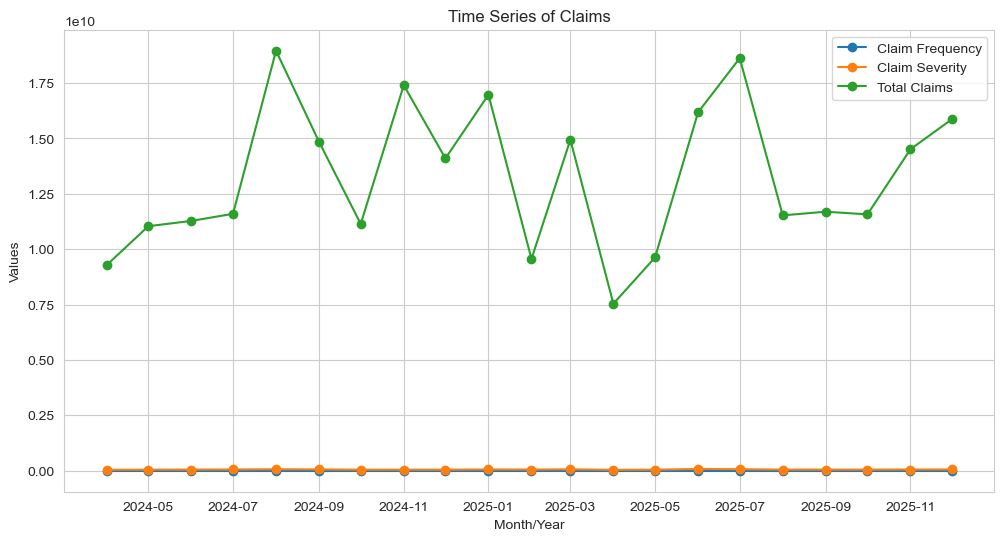

In [121]:
df_kaggle["month_year"] = [x.to_timestamp() if isinstance(x, pd.Period) else pd.to_datetime(x) for x in df_kaggle["month_year"]]
df_kaggle = df_kaggle.drop_duplicates(subset=['month_year'], keep='last')
df_kaggle = df_kaggle.sort_values("month_year").reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(df_kaggle["month_year"], df_kaggle["claim_frequency"], marker='o', label='Claim Frequency')
plt.plot(df_kaggle["month_year"], df_kaggle["claim_severity"], marker='o', label='Claim Severity')
plt.plot(df_kaggle["month_year"], df_kaggle["total_claim"], marker='o', label='Total Claims')
plt.xlabel('Month/Year')
plt.ylabel('Values')
plt.title('Time Series of Claims')
plt.legend()
plt.show()

##### **B.7.3 Output**

In [122]:
forecast_df = pd.DataFrame({
    "month": months,
    "freq": freq_preds,
    "sev": sev_preds
})

forecast_df["total"] = forecast_df["freq"] * forecast_df["sev"]

rows = []

for _, r in forecast_df.iterrows():

    month_str = pd.to_datetime(r.month).strftime("%Y_%m")

    rows.append({"id": f"{month_str}_Claim_Frequency", "value": r.freq})
    rows.append({"id": f"{month_str}_Claim_Severity", "value": r.sev})
    rows.append({"id": f"{month_str}_Total_Claim", "value": r.total})

submission_df = pd.DataFrame(rows)

submission_df.to_csv("submission.csv", index=False)


## **C. Analisa Hasil & Evaluasi Performa Model Machine Learning**

In [123]:
display(summary_rfr, summary_xgb, summary_glm, summary_lgbm, summary_cat)


,RFR_MAPE_Severity_%,RFR_MAPE_Frekuensi_%,RFR_MAPE_Total_Manual_%,RFR_MAPE_Total_Model_%,RFR_SKOR_AKHIR_%
0,11.303492,15.575977,23.840813,22.523312,16.906761


,XGB_MAPE_Severity_%,XGB_MAPE_Frekuensi_%,XGB_MAPE_Total_Manual_%,XGB_MAPE_Total_Model_%,XGB_SKOR_AKHIR_%
0,8.707242,16.46492,23.291301,13.631472,12.934545


,GLM_MAPE_Severity_%,GLM_MAPE_Frekuensi_%,GLM_MAPE_Total_Manual_%,GLM_MAPE_Total_Model_%,GLM_SKOR_AKHIR_%
0,2.22269,12.323688,28.023709,2.179098,14.190029


,LGBM_MAPE_Severity_%,LGBM_MAPE_Frekuensi_%,LGBM_MAPE_Total_Manual_%,LGBM_MAPE_Total_Model_%,LGBM_SKOR_AKHIR_%
0,12.410856,18.378147,23.011905,20.400235,17.063079


,CAT_MAPE_Severity_%,CAT_MAPE_Frekuensi_%,CAT_MAPE_Total_Manual_%,CAT_MAPE_Total_Model_%,CAT_SKOR_AKHIR_%
0,12.217877,14.145801,26.867987,20.236966,15.533548


**Mengapa tidak menggunakan GLM?**

- Di GLM, jika model meleset sedikit saja pada skala log (misalnya harusnya 15 tapi diprediksi 16), saat di-invers menggunakan np.exp(), selisih tersebut akan menjadi jutaan Rupiah. Kombinasi error di severity dan frekuensi berpotensi meledak pada prediksi total. Penggunaan GLM memiliki compounding error yang lebih besar dan juga rentan terhadap output prediksi yang meledak.

- Model pohon (XGB/RFR) seringkali lebih "konservatif" dalam memprediksi nilai ekstrem pada skala log, sehingga saat dikembalikan ke nilai asli, "ledakan" prediksi & error-nya tidak separah GLM.

**Asumsi Distribusi yang Kaku**
- GLM: Memaksa data untuk mengikuti pola Gamma atau Poisson secara sempurna. Jika data klaim asuransi Anda memiliki fat-tail (klaim yang sangat besar namun jarang) yang tidak sesuai dengan kurva Gamma, GLM akan gagal total.

- XGB/RFR: Tidak punya asumsi distribusi. Mereka belajar murni dari pola data yang ada, sehingga lebih fleksibel menangani data yang "berantakan".

#### **C.3.1 Identifikasi Faktor Paling berpengaruh ke**
a). severitas klaim, b). frekuensi klaim, c) nominal klaim

##### **C.3.1.1 Severitas Klaim**

C:\Users\Alvin\AppData\Local\Temp\ipykernel_24524\206609277.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_sev.head(15), x='importance', y='feature', palette='magma')


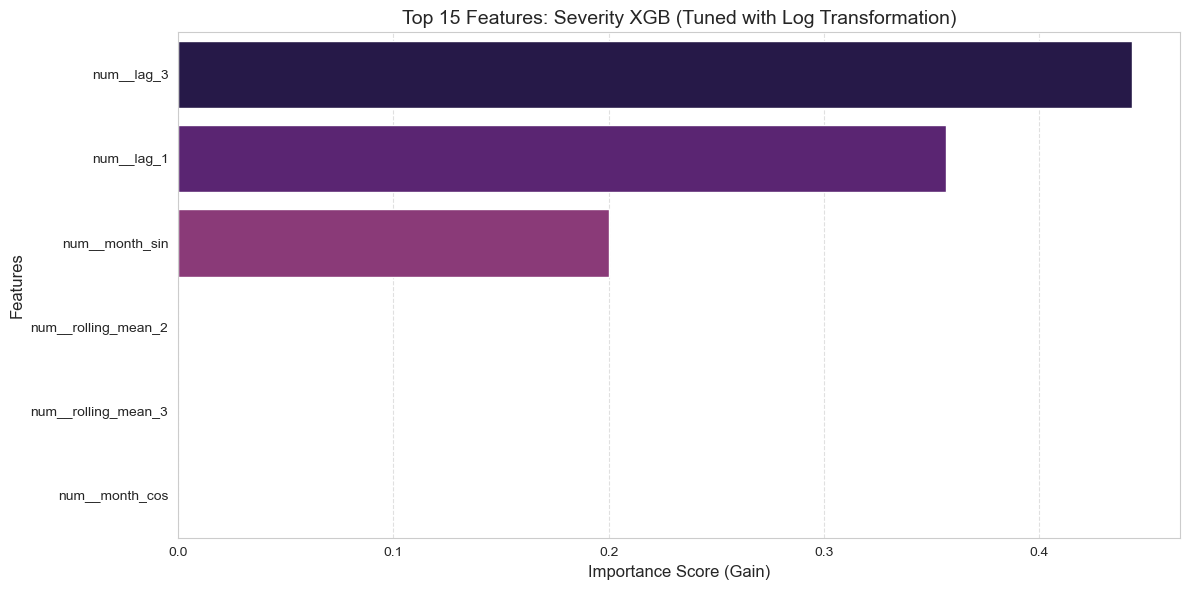

In [124]:
best_pipeline = grid_search_sev_xgb.best_estimator_
final_xgb_model = best_pipeline.named_steps['regressor'].regressor_

try:
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
except ValueError:
    # Jika masih error, masukkan nama kolom original secara manual
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out(X_sev_train.columns)

df_imp_sev = pd.DataFrame({
    'feature': feature_names,
    'importance': final_xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# print(df_imp_sev.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=df_imp_sev.head(15), x='importance', y='feature', palette='magma')

plt.title('Top 15 Features: Severity XGB (Tuned with Log Transformation)', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### **C.3.1.2 Frekuensi Klaim**

C:\Users\Alvin\AppData\Local\Temp\ipykernel_24524\3488592033.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='magma')


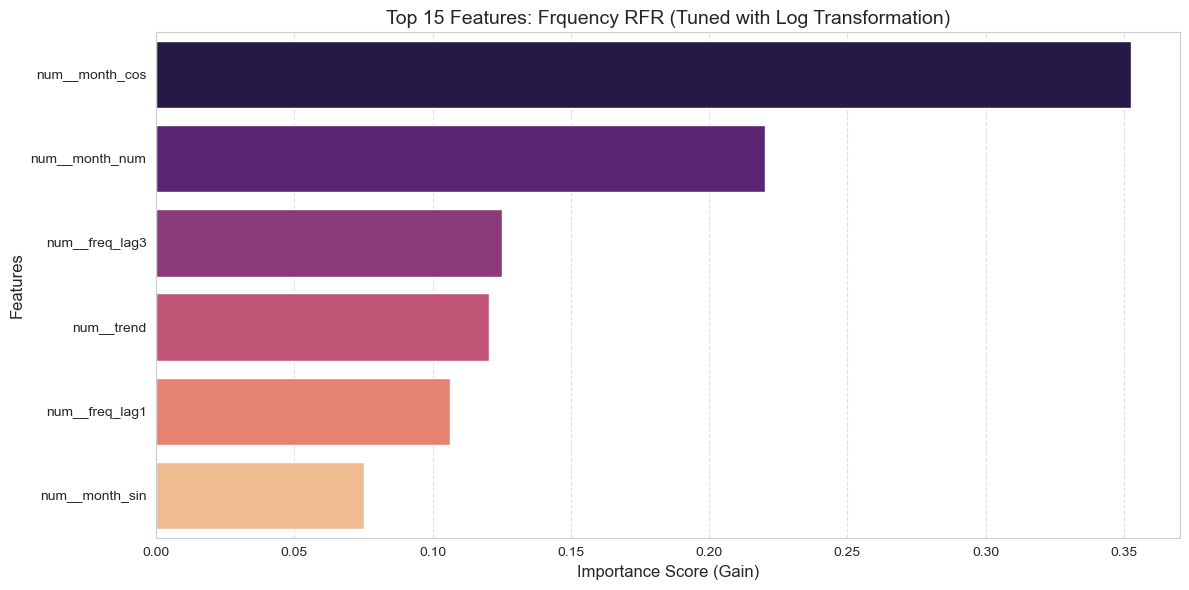

In [125]:
rf = best_model_freq_rfr.named_steps.regressor
importances = rf.feature_importances_
feature_names = best_model_freq_rfr.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.T

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='magma')

plt.title('Top 15 Features: Frquency RFR (Tuned with Log Transformation)', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\Alvin\AppData\Local\Temp\ipykernel_24524\2737503197.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_sev.head(20), x='importance', y='feature', palette='magma')


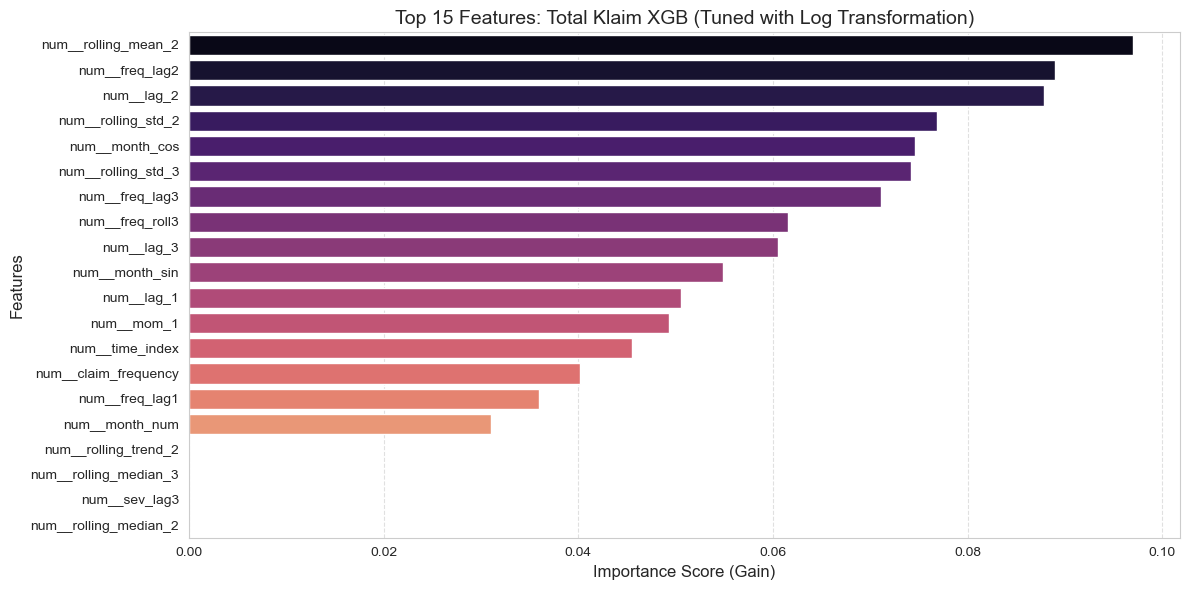

In [126]:
best_pipeline = grid_search_total_xgb.best_estimator_
final_xgb_model = best_pipeline.named_steps['regressor']

try:
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
except ValueError:
    # Jika masih error, masukkan nama kolom original secara manual
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out(X_sev_train.columns)

df_imp_sev = pd.DataFrame({
    'feature': feature_names,
    'importance': final_xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# print(df_imp_sev.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=df_imp_sev.head(20), x='importance', y='feature', palette='magma')

plt.title('Top 15 Features: Total Klaim XGB (Tuned with Log Transformation)', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Note: XGB juga memiliki plot_importance, bukan RFC saja

#### **C.3.2 Perbandingan hasil dengan dan tanpa feature engineering**

In [127]:
#Tanpa Feature Engineering (Minimum Baseline Feature)
features_baseline = ['month_num', 'time_index']
X_base = df_ts[features_baseline]

#Dengan Feature Engineering (All Features)
features_total = features_all.copy()
X_total = df_ts[features_total]

y = df_ts['total_claim']

In [128]:
#Tanpa feature engineering | RFR Freq
X_base_train, X_base_test, y_base_train, y_base_test = change_target(df_ts, "claim_frequency", features_baseline)

model_base = Pipeline(steps=[
    ('preprocessor', update_preprocessor(features_baseline)),
    ('regressor', RandomForestRegressor(random_state = 42, n_jobs = -1))
])

#Model Baseline
model_base.fit(X_base_train, y_base_train)
y_base_freq_pred = model_base.predict(X_base_test)
base_mape = check_cross_val(model_base, X_base_train, X_base_test, y_base_train, y_base_test, y_base_freq_pred)
print(f"Sebelum FE | MAPE Freq: {base_mape:.4f}%\n\n")

#Model dengan FE
X_freq_train, X_freq_test, y_freq_train, y_freq_test = change_target(df_ts, "claim_frequency", features_freq)

model_trend_freq_rfr.fit(X_freq_train, y_freq_train)
y_freq_pred = model_trend_freq_rfr.predict(X_freq_test)
base_mape = check_cross_val(model_trend_freq_rfr, X_freq_train, X_freq_test, y_freq_train, y_freq_test, y_freq_pred)
print(f"Setelah FE | MAPE Freq: {base_mape:.4f}%\n\n")

--------------- SUMMARY ---------------
CV MAPE: 17.329504849446355
RMSE Severity: 1488.8809
MAE Severity : 29.2925
R2 Severity  : -0.5869
--------------- SUMMARY ---------------
MAPE:
Sebelum FE | MAPE Freq: 17.3295%


--------------- SUMMARY ---------------
CV MAPE: 17.53929027791983
RMSE Severity: 1395.7834
MAE Severity : 29.3675
R2 Severity  : -0.4876
--------------- SUMMARY ---------------
MAPE:
Setelah FE | MAPE Freq: 17.5393%




In [129]:
#Tanpa feature engineering | RFR Freq
X_base_train, X_base_test, y_base_train, y_base_test = change_target(df_ts, "claim_severity", features_baseline)

model_base = Pipeline(steps=[
    ('preprocessor', update_preprocessor(features_baseline)),
    ('regressor', XGBRegressor(random_state = 42, n_jobs = -1, verbosity = 0))
])

#Model Baseline
model_base.fit(X_base_train, y_base_train)
y_base_sev_pred = model_base.predict(X_base_test)
base_mape = check_cross_val(model_base, X_base_train, X_base_test, y_base_train, y_base_test, y_base_sev_pred)
print(f"Sebelum FE | MAPE Sev: {base_mape:.4f}%\n\n")

#Model dengan FE
X_sev_train, X_sev_test, y_sev_train, y_sev_test = change_target(df_ts, "claim_severity", features_sev)

model_trend_sev_rfr.fit(X_sev_train, y_sev_train)
y_sev_pred = model_trend_sev_rfr.predict(X_sev_test)
base_mape = check_cross_val(model_trend_sev_rfr, X_sev_train, X_sev_test, y_sev_train, y_sev_test, y_sev_pred)
print(f"Setelah FE | MAPE Sev: {base_mape:.4f}%\n\n")

--------------- SUMMARY ---------------
CV MAPE: 21.710221778775775
RMSE Severity: 249921321689430.5000
MAE Severity : 11762605.2551
R2 Severity  : -1.7446
--------------- SUMMARY ---------------
MAPE:
Sebelum FE | MAPE Sev: 21.7102%


--------------- SUMMARY ---------------
CV MAPE: 12.95430805654366
RMSE Severity: 272391561301030.2188
MAE Severity : 12993700.5412
R2 Severity  : -1.9914
--------------- SUMMARY ---------------
MAPE:
Setelah FE | MAPE Sev: 12.9543%




In [130]:
#Tanpa Feature Engineering (Minimum Baseline Feature)
features_baseline = ['month_num', 'time_index']
X_base = df_ts[features_baseline]

#Dengan Feature Engineering (All Features)
features_total = features_all.copy()
X_total = df_ts[features_total]

y = df_ts['total_claim']

X_base_train, X_base_test, y_base_train, y_base_test = change_target(df_ts, "total_claim", features_baseline)
X_total_train, X_total_test, y_total_train, y_total_test = change_target(df_ts, "total_claim", features_total)

model_base = Pipeline(steps=[
    ('preprocessor', update_preprocessor(features_baseline)),
    ('regressor', XGBRegressor(random_state = 42, n_jobs = -1, verbosity = 0))
])

#Model Baseline
model_base.fit(X_base_train, y_base_train)
y_base_pred = model_base.predict(X_base_test)
base_mape = check_cross_val(model_base, X_base_train, X_base_test, y_base_train, y_base_test, y_base_pred)
print(f"Baseline MAPE: {base_mape:.4f}%\n\n")

#Model dengan Feature Engineering
model_trend_total_xgb.fit(X_total_train, y_total_train)
y_total_pred = model_trend_total_xgb.predict(X_total_test)
total_mape = check_cross_val(model_trend_total_xgb, X_total_train, X_total_test, y_total_train, y_total_test, y_total_pred)
print(f"Model Total Klaim MAPE: {total_mape:.4f}%")

--------------- SUMMARY ---------------
CV MAPE: 28.3935511112845
RMSE Severity: 29076989338153644032.0000
MAE Severity : 4940669425.6050
R2 Severity  : -2.2595
--------------- SUMMARY ---------------
MAPE:
Baseline MAPE: 28.3936%


--------------- SUMMARY ---------------
CV MAPE: 15.567154081597726
RMSE Severity: 20221327432114950144.0000
MAE Severity : 3981125104.5950
R2 Severity  : -1.2668
--------------- SUMMARY ---------------
MAPE:
Model Total Klaim MAPE: 15.5672%


#### **C.3.3 Berikan hasil prediksi klaim di tahun 2026 baik dari segi**
a) severitas klaim,
b) frekuensi klaim, dan
c) nominal klaim

##### **C.3.3.1 Forecast Recursive**

In [131]:
def recursive_forecast(df_ts, best_model_freq_rfr, best_model_sev_xgb, features_freq, features_sev):    
    freq_min = max(0, df_ts["claim_frequency"].min() * 0.8)
    # freq_min = 0 #debug naluri model frekuensi yang terlalu konservatif
    freq_max = df_ts["claim_frequency"].max() * 1.2

    sev_min = max(0, df_ts["claim_severity"].min() * 0.8)
    # sev_min = 0 #debug naluri model severity yang terlalu konservatif
    sev_max = df_ts["claim_severity"].max() * 1.2

    print("[📄]Batas Toleransi Prediksi Frekuensi: ", freq_min, "sampai", freq_max)
    print("[📄]Batas Toleransi Prediksi Keparahan: ", sev_min, "sampai", sev_max, "\n")

    start_date = df_ts["month_year"].max() #Conversion ke timestamp jika masih Period
    if isinstance(start_date, pd.Period):
        start_date = start_date.to_timestamp()

    first_future_month = start_date + pd.DateOffset(months=1)
    future_months = pd.date_range(start=first_future_month, periods=15, freq='MS')

    freq_preds = []
    sev_preds = []
    total_preds = []

    df_recursive = df_ts.copy()
    warning_explode_count = 0
    warning_TooConservative_count = 0

    for m in future_months:

        m = pd.to_datetime(m)
        month_num = m.month
        last_row = df_recursive.iloc[-1]

        #Frequency Features
        freq_row = {
            "freq_lag1": np.clip(last_row["claim_frequency"], freq_min, freq_max),
            "freq_lag3": np.clip(df_recursive["claim_frequency"].iloc[-3], freq_min, freq_max),
            "month_num": month_num,
            "trend": last_row["trend"] + 1,
            "month_sin": np.sin(2*np.pi*month_num/12),
            "month_cos": np.cos(2*np.pi*month_num/12)
        }

        X_freq = pd.DataFrame([freq_row])
        X_freq = X_freq[features_freq]

        #1. Frequency Model Selection
        raw_freq = best_model_freq_rfr.predict(X_freq)[0] 

        # smoothing + safety
        freq_pred = 0.6 * raw_freq + 0.4 * last_row["claim_frequency"]
        if not np.isfinite(freq_pred):
            freq_pred = last_row["claim_frequency"]

        freq_pred = np.clip(freq_pred, freq_min, freq_max )

    
        #Severity Features
        sev_row = {
            "lag_1": np.clip(last_row["claim_severity"], sev_min, sev_max),
            "lag_3": np.clip(df_recursive["claim_severity"].iloc[-3], sev_min, sev_max),
            "rolling_mean_2": df_recursive["claim_severity"].tail(2).mean(),
            "rolling_mean_3": df_recursive["claim_severity"].tail(3).mean(),
            "month_sin": np.sin(2*np.pi*month_num/12),
            "month_cos": np.cos(2*np.pi*month_num/12)
        }

        #Seleksi Fitur
        X_sev = pd.DataFrame([sev_row])
        X_sev = X_sev[features_sev] 

        #2. Severity Model Selection
        raw_sev = best_model_sev_xgb.predict(X_sev)[0]

        # Smoothing + Safety
        sev_pred = 0.6 * raw_sev + 0.4 * last_row["claim_severity"]
        if not np.isfinite(sev_pred):
            sev_pred = last_row["claim_severity"]

        sev_pred = np.clip(sev_pred, sev_min, sev_max)

        #Total Klaim 
        total_claim_pred = freq_pred * sev_pred

        #Save Prediction
        freq_preds.append(freq_pred)
        sev_preds.append(sev_pred)

        #Update recursive dataframe 
        new_row = {
            "month_year": m,
            "claim_frequency": freq_pred,
            "claim_severity": sev_pred,
            "total_claim": total_claim_pred,
            "trend": last_row["trend"] + 1
        }

        df_recursive = pd.concat([df_recursive, pd.DataFrame([new_row])], ignore_index=True)
        warning_msg = ""
        if freq_pred >= freq_max or sev_pred >= sev_max:
            warning_msg = " | [‼️] POTENSI EXPLODE"
            warning_explode_count += 1
        if freq_pred <= freq_min or sev_pred <= sev_min:
            warning_msg = " | [‼️] POTENSI TERLALU KONSERVATIF"
            warning_TooConservative_count += 1
        else:
            warning_msg = " | [✅]Stabil"
        # debug
        print(f"Month: {m.strftime('%Y-%m')} | Freq: {freq_pred:.2f} | Sev: {sev_pred:.2f} | Total: {total_claim_pred:.2f} -> {warning_msg}")

    print(f"\nTotal bulan dengan potensi explode\t\t: {warning_explode_count} dari {len(future_months)} bulan.")
    print(f"Total bulan dengan potensi terlalu konservatif\t: {warning_TooConservative_count} dari {len(future_months)} bulan.")
    return df_recursive 

df_recursive_forecast = recursive_forecast(df_ts, best_model_freq_rfr, best_model_sev_xgb, features_freq, features_sev)

[📄]Batas Toleransi Prediksi Frekuensi:  146.4 sampai 438.0
[📄]Batas Toleransi Prediksi Keparahan:  32778014.841565218 sampai 95162705.35488234 

Month: 2025-10 | Freq: 229.62 | Sev: 50989381.11 | Total: 11707977733.78 ->  | [✅]Stabil
Month: 2025-11 | Freq: 269.79 | Sev: 50246600.45 | Total: 13555949939.61 ->  | [✅]Stabil
Month: 2025-12 | Freq: 272.67 | Sev: 49949488.18 | Total: 13619694973.87 ->  | [✅]Stabil
Month: 2026-01 | Freq: 260.64 | Sev: 54410663.27 | Total: 14181581345.89 ->  | [✅]Stabil
Month: 2026-02 | Freq: 229.19 | Sev: 57499845.31 | Total: 13178613657.65 ->  | [✅]Stabil
Month: 2026-03 | Freq: 215.96 | Sev: 58735518.12 | Total: 12684261651.84 ->  | [✅]Stabil
Month: 2026-04 | Freq: 208.86 | Sev: 51263651.25 | Total: 10706937663.31 ->  | [✅]Stabil
Month: 2026-05 | Freq: 208.23 | Sev: 50356308.50 | Total: 10485698623.09 ->  | [✅]Stabil
Month: 2026-06 | Freq: 206.06 | Sev: 49993371.40 | Total: 10301835872.84 ->  | [✅]Stabil
Month: 2026-07 | Freq: 206.26 | Sev: 54428216.56 | Tot

In [132]:
df_recursive_forecast[["month_year", "total_claim", "claim_frequency", "claim_severity"]].describe()

,total_claim,claim_frequency,claim_severity
count,3.300000e+01,33.000000,3.300000e+01
mean,1.289825e+10,238.009341,5.416137e+07
std,2.740698e+09,38.639827,7.791651e+06
min,7.538943e+09,183.000000,4.097252e+07
25%,1.103847e+10,208.230089,4.999337e+07
50%,1.268426e+10,229.566375,5.223817e+07
75%,1.418158e+10,265.886550,5.758917e+07
max,1.895989e+10,365.000000,7.930225e+07


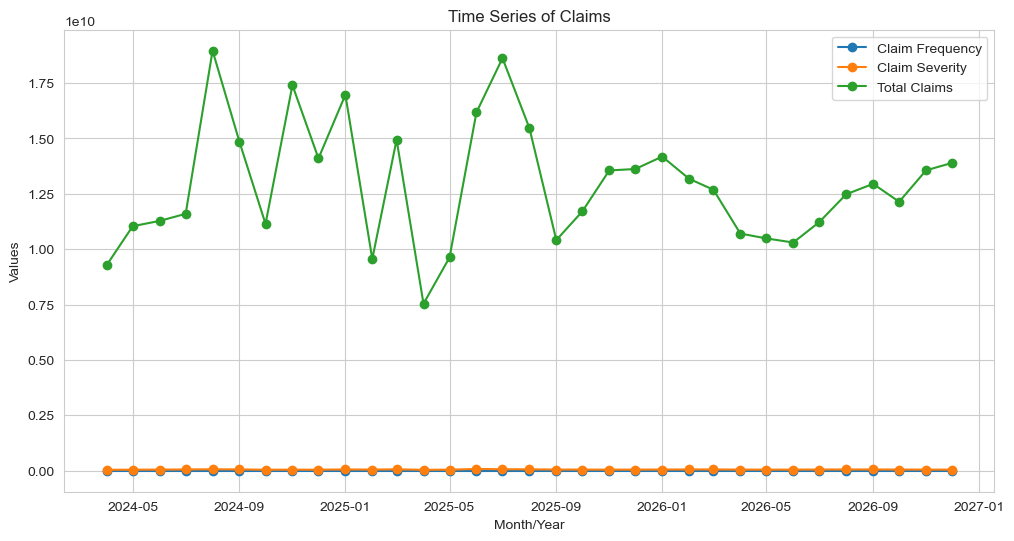

In [133]:
df_recursive_forecast["month_year"] = [x.to_timestamp() if isinstance(x, pd.Period) else pd.to_datetime(x) for x in df_recursive_forecast["month_year"]]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_recursive_forecast["month_year"], df_recursive_forecast["claim_frequency"], marker='o', label='Claim Frequency')
ax.plot(df_recursive_forecast["month_year"], df_recursive_forecast["claim_severity"], marker='o', label='Claim Severity')
ax.plot(df_recursive_forecast["month_year"], df_recursive_forecast["total_claim"], marker='o', label='Total Claims')

ax.set_xlabel('Month/Year')
ax.set_ylabel('Values')
ax.set_title('Time Series of Claims')
ax.legend()

plot_forecast_recursive = fig

In [134]:
df_temp[["month_year", "claim_frequency", "claim_severity", "total_claim"]].describe()

,claim_frequency,claim_severity,total_claim
count,17.000000,1.700000e+01,1.700000e+01
mean,231.411765,5.800851e+07,1.314962e+10
std,65.755284,1.187435e+07,4.032935e+09
min,58.000000,4.097252e+07,4.900102e+09
25%,201.000000,4.790084e+07,1.041073e+10
50%,234.000000,5.657430e+07,1.409901e+10
75%,272.000000,6.385066e+07,1.617766e+10
max,365.000000,8.448453e+07,1.895989e+10


##### **C.3.3.2 Forecast Hybrid**

In [135]:
def hybrid_forecast(df_ts, best_model_freq, best_model_sev, features_freq, features_sev, verbose):
    start_date = df_ts["month_year"].max() #Conversion ke timestamp jika masih Period
    if isinstance(start_date, pd.Period):
        start_date = start_date.to_timestamp()
        
    # 1. Tambahkan horizon 0 pada data latih (karena data asli dianggap horizon 0)
    X_total_train['horizon'] = 0
    X_total_test['horizon'] = 0 

    # 2. Update list fitur, tambahkan horizon
    features_freq_dirrec = features_freq + ['horizon']
    features_sev_dirrec = features_sev + ['horizon']

    # 3. Fit ulang menggunakan fitur + horizon
    model_trend_freq_xgb.fit(X_total_train[features_freq_dirrec], y_freq_train)
    model_trend_sev_rfr.fit(X_total_train[features_sev_dirrec], y_sev_train)\

    # 4. Tambahkan fitur 'horizon' ke data training 
    X_total_train['horizon'] = 0
    X_total_test['horizon'] = 1 #Penanda data pertama


    freq_preds, sev_preds, total_preds = [], [], []
    df_hybrid = df_ts.copy()

    freq_min = max(0, df_ts["claim_frequency"].min() * 0.8)
    # freq_min = 0 #debug naluri model frekuensi yang terlalu konservatif
    freq_max = df_ts["claim_frequency"].max() * 1.2

    sev_min = max(0, df_ts["claim_severity"].min() * 0.8)
    # sev_min = 0 #debug naluri model severity yang terlalu konservatif
    sev_max = df_ts["claim_severity"].max() * 1.2

    if verbose != 0:
        print("[📄]Batas Toleransi Prediksi Frekuensi: ", freq_min, "sampai", freq_max)
        print("[📄]Batas Toleransi Prediksi Keparahan: ", sev_min, "sampai", sev_max, "\n")

    # Tentukan jumlah bulan ke depan (Misal: 15 bulan hingga akhir 2026)
    future_months = pd.date_range(start=start_date + pd.DateOffset(months=1), periods=15, freq='MS')
    warning_explode_count = 0
    warning_TooConservative_count = 0

    for i, m in enumerate(future_months):
        m = pd.to_datetime(m)
        month_num = m.month
        last_row = df_hybrid.iloc[-1]
        
        # HORIZON
        current_horizon = i + 1 

        # Frequency (DirRec)
        freq_row = {
            "freq_lag1": np.clip(last_row["claim_frequency"], freq_min, freq_max),
            "freq_lag3": np.clip(df_hybrid["claim_frequency"].iloc[-3], freq_min, freq_max),
            "month_num": month_num,
            "trend": last_row["trend"] + 1,
            "month_sin": np.sin(2*np.pi*month_num/12),
            "month_cos": np.cos(2*np.pi*month_num/12),
            "horizon": current_horizon # Fitur tambahan DirRec
        }
        
        X_freq = pd.DataFrame([freq_row])[features_freq + ['horizon']]
        raw_freq = best_model_freq.predict(X_freq)[0]
        
        # Exponential Smoothing berserta Horizon
        alpha = max(0.4, 0.6 - (current_horizon * 0.01)) 
        freq_pred = alpha * raw_freq + (1 - alpha) * last_row["claim_frequency"]
        freq_pred = np.clip(freq_pred, freq_min, freq_max)

        # Severity Feature
        sev_row = {
            "lag_1": np.clip(last_row["claim_severity"], sev_min, sev_max),
            "lag_3": np.clip(df_hybrid["claim_severity"].iloc[-3], sev_min, sev_max),
            "rolling_mean_2": df_hybrid["claim_severity"].tail(2).mean(),
            "rolling_mean_3": df_hybrid["claim_severity"].tail(3).mean(),
            "month_sin": np.sin(2*np.pi*month_num/12),
            "month_cos": np.cos(2*np.pi*month_num/12),
            "horizon": current_horizon # Fitur tambahan DirRec
        }
        
        X_sev = pd.DataFrame([sev_row])[features_sev + ['horizon']]
        raw_sev = best_model_sev.predict(X_sev)[0]
        
        sev_pred = 0.6 * raw_sev + 0.4 * last_row["claim_severity"]
        sev_pred = np.clip(sev_pred, sev_min, sev_max)

        # Total Klaim
        total_claim_pred = freq_pred * sev_pred
        
        freq_preds.append(freq_pred)
        sev_preds.append(sev_pred)
        total_preds.append(total_claim_pred)

        new_row = {
            "month_year": m,
            "claim_frequency": freq_pred,
            "claim_severity": sev_pred,
            "total_claim": total_claim_pred,
            "trend": last_row["trend"] + 1
        }
        
        df_hybrid = pd.concat([df_hybrid, pd.DataFrame([new_row])], ignore_index=True)

        warning_msg = ""
        if freq_pred >= freq_max or sev_pred >= sev_max:
            warning_msg = " | [‼️] POTENSI EXPLODE"
            warning_explode_count += 1
        if freq_pred <= freq_min or sev_pred <= sev_min:
            warning_msg = " | [‼️] POTENSI TERLALU KONSERVATIF"
            warning_TooConservative_count += 1
        else:
            warning_msg = " | [✅]Stabil"
        # debug

        if verbose != 0:
            print(f"Month: {m.strftime('%Y-%m')} | Freq: {freq_pred:.2f} | Sev: {sev_pred:.2f} | Total: {total_claim_pred:.2f} -> {warning_msg}")


    if verbose != 0:
        print(f"\nTotal bulan dengan potensi explode\t\t: {warning_explode_count} dari {len(future_months)} bulan.")
        print(f"Total bulan dengan potensi terlalu konservatif\t: {warning_TooConservative_count} dari {len(future_months)} bulan.")

    return df_hybrid

df_hybrid_forecast = hybrid_forecast(df_ts, best_model_freq_xgb, best_model_sev_rfr, features_freq, features_sev, 1)

[📄]Batas Toleransi Prediksi Frekuensi:  146.4 sampai 438.0
[📄]Batas Toleransi Prediksi Keparahan:  32778014.841565218 sampai 95162705.35488234 

Month: 2025-10 | Freq: 226.69 | Sev: 50764158.89 | Total: 11507881230.85 ->  | [✅]Stabil
Month: 2025-11 | Freq: 258.25 | Sev: 50185301.36 | Total: 12960271359.93 ->  | [✅]Stabil
Month: 2025-12 | Freq: 274.99 | Sev: 51118734.46 | Total: 14057243651.03 ->  | [✅]Stabil
Month: 2026-01 | Freq: 271.90 | Sev: 53127997.71 | Total: 14445707080.32 ->  | [✅]Stabil
Month: 2026-02 | Freq: 235.76 | Sev: 54003759.78 | Total: 12731981566.02 ->  | [✅]Stabil
Month: 2026-03 | Freq: 219.08 | Sev: 55356598.57 | Total: 12127465667.12 ->  | [✅]Stabil
Month: 2026-04 | Freq: 214.12 | Sev: 52558549.53 | Total: 11254092914.43 ->  | [✅]Stabil
Month: 2026-05 | Freq: 214.00 | Sev: 51486674.12 | Total: 11018355028.06 ->  | [✅]Stabil
Month: 2026-06 | Freq: 208.19 | Sev: 50646851.50 | Total: 10543957485.42 ->  | [✅]Stabil
Month: 2026-07 | Freq: 205.04 | Sev: 51926090.79 | Tot

In [136]:
df_hybrid_forecast[["month_year", "claim_frequency", "claim_severity", "total_claim"]].describe()

,claim_frequency,claim_severity,total_claim
count,33.000000,3.300000e+01,3.300000e+01
mean,237.467733,5.392206e+07,1.282072e+10
std,37.993125,7.635602e+06,2.735536e+09
min,183.000000,4.097252e+07,7.538943e+09
25%,214.004016,5.064685e+07,1.103847e+10
50%,226.693035,5.223817e+07,1.217674e+10
75%,258.248352,5.603360e+07,1.444571e+10
max,365.000000,7.930225e+07,1.895989e+10


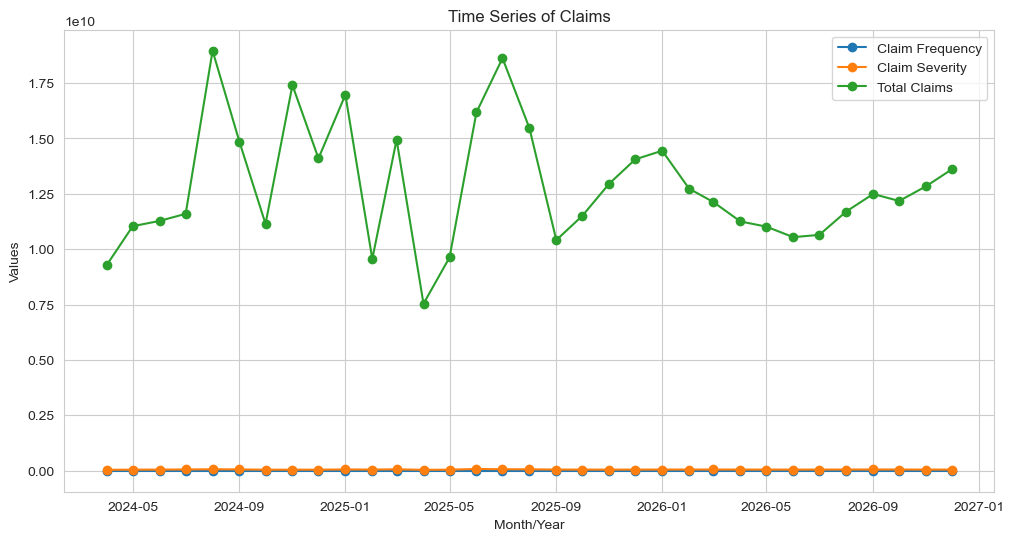

In [137]:
df_hybrid_forecast["month_year"] = [x.to_timestamp() if isinstance(x, pd.Period) else pd.to_datetime(x) for x in df_hybrid_forecast["month_year"]]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_hybrid_forecast["month_year"], df_hybrid_forecast["claim_frequency"], marker='o', label='Claim Frequency')
ax.plot(df_hybrid_forecast["month_year"], df_hybrid_forecast["claim_severity"], marker='o', label='Claim Severity')
ax.plot(df_hybrid_forecast["month_year"], df_hybrid_forecast["total_claim"], marker='o', label='Total Claims')

ax.set_xlabel('Month/Year')
ax.set_ylabel('Values')
ax.set_title('Time Series of Claims')
ax.legend()

plot_forecast_hybrid = fig

##### **C.3.3.3 Recursive vs Hybrid**

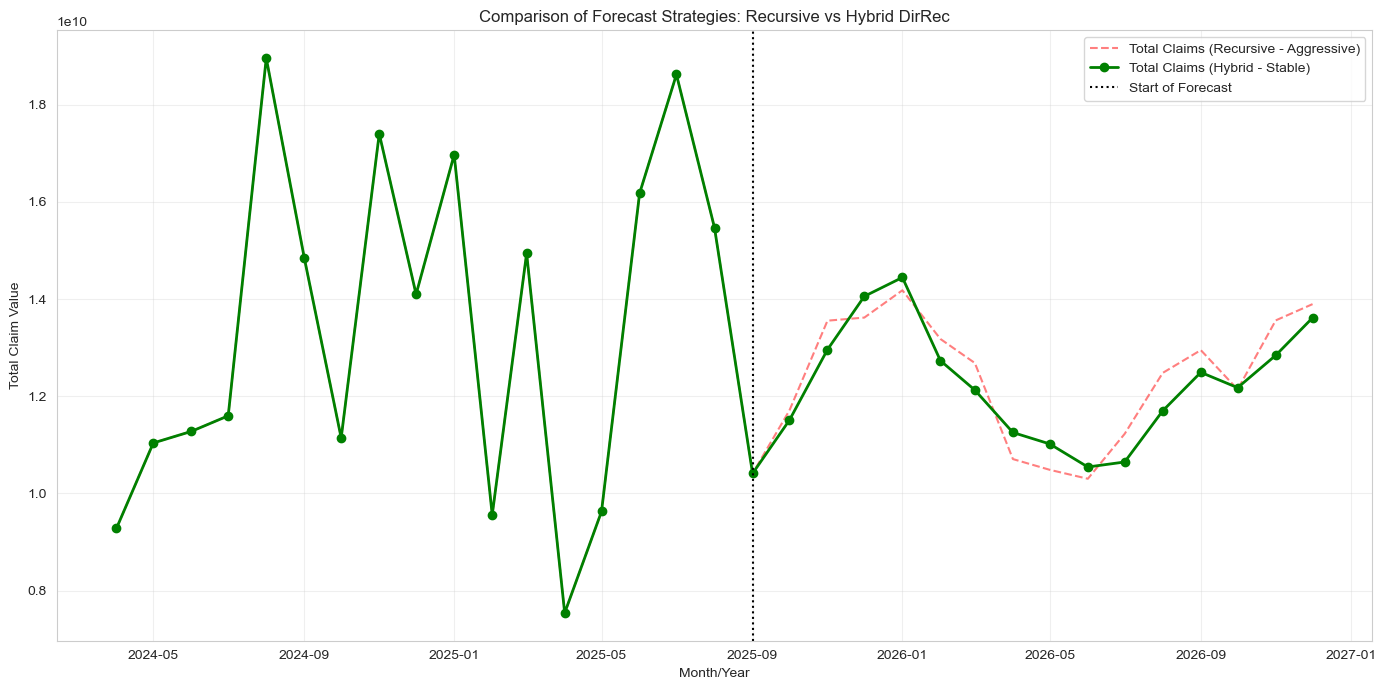

In [138]:
# Format Tanggal
for df in [df_recursive_forecast, df_hybrid_forecast]:
    df["month_year"] = [x.to_timestamp() if isinstance(x, pd.Period) else pd.to_datetime(x) for x in df["month_year"]]

fig, ax = plt.subplots(figsize=(14, 7))

# Recursive
ax.plot(df_recursive_forecast["month_year"], df_recursive_forecast["total_claim"], 
        linestyle='--', color='red', alpha=0.5, label='Total Claims (Recursive - Aggressive)')

# Hybrid - DirRec
ax.plot(df_hybrid_forecast["month_year"], df_hybrid_forecast["total_claim"], 
        linestyle='-', color='green', linewidth=2, marker='o', label='Total Claims (Hybrid - Stable)')


# Pemisah forecast & data original
cutoff_date = df_ts["month_year"].max()
if isinstance(cutoff_date, pd.Period): cutoff_date = cutoff_date.to_timestamp()
ax.axvline(x=cutoff_date, color='black', linestyle=':', label='Start of Forecast')

ax.set_xlabel('Month/Year')
ax.set_ylabel('Total Claim Value')
ax.set_title('Comparison of Forecast Strategies: Recursive vs Hybrid DirRec')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_comparison = fig
plt.show()

##### **C.3.4 Best Model Combination + Forecast Hybrid**

In [139]:
display(summary_cat, summary_rfr, summary_xgb, summary_glm, summary_lgbm)

,CAT_MAPE_Severity_%,CAT_MAPE_Frekuensi_%,CAT_MAPE_Total_Manual_%,CAT_MAPE_Total_Model_%,CAT_SKOR_AKHIR_%
0,12.217877,14.145801,26.867987,20.236966,15.533548


,RFR_MAPE_Severity_%,RFR_MAPE_Frekuensi_%,RFR_MAPE_Total_Manual_%,RFR_MAPE_Total_Model_%,RFR_SKOR_AKHIR_%
0,11.303492,15.575977,23.840813,22.523312,16.906761


,XGB_MAPE_Severity_%,XGB_MAPE_Frekuensi_%,XGB_MAPE_Total_Manual_%,XGB_MAPE_Total_Model_%,XGB_SKOR_AKHIR_%
0,8.707242,16.46492,23.291301,13.631472,12.934545


,GLM_MAPE_Severity_%,GLM_MAPE_Frekuensi_%,GLM_MAPE_Total_Manual_%,GLM_MAPE_Total_Model_%,GLM_SKOR_AKHIR_%
0,2.22269,12.323688,28.023709,2.179098,14.190029


,LGBM_MAPE_Severity_%,LGBM_MAPE_Frekuensi_%,LGBM_MAPE_Total_Manual_%,LGBM_MAPE_Total_Model_%,LGBM_SKOR_AKHIR_%
0,12.410856,18.378147,23.011905,20.400235,17.063079


In [140]:
scenarios = [
    {'freq': best_model_freq_xgb, 'sev': best_model_sev_xgb, 'name': 'XGB-RFR'},
    {'freq': best_model_freq_rfr, 'sev': best_model_sev_rfr, 'name': 'RFR-RFR'},
    {'freq': best_model_freq_rfr, 'sev': best_model_sev_xgb, 'name': 'RFR-XGB'},
    {'freq': best_model_freq_cat, 'sev': best_model_sev_xgb, 'name': 'CAT-XGB'},
    {'freq': best_model_freq_cat, 'sev': best_model_sev_rfr, 'name': 'CAT-RFR'}
]

all_freq = []
all_sev = []
all_total = []
last_res_template = None

for sc in scenarios:
    res = hybrid_forecast(df_ts, sc['freq'], sc['sev'], features_freq, features_sev, 0)

    all_freq.append(res['claim_frequency'].values)
    all_sev.append(res['claim_severity'].values)
    all_total.append(res['total_claim'].values)
    
    last_res_template = res

ensemble_freq = np.mean(all_freq, axis=0)
ensemble_sev = np.mean(all_sev, axis=0)
ensemble_total = np.mean(all_total, axis=0)

df_final = last_res_template.copy()
df_final['total_claim'] = ensemble_total
df_final['claim_frequency'] = ensemble_freq
df_final['claim_severity'] = ensemble_sev

In [141]:
df_final[["month_year", "claim_severity", "claim_frequency", "total_claim"]].describe()

,claim_severity,claim_frequency,total_claim
count,3.300000e+01,33.000000,3.300000e+01
mean,5.406565e+07,237.451693,1.285096e+10
std,7.706056e+06,37.681627,2.719611e+09
min,4.097252e+07,183.000000,7.538943e+09
25%,5.025476e+07,211.003733,1.103847e+10
50%,5.223817e+07,228.671881,1.253026e+10
75%,5.696694e+07,261.847919,1.415261e+10
max,7.930225e+07,365.000000,1.895989e+10


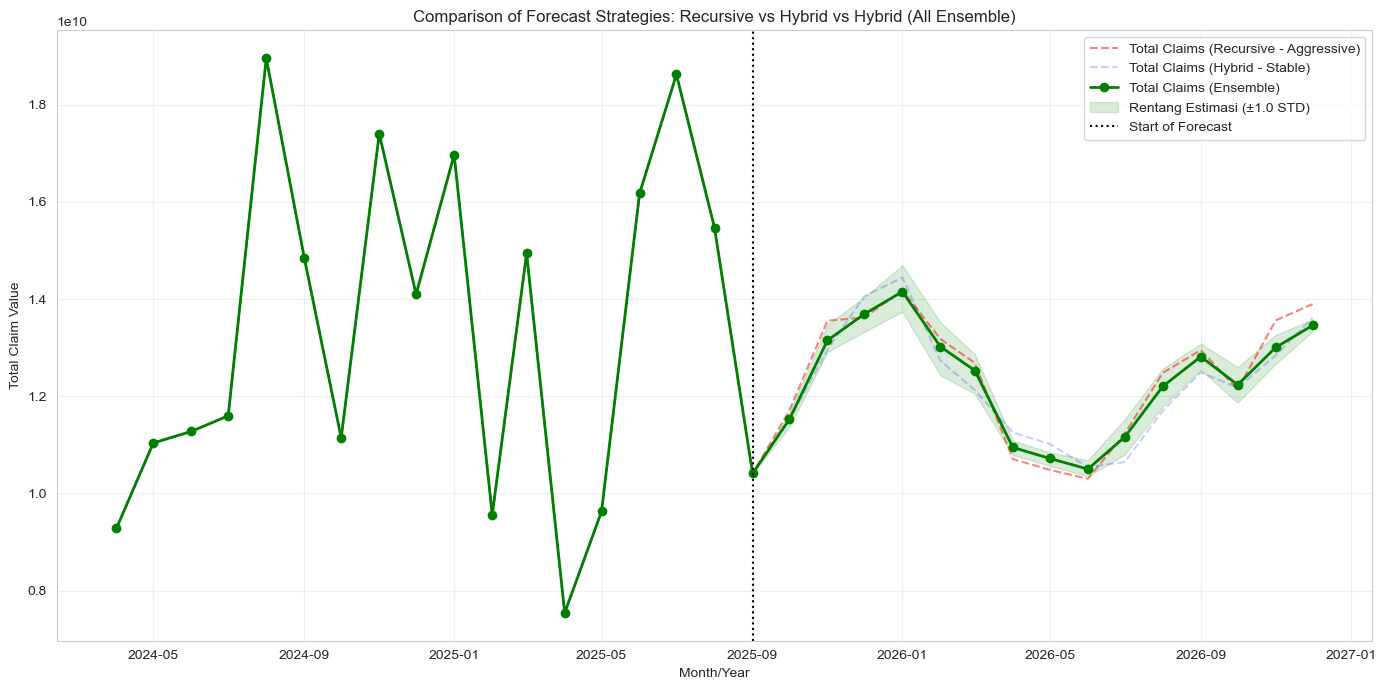

In [142]:
df_actual_part = df_ts[['month_year', 'total_claim']].copy()
df_actual_part['month_year'] = pd.to_datetime(df_actual_part['month_year'].astype(str), errors = "coerce")
df_final['month_year'] = pd.to_datetime(df_final['month_year'].astype(str), format = 'mixed', errors = "coerce")

df_plot_final = df_final.sort_values('month_year').reset_index(drop=True)
histori_len = len(df_actual_part)
df_plot_final.iloc[:histori_len, df_plot_final.columns.get_loc('total_claim')] = df_actual_part['total_claim'].values


# Hitung standar deviasi antar skenario untuk rentang prediksi
# ensemble_std = np.std(all_total, axis=0)
# residuals = df_plot_final["total_claim"][:cutoff_idx] - df_final["total_claim"][:cutoff_idx]
# residual_std = residuals.std()

# horizon = np.arange(1, len(ensemble_total) - cutoff_idx + 1)
# forecast_std = residual_std * np.sqrt(horizon)

lower_bound = np.percentile(all_total, 5, axis=0)
upper_bound = np.percentile(all_total, 95, axis=0)
cutoff_idx = len(df_ts)

#Format Tanggal untuk Plotting
for df in [df_recursive_forecast, df_hybrid_forecast]:
    df["month_year"] = [x.to_timestamp() if isinstance(x, pd.Period) else pd.to_datetime(x) for x in df["month_year"]]

fig, ax = plt.subplots(figsize=(14, 7))

#Plot Recursive
ax.plot(df_recursive_forecast["month_year"], df_recursive_forecast["total_claim"], 
        linestyle='--', color='red', alpha=0.5, label='Total Claims (Recursive - Aggressive)')

#Plot Hybrid DirRec
ax.plot(df_hybrid_forecast["month_year"], df_hybrid_forecast["total_claim"], 
        linestyle='--', color='blue', alpha = 0.2, label='Total Claims (Hybrid - Stable)')

#Plot Ensemble All
ax.plot(df_plot_final["month_year"], df_final["total_claim"], 
        linestyle='-', color='green', linewidth=2, marker='o', label='Total Claims (Ensemble)')

ax.fill_between(df_final["month_year"][cutoff_idx-1:], 
                lower_bound[cutoff_idx-1:], 
                upper_bound[cutoff_idx-1:], 
                color='green', alpha=0.15, label='Rentang Estimasi (±1.0 STD)')


cutoff_date = df_ts["month_year"].max()
if isinstance(cutoff_date, pd.Period): cutoff_date = cutoff_date.to_timestamp()
ax.axvline(x=cutoff_date, color='black', linestyle=':', label='Start of Forecast')

# --- FORMATING ---
ax.set_xlabel('Month/Year')
ax.set_ylabel('Total Claim Value')
ax.set_title('Comparison of Forecast Strategies: Recursive vs Hybrid vs Hybrid (All Ensemble)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_comparison = fig
plt.show()

##### **C.3.3.4 Rekomendasi**

In [143]:
#Prediksi Total Klaim untuk 15 bulan ke depan (Ensemble)
df_plot_final[df_plot_final["month_year"] > '2025-09'][[
    "month_year", "claim_frequency", "claim_severity", "total_claim"]].sort_values("month_year").reset_index(drop=True)

,month_year,claim_frequency,claim_severity,total_claim
0,2025-10-01,226.450739,5.089929e+07,1.152619e+10
1,2025-11-01,261.847919,5.022208e+07,1.315053e+10
2,2025-12-01,271.587517,5.041719e+07,1.369228e+10
3,2026-01-01,262.561003,5.389760e+07,1.415261e+10
4,2026-02-01,232.063105,5.610141e+07,1.302036e+10
5,2026-03-01,218.353917,5.738395e+07,1.253026e+10
6,2026-04-01,211.396250,5.178161e+07,1.094608e+10
7,2026-05-01,211.003733,5.080845e+07,1.072043e+10
8,2026-06-01,208.968432,5.025476e+07,1.050171e+10
9,2026-07-01,208.879741,5.342737e+07,1.115893e+10


Hasil prediksi model ensemble dengan pendekatan hybrid forecasting memiliki galat error yang lebih kecil dibanding hybrid maupun rekursif forecasting. Berdasarkan hasil tersebut, model memprediksi bahwa puncak kenaikan total_klaim dapat terjadi 2x dan dialami pada awal tahun 2026 dan juga oktober 2026. Tidak hanya jumlah **frekuensi** klaim yang diprediksi meningkat, namun juga rata-rata biaya per klaim (**severitas**) juga menunjukan tren kenaikan yang konstan. Hal ini secara akumulatif mendorong **total claim** ke titik puncah baru di akhir 2025 dan awal 2026 yang mungkin dicerminkan langsung oleh inflasi medis, kenaikan biaya perawatan, dan perubahan kebijakan kesehatan oleh lembaga-lembaga secara makro.

Pendekatan hybrid ensemble menghasilkan hasil prediksi yang lebih "santai" terhadap situasi akibat voting weighted dari ke-4 model tersebut. Adapun rekursif bersifat lebih agresif terhadap situasi ketika terjadi perubahan signifikan pada nilai fitur. 

Saran untuk manajemen: Gunakanlah ensemble + hybrid sebagai baseline untuk reserving, tapi pantau rekurisf sebagai early signal jika ada divergensi diantar keduanya, artinya terdapat pola tren baru yang belum muncul di data yang dipelajari oleh model prediksi.

Saran Peneliti:
1. **Gunakan prinsip *overpreparedness***: Perusahaan disarankan untuk lebih berhati-hati dan memiliki rencana backup ketika situasi total_klaim meningkat. Perusahaan disarankan menggunakan batas atas(upper bound) dari hasil prediksi hybrid/ensemble atau menambahkan buffer margin sebesar X% dari prediksi total klaim sebagai alokasi pencadangan dana. 

2. **Jangan gunakan hasil *underestimate***: seperti menggunakan batas bawah dari prediksi hybrid akibat penghematan. Hal ini dapat menaruh perusahaan di ambang bahaya secara finansial. Jagalah likuiditas finansial perusahaan dengan menggunakan prinsip no.1. Mengingat risiko kekurangan dana (under-reserving) dapat mengancam solvabilitas dan kepercayaan nasabah, perusahaan direkomendasikan untuk mengambil pendekatan konservatif atau overprepared.


C:\Users\Alvin\AppData\Local\Temp\ipykernel_24524\3063792026.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_sev.head(15), x='importance', y='feature', palette='magma')


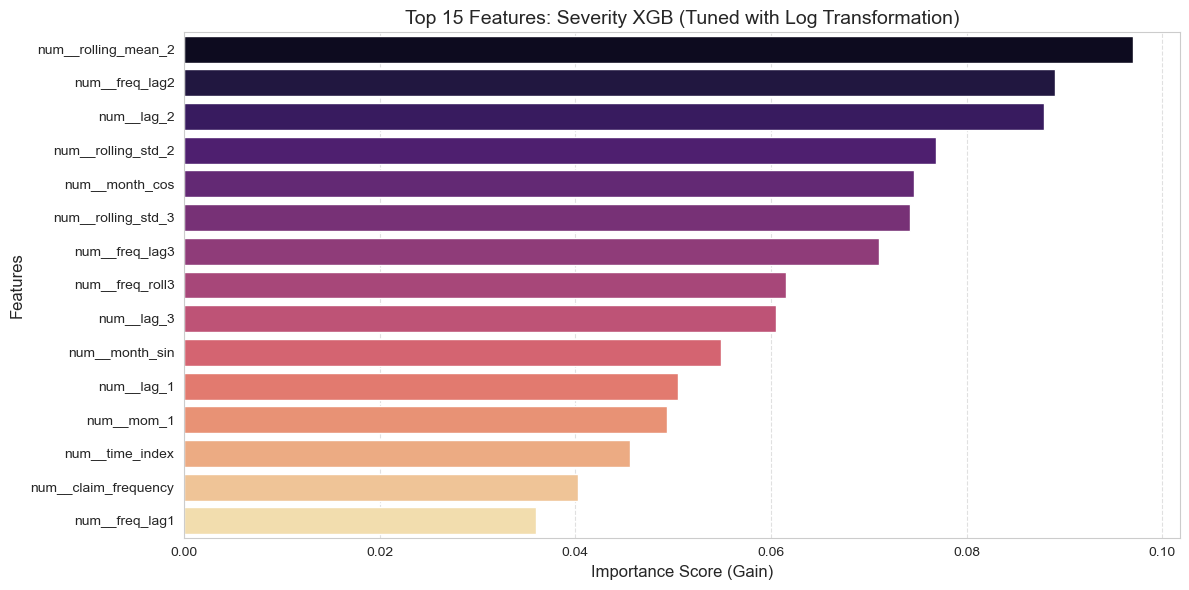

In [144]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_imp_sev.head(15), x='importance', y='feature', palette='magma')

plt.title('Top 15 Features: Severity XGB (Tuned with Log Transformation)', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

3. ***Set-up Early Warning System***: Berdasarkan analisis feature importance, model menemuka pola klaim sangat dipengaruhi oleh tren historis 2 bulan sebelumnya, yang diikuti oleh frekuensi 2 bulan sebelumnya. Perusahaan direkomendasikan untuk menerapkan Early Warning System dengan siklus evaluasi bi-monthly jika terjadi lonjakan 2 bulan berturut-turut, tim pricing dapat langsung menyesuaikan strategi tanpa menunggu evaluasi tahunan.

C:\Users\Alvin\AppData\Local\Temp\ipykernel_24524\2869330331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='magma')


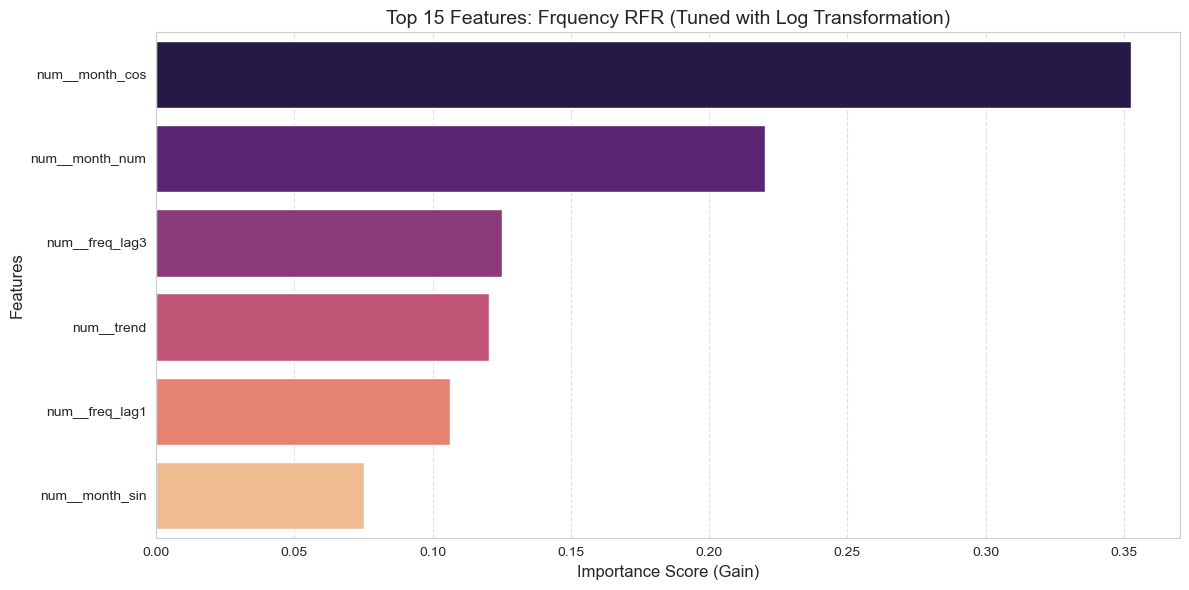

In [145]:

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='magma')

plt.title('Top 15 Features: Frquency RFR (Tuned with Log Transformation)', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**4. Menaikan insentif program wellness**: Karena frekuensi klaim adalah pendorong utama lonjakan nominal klaim, strategi efisiensi biaya tidak bisa hanya bergantung pada pemotong limit klaim (severity). Tren Prediksi Frekuensi klaim cenderung didorong oleh siklus musiman (month_cos, month_num). Perusahaan harus fokus pada tindakan preventif untuk menekan frekuensi musiman.

- Prediksi model juga dipengaruhi oleh efek momentum dari trend 2-3 bulan sebelumnya sehingga menambah rasio pencadangan dana dan juga menerepkan poin sebelumnya dapat menjadi langkah yang bijak.

- Dorong nasabah untuk mengetahui kegiatan pengecekkan preventif atau memberikan insentif premi bagi nasabah yang rutin medical check-up untuk mencegah klaim-klaim kecil yang menumpuk.


**5. Manajemen Likuiditas Berbasis Siklus** (Dynamic Cash Flow Management):

- Grafik hasil prediksi diatas menunjukan bahwa tren kenaikan tidak berjalan lurus, melainkan memiliki siklus lembah & puncak (flukutasi). Tim finance dan investment dapat menggunakan proyeksi ini untuk mengatur likuiditas. Pada periode yang diprediksi akan menjadi lembah (penurunan sementara), dana dapat dialokasikan ke instrumen investasi jangka pendek. Nmaun, likuiditas tingkat (cash/kas) harus disiapkan 1-2bulan sebelum memasuki periode 'puncak' proyeksi klaim (seperti yang terlihat pad grafik menjelang pergantian tahun).

- Namun tak peduli tren menurun atau menaik, baik jangka panjang maupun pendek, perusahaan sangat direkomendasikan untuk tetap memegang sebagian likuiditas sebagai dana cadangan, dan jangan "gamble" terhadap tren hasil prediksi meski menggunakan data yang berasal dari tren tahunan sebelumnya.